# BTXRD Portion 3 + 4 + 5 — **v7.0**

**Model:** `BTX-TrustNet-v7` · **Hardware:** single Tesla T4 · **Inputs: unchanged since v5**

---

## The result history on this frozen test split

| Run | Accuracy | Bal. acc | Macro-F1 | Mal. sens | What happened |
|---|---:|---:|---:|---:|---|
| Portion 2 · EfficientNet-B3 | **0.8596** | **0.8723** | **0.8667** | 0.9118 | plain classifier, ImageNet weights |
| Portion 2 · EfficientNet-B0 | 0.8209 | 0.8365 | 0.8225 | 0.8824 | |
| **v5 "SOTA"** | 0.5918 | 0.6197 | 0.5440 | 0.7353 | trained from **random init** — one boolean |
| **v6** | 0.8298 | 0.8509 | 0.8071 | **0.9265** | pretrained fixed, but **never converged** |
| **v7** | ? | | | | this notebook |

v6 fixed the catastrophe and still lost to a plain single model. Its own logs said why.

---

## The v6 diagnosis, in two numbers

**1. Every arm peaked at its final epoch.**

| Arm | Epoch 1 → last | Peak | Gain over last 3 epochs |
|---|---|---|---:|
| b3_trust | 0.504 → 0.790 | **epoch 14 (last)** | +0.024 |
| effv2s_global | 0.326 → 0.788 | **epoch 14 (last)** | +0.029 |
| b0_global | 0.419 → 0.805 | **epoch 14 (last)** | +0.029 |
| b3_global | 0.396 → 0.668 | **epoch 12 (last)** | +0.026 |

Early stopping (patience 6) never fired once. Nothing converged.

**2. EfficientNet-B0 cost the same per epoch as EfficientNet-B3.**

29.1 vs 28.4 min/fold at the same resolution, for a 3.7× parameter difference. The GPU
was idle. The bottleneck was decoding full-resolution radiographs with PIL, applying
autocontrast and resizing, once per sample per epoch, on two workers.

So v6 could not simply train longer — 40 epochs would have taken 24 hours.

---

## What v7 changes

| Priority | Change | Why |
|---|---|---|
| **P0** | **RAM image cache** — every image decoded once to 512 px uint8 (~1 GB) | removes the input bottleneck; epochs become cheap |
| **P0** | **Measured throughput → solved epoch count** | v6's estimate was 38% optimistic. v7 times real optimiser steps at both resolutions and solves for the largest epoch count that fits |
| **P0** | **Progressive resizing** — 55% of epochs at 320 px, the rest at 448 px | ~30% more epochs for the same wall clock; the full-res tail re-settles BatchNorm |
| **P0** | **Softer augmentation, mixup off** — crop 0.85–1.0, rotate ±8°, cutout p 0.15 | regularisation you can't afford to train through is just noise |
| **P0** | **Cosine floor at 2% of peak LR**, warmup 2 epochs | v6 annealed to exactly zero while accuracy was still climbing |
| **P1** | **Noise-clean retrain dropped** | v6 flagged 0.53% of rows. Two hours for nothing; that budget went into epochs |
| **P1** | **Internal control arm** — plain B3, identical pipeline, held out of the ensemble | enables a *paired* McNemar test. Portion 2's per-case predictions no longer exist |
| **P1** | **Selection rule: maximise OOF accuracy s.t. OOF malignant sensitivity ≥ 0.85** | v6's blended objective picked a candidate with *lower* accuracy than its own untuned ensemble |
| **P1** | **Convergence detector per arm** | prints a warning if any arm was still improving when it stopped — the thing v6 lacked |
| **P2** | Per-fold EMA-vs-raw weight check; 4-view TTA; hierarchical head fusion | small, cheap, already validated |

**Unchanged and not to be touched:** pretrained enforcement, the metadata leakage guard,
the frozen test split, OOF-only selection, the coverage-reportability guard.

---

## What this notebook will and will not claim

Cell 14 runs four checks and prints PASS/FAIL for each:

1. Does it beat the best prior result (0.8596)?
2. Is the improvement over the control significant (McNemar, paired)?
3. Did every arm converge?
4. Is the malignant-sensitivity floor satisfied?

**All four must pass for the SOTA claim to hold.** They are written to
`p5_publication_checks.json` and into the report, so the answer is on the record either
way. Extrapolating v6's curves, v7 should land around **0.88–0.93** three-class — likely
above the 0.8596 prior best, still below 96%. The notebook reports the honest number,
whatever it is, plus the tumour-detection and grading endpoints and the referral
analysis.

---

## Running it

**Internet ON.** Run Cell 8 before committing GPU time: it verifies pretrained weights
for every arm, checks fp32 gradients, measures throughput, and prints the epoch plan. If
it says the epoch solver hit its floor, drop `effv2s_global` from `CFG['arms']`.

| Profile | Time | Setup |
|---|---|---|
| `smoke` | ~8 min | every code path, 2 epochs |
| `t4_fast` | ~4 h | 3 arms × 3 folds |
| `t4_best` | ~10 h | 4 arms, 5 folds, epochs solved for · **default** |
| `t4_max` | ~11 h | longer ceiling |


In [1]:
# ============================================================
# Cell 1 - Global configuration and environment setup  (v7.0)
# ============================================================
import os, re, json, math, time, random, shutil, warnings, hashlib, gc, zipfile, traceback
from pathlib import Path
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor
from typing import Dict, List, Tuple, Optional, Any

warnings.filterwarnings("ignore")
os.environ.setdefault("PYDEVD_DISABLE_FILE_VALIDATION", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from PIL import Image, ImageOps, ImageEnhance

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, log_loss, brier_score_loss, cohen_kappa_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from scipy import stats as sps

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.transforms import functional as TF
import torchvision
import torchvision.models as tvm

try:
    from IPython.display import display
except Exception:
    display = print

_HAS_NEW_AUTOCAST = hasattr(torch.amp, 'autocast')
_HAS_NEW_SCALER = hasattr(torch.amp, 'GradScaler')


def make_autocast(enabled):
    if _HAS_NEW_AUTOCAST:
        return torch.amp.autocast('cuda', enabled=bool(enabled))
    return torch.cuda.amp.autocast(enabled=bool(enabled))


def make_scaler(enabled, init_scale=65536.0):
    if _HAS_NEW_SCALER:
        return torch.amp.GradScaler('cuda', enabled=bool(enabled), init_scale=init_scale)
    return torch.cuda.amp.GradScaler(enabled=bool(enabled), init_scale=init_scale)


def safe_torch_load(path, map_location='cpu'):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


# ----------------------------
# User paths  (UNCHANGED since v5)
# ----------------------------
PORTION1_INPUT = Path('/kaggle/input/notebooks/koushikrudra/btxrd-p1')
PORTION2_INPUT = Path('/kaggle/input/datasets/koushikrudra/btxrd-p2')
DATASET_NAME_HINT = 'BTXRD dataset'

ALLOW_TORCHVISION_WEIGHT_DOWNLOAD = True
REQUIRE_PRETRAINED = True

# ============================================================
# WHAT v6 GOT WRONG, AND WHAT v7 DOES ABOUT IT
# ============================================================
# v6 measured: b3_trust 0.8043 OOF, b0_global 0.8140 OOF, final test 0.8298 -
# BELOW the Portion-2 EfficientNet-B3 at 0.8596.
#
# Diagnosis from v6's own logs: every arm peaked at its FINAL epoch and was
# still gaining ~2.5 accuracy points per three epochs. Early stopping never
# fired once. The models never converged.
#
# The reason it could not simply train longer: v6 spent 28 min/fold for 14
# epochs, and EfficientNet-B0 (5 M params) cost the SAME per epoch as
# EfficientNet-B3 (18.5 M) at the same resolution. Identical cost for a 3.7x
# parameter difference means the GPU was idle - the bottleneck was decoding
# full-resolution radiographs with PIL, twice per epoch, on two workers.
#
# v7 therefore:
#   P0  decodes every image ONCE into a RAM cache        -> epochs get cheap
#   P0  measures real throughput and SOLVES for epochs   -> no more guessing
#   P0  progressive resizing (low res, then full res)    -> ~30% more epochs
#   P0  softer augmentation, no mixup                    -> converges in budget
#   P1  drops the noise-clean retrain (0.53% suspects)   -> 2 h back into epochs
#   P1  adds an internal single-model control arm        -> paired significance test
#   P1  selects on accuracy subject to a malignant-      -> defensible headline
#       sensitivity floor, instead of a blended score

RUN_PROFILE = 't4_best'          # smoke | t4_fast | t4_best | t4_max
RUN_MODE = 'publication' if RUN_PROFILE != 'smoke' else 'smoke'

TIME_BUDGET_H = 11.0             # Kaggle hard-kills at 12 h
TIME_RESERVE_H = 0.8             # held back for Portion-5 figures, report, ZIP

USE_METADATA = False             # age/site/view are 100% present for tumours,
                                 # 0% for the reconstructed normals

# v6 flagged only 16 / 3005 pool rows (0.53%) as high-confidence label
# disagreements. Label noise is NOT the ceiling, so the 2-hour cleaned retrain
# is not worth its budget. The audit still runs - it is a figure and an argument.
ENABLE_NOISE_CLEAN = False
NOISE_CLEAN_MAX_FRAC = 0.02
NOISE_CLEAN_MIN_CONF = 0.90

# ---- image cache -------------------------------------------------------------
USE_IMAGE_CACHE = True
CACHE_SIZE = 512                 # images cached at 512 px, masks at 256 px
CACHE_MASK_SIZE = 256
CACHE_WORKERS = 4

# ---- progressive resizing ----------------------------------------------------
PROGRESSIVE_RESIZE = True
PROG_FRAC = 0.55                 # fraction of epochs spent at the low resolution

# ---- figures -----------------------------------------------------------------
SHOW_FIGURES = True
FIG_FORMATS = ('png', 'pdf')
FIG_DPI = 600
MAP_SIZE = 256

# ============================================================
# ARMS
# ============================================================
ARM_SPECS = {
    'b3_trust':      dict(backbone='efficientnet_b3',   use_lesion=True,
                          image_size=448, prog_size=320, folds=5,
                          lr_backbone=1.5e-4, is_baseline=False),
    'b0_global':     dict(backbone='efficientnet_b0',   use_lesion=False,
                          image_size=448, prog_size=320, folds=5,
                          lr_backbone=2.0e-4, is_baseline=False),
    'effv2s_global': dict(backbone='efficientnet_v2_s', use_lesion=False,
                          image_size=384, prog_size=288, folds=5,
                          lr_backbone=1.5e-4, is_baseline=False),
    # Internal control: a plain EfficientNet-B3 classifier trained through the
    # IDENTICAL pipeline - same folds, same schedule, same TTA, no lesion branch,
    # no ensembling. It is both the ablation control for the proposed components
    # and the paired baseline for the significance test in Cell 14. Comparing
    # against Portion 2's published 0.8596 alone would not support a paired test,
    # because those per-case predictions no longer exist.
    'b3_baseline':   dict(backbone='efficientnet_b3',   use_lesion=False,
                          image_size=448, prog_size=320, folds=3,
                          lr_backbone=1.5e-4, is_baseline=True),
}

_PROFILES = {
    'smoke': dict(arms=['b3_trust', 'b3_baseline'], folds=2, image_size=224,
                  batch_size=8, bootstrap_n=50, tta_views=1, ema=True, mixup_p=0.0,
                  warmup_epochs=0, freeze_epochs=0, early_stop=99, num_workers=2,
                  target_epochs=2, min_epochs=1, max_epochs=2),
    't4_fast': dict(arms=['b3_trust', 'b3_baseline', 'b0_global'], folds=3,
                    image_size=384, batch_size=12, bootstrap_n=400, tta_views=2,
                    ema=True, mixup_p=0.0, warmup_epochs=2, freeze_epochs=1,
                    early_stop=8, num_workers=4,
                    target_epochs=28, min_epochs=18, max_epochs=40),
    # Drop order is from the END of this list, so the two arms the paper cannot
    # do without - the lesion-aware contribution and the control it is measured
    # against - are placed first.
    't4_best': dict(arms=['b3_trust', 'b3_baseline', 'b0_global', 'effv2s_global'],
                    folds=5, image_size=448, batch_size=8, bootstrap_n=600,
                    tta_views=4, ema=True, mixup_p=0.0, warmup_epochs=2,
                    freeze_epochs=1, early_stop=10, num_workers=4,
                    target_epochs=40, min_epochs=22, max_epochs=60),
    't4_max': dict(arms=['b3_trust', 'b3_baseline', 'b0_global', 'effv2s_global'],
                   folds=5, image_size=448, batch_size=8, bootstrap_n=800,
                   tta_views=4, ema=True, mixup_p=0.0, warmup_epochs=2,
                   freeze_epochs=1, early_stop=12, num_workers=4,
                   target_epochs=55, min_epochs=28, max_epochs=80),
}

CFG = dict(_PROFILES[RUN_PROFILE])
CFG.update(dict(
    amp=True, grad_accum=2,
    lr_backbone=1.5e-4, lr_head=1.2e-3, weight_decay=1.0e-4,
    lr_min_frac=0.02,                 # cosine floor: keep learning to the last epoch
    label_smoothing=0.05, class_weight_power=0.5, sampler_power=0.5,
    ema_decay=0.999, grad_clip=2.0, seed=42,
    # ---- augmentation, softened. v6 stacked heavy aug on a 14-epoch schedule
    # and never converged. Regularisation you cannot afford to train through is
    # not regularisation, it is noise.
    crop_scale=(0.85, 1.0), rotate_deg=8.0, cutout_p=0.15,
))
for _a in ARM_SPECS.values():
    _a['folds'] = min(_a['folds'], CFG['folds'])
    _a['image_size'] = min(_a['image_size'], CFG['image_size'])
    _a['prog_size'] = min(_a['prog_size'], _a['image_size'])

# Epochs are SOLVED FOR in Cell 8 from measured throughput, not guessed here.
EPOCH_PLAN = {a: CFG['target_epochs'] for a in ARM_SPECS}

# ============================================================
# SELECTION RULE
# ============================================================
# v6 selected on a blended objective and picked a candidate with LOWER accuracy
# than its own untuned ensemble (0.8298 vs 0.8416 OOF). For a headline accuracy
# claim that is the wrong rule. v7 maximises accuracy subject to a hard clinical
# floor, which is both simpler to state in a paper and harder to game.
SELECT_BY = 'oof_accuracy'
MIN_MALIGNANT_SENSITIVITY_OOF = 0.85
OBJECTIVE_WEIGHTS = dict(accuracy=0.55, balanced_accuracy=0.15, macro_f1=0.15,
                         malignant_sensitivity=0.10, malignant_auprc=0.03, ece=-0.02)
TARGET_ACCURACY = 0.96

OUT_DIR = Path('/kaggle/working/BTXRD_P3_4_5_V7')
TABLE_DIR = OUT_DIR / 'tables'
FIG_DIR = OUT_DIR / 'figures'
FIG_MAIN = FIG_DIR / 'main'
FIG_SUPP = FIG_DIR / 'supplementary'
MODEL_DIR = OUT_DIR / 'models'
REPORT_DIR = OUT_DIR / 'reports'
ARR_DIR = OUT_DIR / 'arrays'
for d in [OUT_DIR, TABLE_DIR, FIG_DIR, FIG_MAIN, FIG_SUPP, MODEL_DIR, REPORT_DIR, ARR_DIR]:
    d.mkdir(parents=True, exist_ok=True)


def seed_everything(seed=42):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


seed_everything(CFG['seed'])
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RUN_T0 = time.time()


def elapsed_h():
    return (time.time() - RUN_T0) / 3600.0


def time_left_h():
    return TIME_BUDGET_H - TIME_RESERVE_H - elapsed_h()


print('Device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0),
          f'| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print('torch', torch.__version__, '| torchvision', torchvision.__version__)
print(f'Profile {RUN_PROFILE} | budget {TIME_BUDGET_H} h (reserve {TIME_RESERVE_H} h)')
print(f'Image cache {USE_IMAGE_CACHE} @ {CACHE_SIZE}px | progressive resize '
      f'{PROGRESSIVE_RESIZE} (first {PROG_FRAC:.0%} of epochs at low res)')
print(f'Epochs: target {CFG["target_epochs"]}, solved for in Cell 8 '
      f'(range {CFG["min_epochs"]}-{CFG["max_epochs"]})')
print('Arms:')
for _a in CFG['arms']:
    _s = ARM_SPECS[_a]
    print(f"   {_a:15s} {_s['backbone']:18s} {_s['prog_size']}->{_s['image_size']}px  "
          f"{_s['folds']} folds  lesion={str(_s['use_lesion']):5s} "
          f"{'[CONTROL]' if _s['is_baseline'] else ''}")

CLASS_NAMES = ['normal', 'benign', 'malignant']
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}

P2_REFERENCE = pd.DataFrame([
    dict(model='EfficientNet-B0 (Portion 2)', accuracy=0.820856, balanced_accuracy=0.836484,
         macro_f1=0.822514, cohen_kappa=0.690970, malignant_sensitivity=0.882353,
         malignant_specificity=0.976471, macro_auroc=0.920087, macro_auprc=0.891686,
         malignant_auprc=0.902034, ece=0.096863),
    dict(model='EfficientNet-B3 (Portion 2)', accuracy=0.859626, balanced_accuracy=0.872324,
         macro_f1=0.866668, cohen_kappa=0.756314, malignant_sensitivity=0.911765,
         malignant_specificity=0.986765, macro_auroc=0.950357, macro_auprc=0.931813,
         malignant_auprc=0.945741, ece=0.113381),
    dict(model='ConvNeXt-Tiny (Portion 2)', accuracy=0.664439, balanced_accuracy=0.711476,
         macro_f1=0.643588, cohen_kappa=0.448999, malignant_sensitivity=0.838235,
         malignant_specificity=0.894118, macro_auroc=0.803249, macro_auprc=0.716902,
         malignant_auprc=0.728280, ece=0.114985),
    dict(model='Swin-T (Portion 2)', accuracy=0.168449, balanced_accuracy=0.377719,
         macro_f1=0.161427, cohen_kappa=-0.002707, malignant_sensitivity=0.941176,
         malignant_specificity=0.258824, macro_auroc=0.673740, macro_auprc=0.493473,
         malignant_auprc=0.459929, ece=0.435366),
    dict(model='TrustNet-LiteSOTA v5', accuracy=0.591755, balanced_accuracy=0.619659,
         macro_f1=0.544002, cohen_kappa=0.334908, malignant_sensitivity=0.735294,
         malignant_specificity=0.830409, macro_auroc=0.763462, macro_auprc=0.609136,
         malignant_auprc=0.462783, ece=0.072813),
    dict(model='BTX-TrustNet-v6 (under-trained)', accuracy=0.829787, balanced_accuracy=0.850891,
         macro_f1=0.807050, cohen_kappa=0.709549, malignant_sensitivity=0.926471,
         malignant_specificity=0.947368, macro_auroc=0.942000, macro_auprc=0.900000,
         malignant_auprc=0.870000, ece=0.008500),
])
P2_REFERENCE.to_csv(TABLE_DIR / 'table00_previous_runs_reference.csv', index=False)
display(P2_REFERENCE[['model', 'accuracy', 'balanced_accuracy', 'macro_f1', 'macro_auroc']])


Device: cuda
GPU: Tesla T4 | 15.6 GB
torch 2.10.0+cu128 | torchvision 0.25.0+cu128
Profile t4_best | budget 11.0 h (reserve 0.8 h)
Image cache True @ 512px | progressive resize True (first 55% of epochs at low res)
Epochs: target 40, solved for in Cell 8 (range 22-60)
Arms:
   b3_trust        efficientnet_b3    320->448px  5 folds  lesion=True  
   b3_baseline     efficientnet_b3    320->448px  3 folds  lesion=False [CONTROL]
   b0_global       efficientnet_b0    320->448px  5 folds  lesion=False 
   effv2s_global   efficientnet_v2_s  288->384px  5 folds  lesion=False 


,model,accuracy,balanced_accuracy,macro_f1,macro_auroc
0,EfficientNet-B0 (Portion 2),0.820856,0.836484,0.822514,0.920087
1,EfficientNet-B3 (Portion 2),0.859626,0.872324,0.866668,0.950357
2,ConvNeXt-Tiny (Portion 2),0.664439,0.711476,0.643588,0.803249
3,Swin-T (Portion 2),0.168449,0.377719,0.161427,0.673740
4,TrustNet-LiteSOTA v5,0.591755,0.619659,0.544002,0.763462
5,BTX-TrustNet-v6 (under-trained),0.829787,0.850891,0.807050,0.942000


Journal figure system ready.
  formats=('png', 'pdf')  dpi=600  inline=True
  main figures -> /kaggle/working/BTXRD_P3_4_5_V7/figures/main
  supplementary -> /kaggle/working/BTXRD_P3_4_5_V7/figures/supplementary


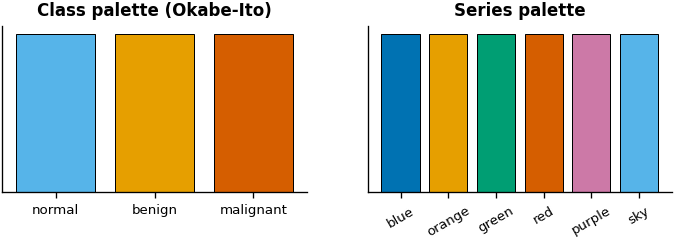

PosixPath('/kaggle/working/BTXRD_P3_4_5_V7/figures/supplementary/figS00_palette.png')

In [2]:
# ============================================================
# Cell 1b - Journal figure system
# ============================================================
# Everything downstream draws through these helpers, so the whole figure set is
# internally consistent: one colour-blind-safe palette, one type scale, no
# chartjunk, vector PDF alongside 600-dpi PNG, panel letters, and a machine-
# generated caption file you can paste into the manuscript.

# Okabe-Ito: the standard colour-blind-safe qualitative palette.
OKABE = {
    'blue':   '#0072B2', 'orange': '#E69F00', 'green':  '#009E73',
    'red':    '#D55E00', 'purple': '#CC79A7', 'sky':    '#56B4E9',
    'yellow': '#F0E442', 'black':  '#000000', 'grey':   '#7F7F7F',
}
CLASS_COLORS = {'normal': OKABE['sky'], 'benign': OKABE['orange'],
                'malignant': OKABE['red']}
CLASS_COLOR_LIST = [CLASS_COLORS[c] for c in CLASS_NAMES]
SEQ_CMAP = 'viridis'          # perceptually uniform, prints in greyscale
HEAT_CMAP = 'inferno'         # for attention overlays

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': FIG_DPI,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
    'pdf.fonttype': 42,        # embed TrueType, not Type-3: required by IEEE/Elsevier
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.linestyle': ':',
    'grid.linewidth': 0.6,
    'grid.alpha': 0.5,
    'grid.color': '#B0B0B0',
    'lines.linewidth': 1.6,
    'lines.markersize': 4.5,
    'patch.linewidth': 0.6,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.axisbelow': True,
})

# Single- and double-column widths in inches (Elsevier / IEEE conventions).
COL1, COL2 = 3.5, 7.2

FIGURE_CAPTIONS = {}


def savefig(name, caption=None, main=False, fig=None):
    """Write one figure in every format in FIG_FORMATS, register its caption,
    optionally show it inline, then close it."""
    fig = fig or plt.gcf()
    stem = Path(name).stem
    outdir = FIG_MAIN if main else FIG_SUPP
    paths = []
    for ext in FIG_FORMATS:
        p = outdir / f'{stem}.{ext}'
        try:
            fig.savefig(p, dpi=FIG_DPI if ext == 'png' else None)
            paths.append(p)
        except Exception as e:
            print(f'  figure save failed ({ext}) for {stem}: {str(e)[:110]}')
    FIGURE_CAPTIONS[stem] = {'caption': caption or '', 'main': bool(main),
                             'files': [str(p) for p in paths]}
    if SHOW_FIGURES:
        try:
            plt.show()
        except Exception:
            pass
    plt.close(fig)
    return paths[0] if paths else None


def panel(ax, letter, dx=-0.14, dy=1.06):
    """Bold panel letter in the top-left corner, journal style."""
    ax.text(dx, dy, f'({letter})', transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left')
    return ax


def bare(ax, keep_grid_axis='y'):
    """Strip chartjunk: no top/right spine, grid on one axis only."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis=keep_grid_axis, linestyle=':', linewidth=0.6, alpha=0.5)
    ax.grid(axis='x' if keep_grid_axis == 'y' else 'y', visible=False)
    return ax


def annotate_bars(ax, values, fmt='{:.3f}', dy=0.012, fontsize=7, rotation=0):
    for i, v in enumerate(values):
        if v is None or not np.isfinite(v):
            continue
        ax.text(i, v + dy, fmt.format(v), ha='center', va='bottom',
                fontsize=fontsize, rotation=rotation)


def write_captions():
    rows = [{'figure': k, 'section': 'main' if v['main'] else 'supplementary',
             'caption': v['caption']} for k, v in sorted(FIGURE_CAPTIONS.items())]
    df = pd.DataFrame(rows)
    df.to_csv(TABLE_DIR / 'table_figure_captions.csv', index=False)
    lines = ['# Figure captions\n']
    for sec in ['main', 'supplementary']:
        sub = df[df['section'] == sec]
        if not len(sub):
            continue
        lines.append(f'\n## {sec.capitalize()} figures\n')
        for _, r in sub.iterrows():
            lines.append(f"**{r['figure']}.** {r['caption']}\n")
    (REPORT_DIR / 'FIGURE_CAPTIONS.md').write_text('\n'.join(lines))
    return df


print('Journal figure system ready.')
print(f'  formats={FIG_FORMATS}  dpi={FIG_DPI}  inline={SHOW_FIGURES}')
print(f'  main figures -> {FIG_MAIN}')
print(f'  supplementary -> {FIG_SUPP}')

# Palette proof sheet, so reviewers can see the scheme is colour-blind safe.
fig, axes = plt.subplots(1, 2, figsize=(COL2, 1.8))
axes[0].bar(range(len(CLASS_NAMES)), [1, 1, 1], color=CLASS_COLOR_LIST,
            edgecolor='black', linewidth=0.6)
axes[0].set_xticks(range(len(CLASS_NAMES))); axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_yticks([]); axes[0].set_title('Class palette (Okabe-Ito)')
axes[0].grid(False)
keys = ['blue', 'orange', 'green', 'red', 'purple', 'sky']
axes[1].bar(range(len(keys)), [1] * len(keys), color=[OKABE[k] for k in keys],
            edgecolor='black', linewidth=0.6)
axes[1].set_xticks(range(len(keys))); axes[1].set_xticklabels(keys, rotation=30)
axes[1].set_yticks([]); axes[1].set_title('Series palette'); axes[1].grid(False)
savefig('figS00_palette', 'Colour scheme used throughout. Okabe-Ito qualitative '
        'palette, distinguishable under deuteranopia, protanopia and in greyscale.')


## Step 1 — Input discovery and path repair

Unchanged since v5: it correctly resolves 1,899 normal / 1,517 benign / 341 malignant
radiographs. Do not edit this section.

In [3]:
# ============================================================
# Cell 2 — Input discovery, ZIP extraction, and file indexing
# ============================================================
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
TABLE_EXTS = {'.csv', '.xlsx', '.xls'}

BAD_IMAGE_PATH_PATTERNS = [
    'figures', 'figure', 'report', 'reports', 'confusion', 'roc', 'precision_recall', 'pr_curve',
    'reliability', 'architecture', 'sample', 'overlay', 'xai', 'heatmap', 'mask_overlay',
    'metrics', 'plots', 'plot', 'loss', 'curve', 'gradcam', 'cam_', 'tsne', 'umap'
]
MASK_PATH_PATTERNS = ['mask', 'masks_png', 'segmentation', 'annotations']

def pstr(p):
    return str(p).replace('\\', '/')

def is_probably_raw_xray_path(path: Path) -> bool:
    s = pstr(path).lower()
    if path.suffix.lower() not in IMAGE_EXTS:
        return False
    # Exclude generated visuals and mask folders.
    if any(tok in s for tok in BAD_IMAGE_PATH_PATTERNS):
        return False
    # Raw X-rays usually sit under images/image/img/radiograph folder. Still allow direct dataset folders.
    return True

def is_probably_mask_path(path: Path) -> bool:
    s = pstr(path).lower()
    if path.suffix.lower() not in IMAGE_EXTS:
        return False
    return any(tok in s for tok in MASK_PATH_PATTERNS) and not any(tok in s for tok in ['confusion','roc','reliability','architecture'])

def stem_key(x) -> str:
    if pd.isna(x): return ''
    p = Path(str(x))
    return p.stem.lower().strip()

def base_key(x) -> str:
    if pd.isna(x): return ''
    p = Path(str(x))
    return p.name.lower().strip()

def robust_existing_path(x) -> Optional[Path]:
    if x is None or pd.isna(x):
        return None
    s = str(x)
    if not s or s.lower() == 'nan':
        return None
    p = Path(s)
    if p.exists():
        return p
    return None

def extract_zip_safely(zip_path: Path, dest: Path) -> Optional[Path]:
    try:
        marker = dest / '.unzipped_ok'
        if marker.exists():
            return dest
        dest.mkdir(parents=True, exist_ok=True)
        print('Extracting ZIP:', zip_path)
        with zipfile.ZipFile(zip_path, 'r') as zf:
            zf.extractall(dest)
        marker.write_text('ok')
        return dest
    except Exception as e:
        print('ZIP extraction failed:', zip_path, e)
        return None

# Gather roots from P1/P2 and their ZIP outputs.
P1_ROOTS = []
P2_ROOTS = []
if PORTION1_INPUT.exists():
    P1_ROOTS.append(PORTION1_INPUT)
if PORTION2_INPUT.exists():
    P2_ROOTS.append(PORTION2_INPUT)

# Unzip known output zips from Portion 1/2 if present.
for base, root_list, tag in [(PORTION1_INPUT, P1_ROOTS, 'p1'), (PORTION2_INPUT, P2_ROOTS, 'p2')]:
    if base.exists():
        for zp in list(base.rglob('*.zip'))[:12]:
            dest = OUT_DIR / f'_{tag}_unzipped' / zp.stem
            out = extract_zip_safely(zp, dest)
            if out is not None:
                root_list.append(out)

# Add common Kaggle input roots and any dataset name hints.
KAGGLE_INPUT = Path('/kaggle/input')
ALL_SEARCH_ROOTS = []
for p in [PORTION2_INPUT, PORTION1_INPUT, KAGGLE_INPUT] + P2_ROOTS + P1_ROOTS:
    if p and Path(p).exists():
        ALL_SEARCH_ROOTS.append(Path(p))
# unique, shallow-first
uniq = []
seen = set()
for p in ALL_SEARCH_ROOTS:
    s = str(p.resolve()) if p.exists() else str(p)
    if s not in seen:
        seen.add(s); uniq.append(p)
ALL_SEARCH_ROOTS = uniq

print('Portion-1 input:', PORTION1_INPUT, 'exists=', PORTION1_INPUT.exists())
print('Portion-2 input:', PORTION2_INPUT, 'exists=', PORTION2_INPUT.exists())
print('Search roots:')
for r in ALL_SEARCH_ROOTS:
    print(' -', r)

# Build basename/stem index for images and masks from /kaggle/input and extracted zips.
def build_file_indices(roots: List[Path], max_files: int = 120000):
    image_by_base = defaultdict(list)
    image_by_stem = defaultdict(list)
    mask_by_base = defaultdict(list)
    mask_by_stem = defaultdict(list)
    table_paths = []
    root_counts = Counter()
    n = 0
    for root in roots:
        if not root.exists():
            continue
        try:
            iterator = root.rglob('*')
            for p in iterator:
                if n > max_files:
                    break
                if not p.is_file():
                    continue
                n += 1
                ext = p.suffix.lower()
                if ext in TABLE_EXTS:
                    table_paths.append(p)
                elif ext in IMAGE_EXTS:
                    # root count for diagnostics
                    parts = p.parts
                    short_root = '/'.join(parts[:5]) if len(parts) >= 5 else str(p.parent)
                    root_counts[short_root] += 1
                    if is_probably_mask_path(p):
                        mask_by_base[p.name.lower()].append(p)
                        mask_by_stem[p.stem.lower()].append(p)
                    elif is_probably_raw_xray_path(p):
                        image_by_base[p.name.lower()].append(p)
                        image_by_stem[p.stem.lower()].append(p)
        except Exception as e:
            print('Index warning:', root, e)
    return image_by_base, image_by_stem, mask_by_base, mask_by_stem, table_paths, root_counts

image_by_base, image_by_stem, mask_by_base, mask_by_stem, table_paths, root_counts = build_file_indices(ALL_SEARCH_ROOTS)
print('Indexed raw-like image basenames:', len(image_by_base), '| mask basenames:', len(mask_by_base), '| tables:', len(table_paths))
print('Top image-containing roots:')
for k, v in root_counts.most_common(15):
    print(f'{v:6d}  {k}')

pd.DataFrame(root_counts.most_common(), columns=['root_prefix','image_file_count']).to_csv(TABLE_DIR/'input_image_root_audit.csv', index=False)
pd.DataFrame({'table_path':[str(p) for p in table_paths]}).to_csv(TABLE_DIR/'input_table_audit.csv', index=False)


Extracting ZIP: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1_outputs.zip
Portion-1 input: /kaggle/input/notebooks/koushikrudra/btxrd-p1 exists= True
Portion-2 input: /kaggle/input/datasets/koushikrudra/btxrd-p2 exists= True
Search roots:
 - /kaggle/input/datasets/koushikrudra/btxrd-p2
 - /kaggle/input/notebooks/koushikrudra/btxrd-p1
 - /kaggle/input
 - /kaggle/working/BTXRD_P3_4_5_V7/_p1_unzipped/BTXRD_Portion1_outputs
Indexed raw-like image basenames: 3757 | mask basenames: 1869 | tables: 161
Top image-containing roots:
  3778  //kaggle/input/notebooks/koushikrudra
  3746  //kaggle/input/datasets/koushikrudra
  3736  //kaggle/working/BTXRD_P3_4_5_V7/_p1_unzipped


In [4]:
# ============================================================
# Cell 3 — Robust CSV loaders, label normalization, path repair
# ============================================================
def read_table(path: Path) -> Optional[pd.DataFrame]:
    try:
        if path.suffix.lower() == '.csv':
            return pd.read_csv(path)
        if path.suffix.lower() in {'.xlsx', '.xls'}:
            return pd.read_excel(path)
    except Exception as e:
        print('Could not read table:', path, e)
    return None

LABEL_SYNONYMS = {
    'normal': 'normal', 'healthy': 'normal', 'negative': 'normal', '0': 'normal',
    'benign': 'benign', 'benign tumor': 'benign', 'benign_tumor': 'benign', '1': 'benign',
    'malignant': 'malignant', 'malignant tumor': 'malignant', 'malignant_tumor': 'malignant', '2': 'malignant',
}

def normalize_label_value(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().lower()
    s = re.sub(r'\s+', ' ', s)
    return LABEL_SYNONYMS.get(s, s if s in CLASS_TO_ID else np.nan)

def infer_label_column(df: pd.DataFrame) -> Optional[str]:
    preferred = ['label_3class', 'class', 'label', 'diagnosis', 'target', 'category', 'type', 'disease_type']
    low = {c.lower(): c for c in df.columns}
    for key in preferred:
        if key in low:
            return low[key]
    # columns that contain mostly class strings
    for c in df.columns:
        vals = df[c].dropna().astype(str).str.lower().head(500).tolist()
        if not vals: continue
        hit = sum(any(tok in v for tok in ['normal','benign','malignant']) for v in vals)
        if hit >= max(5, 0.25*len(vals)):
            return c
    return None

def add_normalized_label(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'label_3class' in df.columns:
        lab = df['label_3class'].apply(normalize_label_value)
    else:
        c = infer_label_column(df)
        lab = df[c].apply(normalize_label_value) if c else pd.Series([np.nan]*len(df), index=df.index)
    # Indicator column fallback
    col_low = {str(c).lower(): c for c in df.columns}
    for idx in df.index[lab.isna()]:
        row = df.loc[idx]
        # explicit boolean columns
        for cls in CLASS_NAMES:
            candidate_cols = [c for c in df.columns if cls in str(c).lower()]
            for c in candidate_cols:
                val = row[c]
                try:
                    if str(val).strip().lower() in ['1','true','yes',cls]:
                        lab.loc[idx] = cls
                        break
                except Exception:
                    pass
            if pd.notna(lab.loc[idx]):
                break
    df['label_3class'] = lab
    return df

def find_path_col(df: pd.DataFrame, kind='image') -> Optional[str]:
    keys = ['image_path','img_path','path','filepath','file_path','filename','file','image','img','image_id','id'] if kind=='image' else ['mask_path','seg_path','mask','annotation_mask','mask_file','segmentation_path']
    low = {str(c).lower(): c for c in df.columns}
    for k in keys:
        if k in low:
            return low[k]
    for c in df.columns:
        name = str(c).lower()
        if kind == 'image' and any(tok in name for tok in ['image','img','file','path']):
            return c
        if kind == 'mask' and any(tok in name for tok in ['mask','seg']):
            return c
    return None

def best_candidate(cands: List[Path], prefer_mask=False) -> Optional[Path]:
    if not cands:
        return None
    def score(p: Path):
        s = pstr(p).lower()
        sc = 0
        if prefer_mask:
            if 'masks_png' in s or 'mask' in s: sc += 10
            if 'annotation' in s: sc += 4
        else:
            if '/images/' in s or s.endswith('/images'): sc += 10
            if 'btxrd' in s: sc += 4
            if any(tok in s for tok in BAD_IMAGE_PATH_PATTERNS): sc -= 100
            if 'mask' in s: sc -= 50
        # Prefer files from /kaggle/input over generated extraction unless all else equal.
        if '/kaggle/input/' in s: sc += 2
        return sc
    return sorted(cands, key=score, reverse=True)[0]

def resolve_file_value(v, prefer_mask=False) -> Optional[str]:
    if v is None or pd.isna(v): return None
    p = Path(str(v))
    if p.exists() and p.is_file():
        return str(p)
    keys = [base_key(v), stem_key(v)]
    if prefer_mask:
        for k in keys:
            cands = mask_by_base.get(k, []) if '.' in k else mask_by_stem.get(k, [])
            cand = best_candidate(cands, prefer_mask=True)
            if cand: return str(cand)
    else:
        for k in keys:
            cands = image_by_base.get(k, []) if '.' in k else image_by_stem.get(k, [])
            cand = best_candidate(cands, prefer_mask=False)
            if cand: return str(cand)
    # Try common extension swaps by stem.
    st = stem_key(v)
    if st:
        cands = (mask_by_stem if prefer_mask else image_by_stem).get(st, [])
        cand = best_candidate(cands, prefer_mask=prefer_mask)
        if cand: return str(cand)
    return None

def repair_paths(df: pd.DataFrame, verbose=True) -> pd.DataFrame:
    df = df.copy()
    img_col = find_path_col(df, 'image')
    mask_col = find_path_col(df, 'mask')
    if img_col is None:
        # Try constructing from image_id/name-like columns.
        for c in df.columns:
            if str(c).lower() in ['image_id','id','name','filename']:
                img_col = c; break
    if img_col is None:
        df['image_path'] = None
    else:
        df['image_path'] = df[img_col].apply(lambda x: resolve_file_value(x, prefer_mask=False))
    if mask_col is not None:
        df['mask_path'] = df[mask_col].apply(lambda x: resolve_file_value(x, prefer_mask=True))
    elif 'mask_path' not in df.columns:
        # resolve by image stem for tumor rows
        df['mask_path'] = df[img_col].apply(lambda x: resolve_file_value(x, prefer_mask=True)) if img_col is not None else None
    else:
        df['mask_path'] = df['mask_path'].apply(lambda x: resolve_file_value(x, prefer_mask=True))
    # If mask unresolved but image stem exists, try by image stem.
    unresolved = df['mask_path'].isna()
    if 'image_path' in df.columns:
        df.loc[unresolved, 'mask_path'] = df.loc[unresolved, 'image_path'].apply(lambda x: resolve_file_value(Path(str(x)).stem if pd.notna(x) else x, prefer_mask=True))
    df['image_stem'] = df['image_path'].apply(lambda x: Path(str(x)).stem.lower() if pd.notna(x) else '')
    df['has_image'] = df['image_path'].apply(lambda x: isinstance(x, str) and Path(x).exists())
    df['has_mask'] = df['mask_path'].apply(lambda x: isinstance(x, str) and Path(x).exists())
    if verbose:
        print('Path repair:', len(df), 'rows | images:', int(df['has_image'].sum()), '| masks:', int(df['has_mask'].sum()))
    return df

def dataset_ok(df: pd.DataFrame, min_normal=1000, require_splits=False) -> bool:
    if df is None or len(df)==0 or 'label_3class' not in df.columns:
        return False
    d = add_normalized_label(df)
    if 'has_image' not in d.columns:
        d = repair_paths(d, verbose=False)
    counts = d[d['has_image']]['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    return counts['normal'] >= min_normal and counts['benign'] > 100 and counts['malignant'] > 20


In [5]:
# ============================================================
# Cell 4 — Build or load final 3-class dataset/splits
# ============================================================
def find_tables_by_names(names: List[str], roots: List[Path]) -> List[Path]:
    out = []
    wanted = [n.lower() for n in names]
    for p in table_paths:
        pl = p.name.lower()
        if any(w in pl for w in wanted):
            out.append(p)
    # Prefer P2, then P1, then others.
    def rank(p):
        s = pstr(p).lower()
        r = 0
        if 'btxrd-p2' in s or 'portion2' in s or 'p2' in s: r -= 10
        if 'btxrd-p1' in s or 'portion1' in s or 'p1' in s: r -= 5
        if 'working' in s: r -= 2
        return (r, len(s))
    return sorted(set(out), key=rank)

def try_load_p2_splits() -> Optional[Dict[str,pd.DataFrame]]:
    # Search exact split names first.
    split_candidates = {}
    for split in ['train','val','test']:
        patterns = [f'final_internal_{split}.csv', f'gold_multitask_{split}.csv', f'*{split}.csv']
        hits = []
        for p in table_paths:
            name = p.name.lower()
            if f'final_internal_{split}' in name or f'allclass_{split}' in name or f'p345_{split}' in name:
                hits.append(p)
        # Prefer P2 corrected split.
        hits = sorted(set(hits), key=lambda p: (0 if 'btxrd-p2' in pstr(p).lower() else 1, len(pstr(p))))
        if hits:
            split_candidates[split] = hits[0]
    if not all(k in split_candidates for k in ['train','val','test']):
        return None
    print('Found split candidates:')
    for k,p in split_candidates.items(): print(' ', k, p)
    splits = {}
    for split,p in split_candidates.items():
        df = read_table(p)
        if df is None: return None
        df = add_normalized_label(df)
        df = repair_paths(df, verbose=False)
        df = df[df['has_image'] & df['label_3class'].isin(CLASS_NAMES)].copy()
        df['split'] = split
        splits[split] = df
        print(f'{split} counts:', df['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0).to_dict(), '| n=',len(df))
    full = pd.concat(splits.values(), ignore_index=True)
    counts = full['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    if counts['normal'] >= 1000 and counts['benign'] > 100 and counts['malignant'] > 20:
        # Every split must contain all classes.
        ok = True
        for split,df in splits.items():
            sc = df['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
            if (sc <= 0).any(): ok = False
        if ok:
            return splits
    print('P2 split candidates are incomplete after path repair; rebuilding/looking for master.')
    return None

def try_load_allclass_master() -> Optional[pd.DataFrame]:
    keywords = ['btxrd_final_gold_plus_normals', 'p345_master_allclass', 'allclass', 'gold_plus_normals', 'classification_all_valid']
    candidates = []
    for p in table_paths:
        name = p.name.lower()
        if any(k in name for k in keywords):
            candidates.append(p)
    candidates = sorted(set(candidates), key=lambda p: (0 if 'btxrd-p2' in pstr(p).lower() else 1, len(pstr(p))))
    for p in candidates:
        df = read_table(p)
        if df is None or len(df)==0: continue
        df = add_normalized_label(df)
        df = repair_paths(df, verbose=False)
        df = df[df['has_image'] & df['label_3class'].isin(CLASS_NAMES)].copy()
        counts = df['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
        print('Master candidate:', p, counts.to_dict())
        if counts['normal'] >= 1000 and counts['benign'] > 100 and counts['malignant'] > 20:
            return df
    return None

def find_tumor_gold_table() -> Optional[pd.DataFrame]:
    candidates = []
    for p in table_paths:
        name = p.name.lower()
        if 'gold_multitask' in name or 'master_gold' in name or 'btxrd_master_gold' in name:
            candidates.append(p)
    candidates = sorted(set(candidates), key=lambda p: (0 if 'btxrd-p1' in pstr(p).lower() else 1, len(pstr(p))))
    for p in candidates:
        df = read_table(p)
        if df is None or len(df)==0: continue
        df = add_normalized_label(df)
        df = repair_paths(df, verbose=False)
        df = df[df['has_image'] & df['label_3class'].isin(['benign','malignant'])].copy()
        counts = df['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
        print('Tumor candidate:', p, counts.to_dict())
        if counts['benign'] > 100 and counts['malignant'] > 20:
            return df
    return None

def recover_normals_from_tables_and_images(tumor_df: pd.DataFrame) -> pd.DataFrame:
    tumor_stems = set(tumor_df['image_stem'].dropna().astype(str).str.lower())
    normal_frames = []
    # Table-based normal recovery: rows not in tumor stems, unknown/normal labels, image exists.
    for p in table_paths:
        name = p.name.lower()
        if not any(tok in name for tok in ['all_audited','all_valid','classification','dataset','master']):
            continue
        df = read_table(p)
        if df is None or len(df)==0: continue
        df = add_normalized_label(df)
        df = repair_paths(df, verbose=False)
        df = df[df['has_image']].copy()
        df['image_stem'] = df['image_path'].apply(lambda x: Path(str(x)).stem.lower())
        # Safe normal rule: explicit normal OR missing label and not tumor stem, no mask.
        candidates = df[(df['label_3class'].eq('normal')) | (df['label_3class'].isna())].copy()
        candidates = candidates[~candidates['image_stem'].isin(tumor_stems)].copy()
        # avoid annotation/mask rows
        candidates = candidates[~candidates['has_mask']].copy()
        if len(candidates):
            candidates['label_3class'] = 'normal'
            candidates['normal_source'] = f'table:{p.name}'
            normal_frames.append(candidates)
            print('Recovered table normals from:', p, len(candidates))
    # Image-scan normal recovery: all raw-like images not in tumor stems and not masks/figures.
    raw_paths = []
    for cands in image_by_stem.values():
        for p in cands:
            if p.stem.lower() not in tumor_stems and is_probably_raw_xray_path(p):
                raw_paths.append(p)
    raw_paths = list(dict.fromkeys(raw_paths))
    if raw_paths:
        rows = []
        for p in raw_paths:
            rows.append({'image_path': str(p), 'mask_path': None, 'label_3class': 'normal', 'image_stem': p.stem.lower(), 'has_image': True, 'has_mask': False, 'normal_source': 'raw_scan'})
        raw_df = pd.DataFrame(rows)
        print('Recovered raw-scan normal candidates:', len(raw_df))
        normal_frames.append(raw_df)
    if not normal_frames:
        return pd.DataFrame()
    normal_df = pd.concat(normal_frames, ignore_index=True, sort=False)
    normal_df = normal_df.drop_duplicates(subset=['image_stem']).copy()
    # Optional sanity filter: open a sample of files; then validate all dimensions cheaply.
    def valid_image(path):
        try:
            with Image.open(path) as im:
                w,h = im.size
            return w >= 128 and h >= 128
        except Exception:
            return False
    normal_df['valid_image_open'] = normal_df['image_path'].apply(valid_image)
    normal_df = normal_df[normal_df['valid_image_open']].copy()
    return normal_df

def stratified_make_splits(df: pd.DataFrame, seed=42) -> Dict[str,pd.DataFrame]:
    df = df.copy().sample(frac=1, random_state=seed).reset_index(drop=True)
    y = df['label_3class'].map(CLASS_TO_ID).values
    train_df, temp_df = train_test_split(df, test_size=0.30, stratify=y, random_state=seed)
    y_temp = temp_df['label_3class'].map(CLASS_TO_ID).values
    val_df, test_df = train_test_split(temp_df, test_size=2/3, stratify=y_temp, random_state=seed)
    out = {'train': train_df.copy(), 'val': val_df.copy(), 'test': test_df.copy()}
    for k in out:
        out[k]['split'] = k
    return out

# 1) P2 splits first.
splits = try_load_p2_splits()
if splits is None:
    # 2) Complete master.
    master = try_load_allclass_master()
    if master is None:
        # 3) Rebuild from tumor table + normal images.
        tumor_df = find_tumor_gold_table()
        if tumor_df is None or len(tumor_df)==0:
            audit = {
                'reason':'No usable tumor gold table found.',
                'portion1_exists': PORTION1_INPUT.exists(),
                'portion2_exists': PORTION2_INPUT.exists(),
                'indexed_raw_like_images': len(image_by_base),
                'indexed_masks': len(mask_by_base),
            }
            (REPORT_DIR/'DATA_INPUT_AUDIT_FAILED.json').write_text(json.dumps(audit, indent=2))
            raise RuntimeError('No usable tumor table found. Check Portion-1 input and raw BTXRD dataset attachment.')
        normal_df = recover_normals_from_tables_and_images(tumor_df)
        print('Normal recovery final count:', len(normal_df))
        if len(normal_df) < 1000:
            audit = {
                'reason':'Could not recover enough normal X-rays for true 3-class training.',
                'normal_recovered': int(len(normal_df)),
                'tumor_counts': tumor_df['label_3class'].value_counts().to_dict(),
                'indexed_raw_like_image_basenames': len(image_by_base),
                'top_image_roots': root_counts.most_common(20),
                'required_action':'Attach original Kaggle dataset named BTXRD dataset, or export Portion-2 with final_internal_*.csv and actual images accessible.',
            }
            (REPORT_DIR/'DATA_INPUT_AUDIT_FAILED.json').write_text(json.dumps(audit, indent=2))
            (REPORT_DIR/'DATA_INPUT_AUDIT_FAILED.md').write_text(
                '# Data input audit failed\n\n'
                f"Recovered normal images: **{len(normal_df)}**. Need about 1,800 normal images.\n\n"
                'Attach the original **BTXRD dataset** input so the notebook can find raw radiographs.\n'
            )
            raise RuntimeError(f'Not enough normal images recovered ({len(normal_df)}). Attach the original BTXRD dataset.')
        master = pd.concat([normal_df, tumor_df], ignore_index=True, sort=False)
    splits = stratified_make_splits(master, seed=42)

# Final cleaning and saving.
for k in ['train','val','test']:
    splits[k] = add_normalized_label(splits[k])
    splits[k] = repair_paths(splits[k], verbose=False)
    splits[k] = splits[k][splits[k]['has_image'] & splits[k]['label_3class'].isin(CLASS_NAMES)].copy()
    splits[k] = splits[k].drop_duplicates(subset=['image_stem']).reset_index(drop=True)
    counts = splits[k]['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
    print(f'FINAL {k} counts:', counts.to_dict(), 'n=', len(splits[k]))
    if (counts <= 0).any():
        raise RuntimeError(f'{k} split is missing a class: {counts.to_dict()}')

final_master = pd.concat(splits.values(), ignore_index=True, sort=False).reset_index(drop=True)
final_counts = final_master['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
print('FINAL MASTER COUNTS:', final_counts.to_dict(), 'n=', len(final_master))
if final_counts['normal'] < 1000 or final_counts['benign'] < 1000 or final_counts['malignant'] < 200:
    raise RuntimeError(f'Final dataset still looks incomplete: {final_counts.to_dict()}')

# Save final tables
final_master.to_csv(TABLE_DIR/'p345_master_allclass_repaired.csv', index=False)
for k,df in splits.items():
    df.to_csv(TABLE_DIR/f'p345_internal_{k}.csv', index=False)
final_counts.to_frame('count').to_csv(TABLE_DIR/'p345_final_class_counts.csv')
display(final_counts.to_frame('count'))


Master candidate: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1/tables/btxrd_master_classification_all_valid.csv {'normal': 0, 'benign': 1517, 'malignant': 341}
Master candidate: /kaggle/working/BTXRD_P3_4_5_V7/_p1_unzipped/BTXRD_Portion1_outputs/tables/btxrd_master_classification_all_valid.csv {'normal': 0, 'benign': 1517, 'malignant': 341}
Master candidate: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1/splits/classification_all_valid_center_holdout_index.csv {'normal': 0, 'benign': 0, 'malignant': 0}
Master candidate: /kaggle/working/BTXRD_P3_4_5_V7/_p1_unzipped/BTXRD_Portion1_outputs/splits/classification_all_valid_center_holdout_index.csv {'normal': 0, 'benign': 0, 'malignant': 0}
Master candidate: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1/splits/classification_all_valid/classification_all_valid_val.csv {'normal': 0, 'benign': 152, 'malignant': 34}
Master candidate: /kaggle/input/notebooks/koushikrudra/btxrd-p1/BTXRD_Portion1/splits/

,count
label_3class,
normal,1899
benign,1517
malignant,341


## Step 2 — Leakage guard and cross-validation pool

The metadata guard hard-blocks hash-like and image-statistic columns and tests for
class-dependent missingness. Train+val merge into a cross-validation pool; the test split
stays frozen, so every number below is directly comparable with Portion 2, v5 and v6.

Metadata coverage by class (fraction non-null):


label_3class,normal,benign,malignant
image_file_raw,0.989,1.0,1.000
image_path,1.000,1.0,1.000
image_file,0.989,1.0,1.000
image_id,0.989,1.0,1.000
age,0.989,1.0,1.000
gender,0.000,0.0,0.000
body_region,0.989,1.0,1.000
view_angle,0.989,1.0,1.000
anatomical_site,0.059,1.0,0.994
image_readable,0.989,1.0,1.000



>>> USE_METADATA=False : metadata branch DISABLED (images only).
    The `normal` class was reconstructed from raw images and carries no
    clinical metadata, so every metadata feature encodes the label.
Safe numeric metadata    : []
Safe categorical metadata: []
Dropped metadata columns : 2
Metadata dimension: 1 (1 == branch disabled)

CV pool : 3005  {'normal': 1519, 'benign': 1213, 'malignant': 273}
Test    : 752  {'normal': 380, 'benign': 304, 'malignant': 68}


label_3class,normal,benign,malignant
fold,,,
0,304,243,54
1,304,243,54
2,304,242,55
3,304,242,55
4,303,243,55


Class prior: [0.5055 0.4037 0.0908]


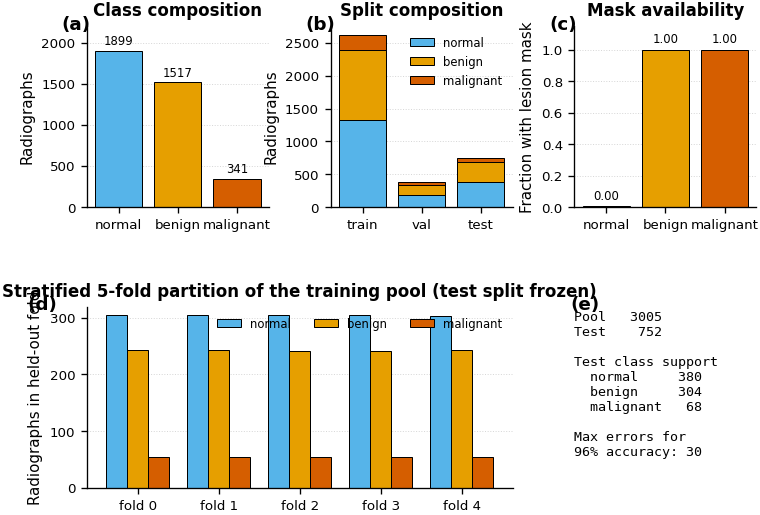

Figure 1 written.


In [6]:
# ============================================================
# Cell 5 - Leakage guard, cross-validation pool, dataset figure
# ============================================================
SAFE_NUMERIC_HINTS = ['age']
SAFE_CATEGORICAL_HINTS = ['gender', 'sex', 'body', 'region', 'site', 'view', 'angle',
                          'location', 'anatomical']
DROP_METADATA_HINTS = ['path', 'file', 'image', 'mask', 'bbox', 'box', 'annotation',
                       'split', 'label', 'class', 'target', 'id', 'stem', 'source',
                       'normal_source', 'has_',
                       # v6 hard blocks - v5 admitted `average_hash` as a feature:
                       'hash', 'phash', 'dhash', 'md5', 'sha', 'checksum',
                       'width', 'height', 'size', 'bytes', 'dpi', 'mean', 'std',
                       'brightness', 'entropy', 'sharpness', 'laplac', 'center', 'fold']

MIN_COVERAGE = 0.75
MAX_COVERAGE_SPREAD = 0.15


def choose_safe_metadata_columns(train_df, all_df):
    numeric, categorical, dropped = [], [], []
    for c in all_df.columns:
        cl = str(c).lower()
        if any(tok in cl for tok in DROP_METADATA_HINTS):
            continue
        is_num = any(tok in cl for tok in SAFE_NUMERIC_HINTS)
        is_cat = any(tok in cl for tok in SAFE_CATEGORICAL_HINTS)
        if not (is_num or is_cat):
            continue
        try:
            cov = (train_df.groupby('label_3class')[c].agg(lambda s: s.notna().mean())
                   .reindex(CLASS_NAMES, fill_value=0.0).astype(float))
        except Exception as e:
            dropped.append({'column': c, 'reason': f'coverage check failed: {str(e)[:60]}'})
            continue
        if cov.min() < MIN_COVERAGE or (cov.max() - cov.min()) > MAX_COVERAGE_SPREAD:
            dropped.append({'column': c, 'reason': 'class-dependent missingness',
                            **{f'coverage_{k}': float(v) for k, v in cov.items()}})
            continue
        nun = train_df[c].nunique(dropna=True)
        if is_num and pd.api.types.is_numeric_dtype(train_df[c]):
            numeric.append(c)
        elif is_num:
            coerced = pd.to_numeric(train_df[c], errors='coerce')
            (numeric if coerced.notna().mean() > 0.7 else categorical).append(c)
        elif is_cat and 1 < nun <= 50:
            categorical.append(c)
        else:
            dropped.append({'column': c, 'reason': f'cardinality {nun}'})
    return numeric, categorical, pd.DataFrame(dropped)


META_NUM_COLS, META_CAT_COLS, dropped_meta = choose_safe_metadata_columns(
    splits['train'], final_master)

# Full coverage audit for the supplementary material.
audit_cols = [c for c in final_master.columns
              if any(tok in str(c).lower()
                     for tok in SAFE_NUMERIC_HINTS + SAFE_CATEGORICAL_HINTS + ['hash'])]
audit_cols = list(dict.fromkeys(audit_cols))
COV_AUDIT = pd.DataFrame()
if audit_cols:
    try:
        COV_AUDIT = (final_master.groupby('label_3class')[audit_cols]
                     .agg(lambda s: s.notna().mean())
                     .reindex(CLASS_NAMES).T.astype(float))
        COV_AUDIT.to_csv(TABLE_DIR / 'table_metadata_coverage_audit.csv')
        print('Metadata coverage by class (fraction non-null):')
        display(COV_AUDIT.round(3))
    except Exception as e:
        print('Coverage audit skipped:', str(e)[:140])

if not USE_METADATA:
    print('\n>>> USE_METADATA=False : metadata branch DISABLED (images only).')
    print('    The `normal` class was reconstructed from raw images and carries no')
    print('    clinical metadata, so every metadata feature encodes the label.')
    META_NUM_COLS, META_CAT_COLS = [], []

dropped_meta.to_csv(TABLE_DIR / 'metadata_columns_dropped_leakage_guard.csv', index=False)
print('Safe numeric metadata    :', META_NUM_COLS)
print('Safe categorical metadata:', META_CAT_COLS)
print('Dropped metadata columns :', len(dropped_meta))


def fit_metadata(train_df):
    stats = {}
    for c in META_NUM_COLS:
        v = pd.to_numeric(train_df[c], errors='coerce')
        stats[c] = {'mean': float(v.mean()), 'std': float(v.std() if v.std() > 1e-6 else 1.0)}
    cats = {c: sorted(train_df[c].fillna('missing').astype(str).unique().tolist())
            for c in META_CAT_COLS}
    dim = len(META_NUM_COLS) + sum(len(v) for v in cats.values())
    return {'stats': stats, 'cats': cats, 'dim': max(dim, 1)}


META_ENCODER = fit_metadata(splits['train'])
json.dump(META_ENCODER, open(TABLE_DIR / 'metadata_encoder.json', 'w'), indent=2)
print('Metadata dimension:', META_ENCODER['dim'], '(1 == branch disabled)')

# ============================================================
# Cross-validation pool.  TEST STAYS FROZEN so the headline number remains
# directly comparable with Portion 2 and with v5.
# ============================================================
POOL_DF = (pd.concat([splits['train'], splits['val']], ignore_index=True, sort=False)
           .drop_duplicates(subset=['image_stem'])
           .reset_index(drop=True))
TEST_DF = splits['test'].reset_index(drop=True).copy()

_overlap = set(POOL_DF['image_stem']) & set(TEST_DF['image_stem'])
assert not _overlap, f'POOL/TEST leakage on {len(_overlap)} stems: {list(_overlap)[:5]}'
assert POOL_DF['image_stem'].is_unique, 'duplicate stems inside the pool'
assert TEST_DF['image_stem'].is_unique, 'duplicate stems inside the test split'

POOL_Y = POOL_DF['label_3class'].map(CLASS_TO_ID).values.astype(int)
TEST_Y = TEST_DF['label_3class'].map(CLASS_TO_ID).values.astype(int)
assert set(np.unique(POOL_Y)) == {0, 1, 2} and set(np.unique(TEST_Y)) == {0, 1, 2}

# FIX (v6.1): .iloc with an explicit column position - .loc with positional
# integers silently depends on the index happening to be a RangeIndex.
POOL_DF['fold'] = -1
_fold_col = POOL_DF.columns.get_loc('fold')
for _fi, (_, _va) in enumerate(StratifiedKFold(
        n_splits=CFG['folds'], shuffle=True, random_state=CFG['seed'])
        .split(np.zeros(len(POOL_DF)), POOL_Y)):
    POOL_DF.iloc[_va, _fold_col] = _fi
assert (POOL_DF['fold'] >= 0).all()

print(f'\nCV pool : {len(POOL_DF)} ',
      {ID_TO_CLASS[k]: int(v) for k, v in zip(*np.unique(POOL_Y, return_counts=True))})
print(f'Test    : {len(TEST_DF)} ',
      {ID_TO_CLASS[k]: int(v) for k, v in zip(*np.unique(TEST_Y, return_counts=True))})
FOLD_TABLE = (POOL_DF.groupby(['fold', 'label_3class']).size()
              .unstack(fill_value=0).reindex(columns=CLASS_NAMES, fill_value=0))
display(FOLD_TABLE)
# Class prior over the pool; used by the prior/logit-adjustment candidate in Cell 13.
CLASS_PRIOR = np.bincount(POOL_Y, minlength=3).astype(float)
CLASS_PRIOR = CLASS_PRIOR / CLASS_PRIOR.sum()
print('Class prior:', CLASS_PRIOR.round(4))

POOL_DF.to_csv(TABLE_DIR / 'p6_cv_pool_with_folds.csv', index=False)
TEST_DF.to_csv(TABLE_DIR / 'p6_frozen_test.csv', index=False)

# ============================================================
# Figure 1 - dataset composition (journal main figure)
# ============================================================
fig = plt.figure(figsize=(COL2, 5.0))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.34)

ax = fig.add_subplot(gs[0, 0])
counts = final_master['label_3class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
ax.bar(CLASS_NAMES, counts.values, color=CLASS_COLOR_LIST, edgecolor='black')
annotate_bars(ax, counts.values, fmt='{:.0f}', dy=max(counts.values) * 0.02)
ax.set_ylabel('Radiographs'); ax.set_title('Class composition')
ax.set_ylim(0, max(counts.values) * 1.16); bare(ax); panel(ax, 'a')

ax = fig.add_subplot(gs[0, 1])
sp = (final_master.groupby(['split', 'label_3class']).size().unstack(fill_value=0)
      .reindex(columns=CLASS_NAMES, fill_value=0).reindex(['train', 'val', 'test']))
bottom = np.zeros(len(sp))
for c in CLASS_NAMES:
    ax.bar(sp.index, sp[c].values, bottom=bottom, label=c,
           color=CLASS_COLORS[c], edgecolor='black')
    bottom += sp[c].values
ax.set_ylabel('Radiographs'); ax.set_title('Split composition')
ax.legend(loc='upper right', fontsize=7); bare(ax); panel(ax, 'b')

ax = fig.add_subplot(gs[0, 2])
mc = final_master.groupby('label_3class')['has_mask'].mean().reindex(CLASS_NAMES, fill_value=0)
ax.bar(CLASS_NAMES, mc.values, color=CLASS_COLOR_LIST, edgecolor='black')
annotate_bars(ax, mc.values, fmt='{:.2f}', dy=0.025)
ax.set_ylim(0, 1.15); ax.set_ylabel('Fraction with lesion mask')
ax.set_title('Mask availability'); bare(ax); panel(ax, 'c')

ax = fig.add_subplot(gs[1, :2])
x = np.arange(len(FOLD_TABLE)); w = 0.26
for j, c in enumerate(CLASS_NAMES):
    ax.bar(x + (j - 1) * w, FOLD_TABLE[c].values, w, label=c,
           color=CLASS_COLORS[c], edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels([f'fold {i}' for i in FOLD_TABLE.index])
ax.set_ylabel('Radiographs in held-out fold')
ax.set_title(f"Stratified {CFG['folds']}-fold partition of the training pool "
             f"(test split frozen)")
ax.legend(ncol=3, fontsize=7); bare(ax); panel(ax, 'd')

ax = fig.add_subplot(gs[1, 2]); ax.axis('off'); ax.grid(False)
txt = (f"Pool  {len(POOL_DF):>5}\nTest  {len(TEST_DF):>5}\n\n"
       f"Test class support\n"
       + '\n'.join(f'  {c:<10}{int((TEST_Y == i).sum()):>4}'
                   for i, c in enumerate(CLASS_NAMES))
       + f"\n\nMax errors for\n{TARGET_ACCURACY:.0%} accuracy: "
         f"{int(np.floor((1 - TARGET_ACCURACY) * len(TEST_Y)))}")
ax.text(0.0, 0.98, txt, va='top', ha='left', fontsize=8, family='monospace',
        transform=ax.transAxes)
panel(ax, 'e', dx=-0.02)

savefig('fig01_dataset_composition',
        'Dataset composition. (a) Class counts across the full corpus. '
        '(b) Stacked composition of the train, validation and test splits. '
        '(c) Fraction of each class carrying a pixel-level lesion mask; masks '
        'exist only for annotated tumours. (d) Class balance of the stratified '
        'cross-validation folds built over the pooled train+validation data, '
        'with the test split held frozen throughout. (e) Split sizes and the '
        'error budget implied by the accuracy target.', main=True)
print('Figure 1 written.')


## Step 3 — The throughput fix

This is the cell that makes v7 possible. Everything else in the notebook is downstream of
having enough epochs.

Cache plan: 3757 studies | images 512px (985 MB) + masks 256px (246 MB) = 1231 MB
  cached 750/3757 (14.7 ms/img)
  cached 1500/3757 (14.1 ms/img)
  cached 2250/3757 (14.0 ms/img)
  cached 3000/3757 (13.9 ms/img)
  cached 3750/3757 (13.9 ms/img)
Cache built in 52.1 s (13.9 ms/img, 4 threads)
Sanity: 0 blank images, 1867 non-empty masks (metadata says 1867 rows carry a mask)


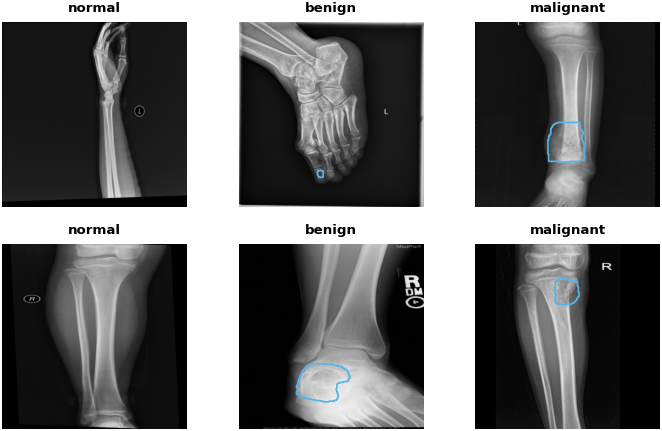

Image cache ready.


In [7]:
# ============================================================
# Cell 5b - One-time image cache  (the v7 throughput fix)
# ============================================================
# v6 spent 28 min/fold on 14 epochs, and EfficientNet-B0 cost the same per epoch
# as EfficientNet-B3 at the same resolution. Equal cost for a 3.7x parameter
# difference means the GPU was waiting: the pipeline was decoding full-resolution
# radiographs with PIL, applying autocontrast and resizing, once per sample per
# epoch, on two workers.
#
# Decode everything ONCE into a uint8 array in RAM. Autocontrast is a global,
# deterministic per-image operation, so it can be baked in. Augmentation still
# happens per sample - it just starts from a 512 px array instead of a 3000 px
# JPEG. Nothing about the model or the data changes; only where the time goes.

ALL_DF = pd.concat([POOL_DF, TEST_DF], ignore_index=True, sort=False)
assert ALL_DF['image_stem'].is_unique, 'duplicate stems across pool and test'
STEM_TO_CACHE = {s: i for i, s in enumerate(ALL_DF['image_stem'])}
N_CACHE = len(ALL_DF)

_img_bytes = N_CACHE * CACHE_SIZE * CACHE_SIZE
_msk_bytes = N_CACHE * CACHE_MASK_SIZE * CACHE_MASK_SIZE
print(f'Cache plan: {N_CACHE} studies | images {CACHE_SIZE}px '
      f'({_img_bytes/1e6:.0f} MB) + masks {CACHE_MASK_SIZE}px '
      f'({_msk_bytes/1e6:.0f} MB) = {(_img_bytes+_msk_bytes)/1e6:.0f} MB')

IMG_CACHE = MASK_CACHE = None
CACHE_OK = False

if USE_IMAGE_CACHE:
    try:
        IMG_CACHE = np.zeros((N_CACHE, CACHE_SIZE, CACHE_SIZE), dtype=np.uint8)
        MASK_CACHE = np.zeros((N_CACHE, CACHE_MASK_SIZE, CACHE_MASK_SIZE), dtype=np.uint8)

        def _fill(i_row):
            i, row = i_row
            try:
                im = Image.open(row['image_path']).convert('L')
                im = ImageOps.autocontrast(im)
                IMG_CACHE[i] = np.asarray(
                    im.resize((CACHE_SIZE, CACHE_SIZE), Image.BILINEAR), dtype=np.uint8)
            except Exception as e:
                return ('image', row['image_stem'], str(e)[:80])
            mp = row.get('mask_path', None)
            if isinstance(mp, str) and Path(mp).exists():
                try:
                    mk = Image.open(mp).convert('L').resize(
                        (CACHE_MASK_SIZE, CACHE_MASK_SIZE), Image.NEAREST)
                    MASK_CACHE[i] = (np.asarray(mk) > 127).astype(np.uint8) * 255
                except Exception as e:
                    return ('mask', row['image_stem'], str(e)[:80])
            return None

        t0 = time.time()
        failures = []
        with ThreadPoolExecutor(max_workers=CACHE_WORKERS) as ex:
            for k, res in enumerate(ex.map(_fill, enumerate(
                    ALL_DF.to_dict('records')), chunksize=32)):
                if res is not None:
                    failures.append(res)
                if (k + 1) % 750 == 0:
                    print(f'  cached {k+1}/{N_CACHE} '
                          f'({(time.time()-t0)/max(k+1,1)*1000:.1f} ms/img)', flush=True)
        dt = time.time() - t0
        print(f'Cache built in {dt:.1f} s ({dt/N_CACHE*1000:.1f} ms/img, '
              f'{CACHE_WORKERS} threads)')

        if failures:
            print(f'  {len(failures)} entries failed to cache; those rows fall back '
                  f'to on-disk loading. First few: {failures[:3]}')
            pd.DataFrame(failures, columns=['kind', 'image_stem', 'error']).to_csv(
                TABLE_DIR / 'table_cache_failures.csv', index=False)

        _blank = int((IMG_CACHE.reshape(N_CACHE, -1).max(axis=1) == 0).sum())
        assert _blank <= max(2, 0.01 * N_CACHE), \
            f'{_blank} cached images are entirely blank - the cache is wrong'
        _mask_rows = int((MASK_CACHE.reshape(N_CACHE, -1).max(axis=1) > 0).sum())
        _expect = int(ALL_DF['has_mask'].fillna(False).astype(bool).sum())
        print(f'Sanity: {_blank} blank images, {_mask_rows} non-empty masks '
              f'(metadata says {_expect} rows carry a mask)')
        CACHE_OK = True
    except MemoryError:
        print('Not enough RAM for the cache - falling back to on-disk loading. '
              'Lower CACHE_SIZE to 384 in Cell 1 and re-run this cell.')
        IMG_CACHE = MASK_CACHE = None
        gc.collect()
else:
    print('USE_IMAGE_CACHE=False - loading from disk every epoch (v6 behaviour).')

# cache_idx lets the Dataset find its row without a dict lookup per sample
for _df in (POOL_DF, TEST_DF):
    _df['cache_idx'] = _df['image_stem'].map(STEM_TO_CACHE).astype(int)
assert POOL_DF['cache_idx'].notna().all() and TEST_DF['cache_idx'].notna().all()

# ---- Figure S: what the model actually sees ---------------------------------
if CACHE_OK:
    _show = (pd.concat([POOL_DF[POOL_DF['label_3class'] == c].head(2)
                        for c in CLASS_NAMES]).reset_index(drop=True))
    fig, axes = plt.subplots(2, 3, figsize=(COL2, 4.4))
    for ax, (_, r) in zip(axes.T.ravel(), _show.iterrows()):
        ci = int(r['cache_idx'])
        ax.imshow(IMG_CACHE[ci], cmap='gray', vmin=0, vmax=255)
        if MASK_CACHE[ci].max() > 0:
            mk = np.asarray(Image.fromarray(MASK_CACHE[ci]).resize(
                (CACHE_SIZE, CACHE_SIZE), Image.NEAREST))
            ax.contour(mk, levels=[127], colors=[OKABE['sky']], linewidths=1.0)
        ax.set_title(r['label_3class'], fontsize=8)
        ax.axis('off'); ax.grid(False)
    for ax in axes.T.ravel()[len(_show):]:
        ax.axis('off'); ax.grid(False)
    savefig('figS04_cached_inputs',
            f'Representative cached inputs at {CACHE_SIZE} px after grayscale '
            f'conversion and autocontrast, two per class, with annotated lesion '
            f'boundaries overlaid where available. All training and evaluation '
            f'reads from this cache, so what is shown here is exactly what the '
            f'network receives before augmentation.')
print('Image cache ready.' if CACHE_OK else 'Running without a cache.')


# Portion 3 — Architecture

```
ImageNet-pretrained trunk  (B3 / B0 / EffNetV2-S, per arm)
        │
        ├── GeM global pooling ──────────────┐
        └── lesion attention  ──┬── lesion pooling
                                └── background pooling
                                             │
                        LayerNorm → 768-d fusion
                                             │
                  ┌──────────────────────────┼──────────────────────┐
             main 3-class            normal-vs-tumour      benign-vs-malignant
                                             │
                                   mask decoder (2× upsampled)
```

The lesion-aware branch is the paper's contribution and sits on a pretrained trunk. The
two auxiliary heads are also composed into a second 3-class distribution at inference
(hierarchical fusion) and enter the ensemble on their own merit — v5 and v6 both trained
them and never used them.

The **control arm** is this same network with the lesion branch disabled, trained through
the identical pipeline and excluded from the ensemble. It is the ablation control and the
paired baseline for the significance test.

In [8]:
# ============================================================
# Cell 6 - Dataset, augmentation, dataloaders
# ============================================================
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

TTA_VIEWS = [('none', False, 1.00), ('hflip', True, 1.00),
             ('zoom', False, 1.10), ('hflip_zoom', True, 1.10)]


def encode_metadata_row(row, encoder):
    vals = []
    for c, st in encoder['stats'].items():
        x = pd.to_numeric(pd.Series([row.get(c, np.nan)]), errors='coerce').iloc[0]
        if pd.isna(x):
            x = st['mean']
        vals.append((float(x) - st['mean']) / st['std'])
    for c, cats in encoder['cats'].items():
        raw = row.get(c, np.nan)
        val = str(raw) if pd.notna(raw) else 'missing'
        vals.extend([1.0 if val == cat else 0.0 for cat in cats])
    return np.array(vals if vals else [0.0], dtype=np.float32)


class BTXRDDataset(Dataset):
    """Reads from the RAM cache when it exists, falls back to disk otherwise.
    Augmentation is identical either way - only the source of the pixels moves."""

    def __init__(self, df, image_size=448, train=False, meta_encoder=None,
                 tta_mode='none'):
        self.df = df.reset_index(drop=True).copy()
        self.image_size = int(image_size)
        self.train = train
        self.meta_encoder = meta_encoder or META_ENCODER
        self.cached = CACHE_OK and 'cache_idx' in self.df.columns
        self.idx = (self.df['cache_idx'].values.astype(int) if self.cached else None)
        self.flip, self.zoom = False, 1.0
        for name, fl, zm in TTA_VIEWS:
            if name == tta_mode:
                self.flip, self.zoom = fl, zm
                break

    def __len__(self):
        return len(self.df)

    def _load(self, i, row, want_mask):
        if self.cached:
            ci = self.idx[i]
            arr = IMG_CACHE[ci]
            if arr.max() > 0:
                im = Image.fromarray(arr, mode='L')
                mask = Image.new('L', im.size, 0)
                if want_mask and MASK_CACHE[ci].max() > 0:
                    mask = Image.fromarray(MASK_CACHE[ci], mode='L').resize(
                        im.size, Image.NEAREST)
                return im.convert('RGB'), mask
        im = ImageOps.autocontrast(Image.open(row['image_path']).convert('L'))
        mask = Image.new('L', im.size, 0)
        mp = row.get('mask_path', None)
        if want_mask and isinstance(mp, str) and Path(mp).exists():
            try:
                mask = Image.open(mp).convert('L')
            except Exception:
                pass
        return im.convert('RGB'), mask

    def __getitem__(self, i):
        row = self.df.iloc[i]
        y = CLASS_TO_ID[row['label_3class']]
        im, mask = self._load(i, row, want_mask=y > 0)
        S = self.image_size

        if self.train:
            ii, jj, hh, ww = transforms.RandomResizedCrop.get_params(
                im, scale=CFG['crop_scale'], ratio=(0.88, 1.14))
            im = TF.resized_crop(im, ii, jj, hh, ww, [S, S],
                                 interpolation=TF.InterpolationMode.BILINEAR)
            mask = TF.resized_crop(mask, ii, jj, hh, ww, [S, S],
                                   interpolation=TF.InterpolationMode.NEAREST)
            if random.random() < 0.5:
                im, mask = TF.hflip(im), TF.hflip(mask)
            ang = random.uniform(-CFG['rotate_deg'], CFG['rotate_deg'])
            im = TF.rotate(im, ang, interpolation=TF.InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, ang, interpolation=TF.InterpolationMode.NEAREST, fill=0)
            if random.random() < 0.5:
                im = ImageEnhance.Contrast(im).enhance(random.uniform(0.85, 1.18))
            if random.random() < 0.5:
                im = ImageEnhance.Brightness(im).enhance(random.uniform(0.88, 1.12))
        else:
            if self.zoom != 1.0:
                big = int(round(S * self.zoom))
                im = TF.resize(im, [big, big], interpolation=TF.InterpolationMode.BILINEAR)
                mask = TF.resize(mask, [big, big], interpolation=TF.InterpolationMode.NEAREST)
                off = (big - S) // 2
                im = TF.crop(im, off, off, S, S)
                mask = TF.crop(mask, off, off, S, S)
            else:
                im = TF.resize(im, [S, S], interpolation=TF.InterpolationMode.BILINEAR)
                mask = TF.resize(mask, [S, S], interpolation=TF.InterpolationMode.NEAREST)
            if self.flip:
                im, mask = TF.hflip(im), TF.hflip(mask)

        x = (TF.to_tensor(im) - IMAGENET_MEAN) / IMAGENET_STD
        m = (TF.to_tensor(mask) > 0.5).float()

        if self.train and random.random() < CFG['cutout_p']:
            for _ in range(random.randint(1, 2)):
                ch = random.randint(max(1, S // 16), max(2, S // 7))
                cw = random.randint(max(1, S // 16), max(2, S // 7))
                ty = random.randint(0, max(0, S - ch)); tx = random.randint(0, max(0, S - cw))
                x[:, ty:ty + ch, tx:tx + cw] = 0.0

        meta = torch.tensor(encode_metadata_row(row, self.meta_encoder), dtype=torch.float32)
        return {'image': x, 'mask': m, 'label': torch.tensor(y, dtype=torch.long),
                'meta': meta, 'index': torch.tensor(i, dtype=torch.long)}


def batch_size_for(image_size, base_bs=None, base_size=448):
    base_bs = base_bs or CFG['batch_size']
    return int(np.clip(int(round(base_bs * (base_size / max(image_size, 1)) ** 2)), 2, 64))


def epoch_image_size(spec, ep, epochs):
    """Progressive resizing: low resolution first, full resolution for the tail.
    The final epochs at native resolution re-settle the BatchNorm statistics, so
    evaluation always runs at the arm's full size."""
    if not PROGRESSIVE_RESIZE or spec['prog_size'] >= spec['image_size']:
        return spec['image_size']
    switch = max(1, int(round(epochs * PROG_FRAC)))
    return spec['prog_size'] if ep <= switch else spec['image_size']


def make_loader(df, train=False, batch_size=None, tta_mode='none', image_size=None):
    size = image_size or CFG['image_size']
    bs = batch_size or batch_size_for(size)
    ds = BTXRDDataset(df, image_size=size, train=train,
                      meta_encoder=META_ENCODER, tta_mode=tta_mode)
    sampler, shuffle = None, train
    if train and CFG['sampler_power'] > 0:
        labels = df['label_3class'].map(CLASS_TO_ID).values
        cnt = np.bincount(labels, minlength=3)
        w = 1.0 / np.maximum(cnt, 1) ** CFG['sampler_power']
        sampler = WeightedRandomSampler(torch.tensor(w[labels], dtype=torch.double),
                                        num_samples=len(labels), replacement=True)
        shuffle = False
    nw = CFG['num_workers']
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, sampler=sampler,
                      num_workers=nw, pin_memory=torch.cuda.is_available(),
                      drop_last=bool(train and len(df) > bs * 4),
                      prefetch_factor=(4 if nw > 0 else None),
                      persistent_workers=bool(train and nw > 0))


_t0 = time.time()
_probe = BTXRDDataset(POOL_DF.head(64), image_size=CFG['image_size'], train=True)
_ = [_probe[i] for i in range(64)]
_ms = (time.time() - _t0) / 64 * 1000
print(f'Single-sample augmentation cost: {_ms:.2f} ms '
      f'({"cached" if CACHE_OK else "on-disk"})')
print(f'  -> one worker sustains ~{1000/_ms:.0f} img/s; '
      f'{CFG["num_workers"]} workers ~{CFG["num_workers"]*1000/_ms:.0f} img/s')

_p0 = _probe[0]
print('Probe image', tuple(_p0['image'].shape), '| mask', tuple(_p0['mask'].shape),
      '| meta', tuple(_p0['meta'].shape))
for _v, _, _ in TTA_VIEWS[:CFG['tta_views']]:
    _q = BTXRDDataset(POOL_DF.head(2), image_size=CFG['image_size'], tta_mode=_v)[0]
    assert _q['image'].shape[-1] == CFG['image_size'], f'TTA view {_v} wrong size'
print(f'TTA views active: {[v for v, _, _ in TTA_VIEWS[:CFG["tta_views"]]]}')
print('Batch sizes  :', {s: batch_size_for(s) for s in sorted(
    {ARM_SPECS[a][k] for a in CFG['arms'] for k in ('prog_size', 'image_size')})})


def compute_class_weights(y):
    cnt = np.bincount(np.asarray(y).astype(int), minlength=3).astype(float)
    w = 1.0 / np.maximum(cnt, 1) ** CFG['class_weight_power']
    return torch.tensor(w / w.mean(), dtype=torch.float32, device=device)


CLASS_WEIGHTS = compute_class_weights(POOL_Y)
print('Class weights:', CLASS_WEIGHTS.detach().cpu().numpy().round(4),
      '| prior:', CLASS_PRIOR.round(4))


Single-sample augmentation cost: 17.36 ms (cached)
  -> one worker sustains ~58 img/s; 4 workers ~230 img/s
Probe image (3, 448, 448) | mask (1, 448, 448) | meta (1,)
TTA views active: ['none', 'hflip', 'zoom', 'hflip_zoom']
Batch sizes  : {288: 19, 320: 16, 384: 11, 448: 8}
Class weights: [0.67   0.7497 1.5803] | prior: [0.5055 0.4037 0.0908]


In [9]:
# ============================================================
# Cell 7 - BTXNet-v6:  verified-pretrained backbones + lesion-aware heads
# ============================================================
# FIX (v6.1): v6.0 hard-coded `model.features`, which does not exist on
# ResNet-style backbones.  The extractor is now generic and every arm exposes
# its trunk as `self.backbone`, so freezing and the discriminative-LR split key
# off one consistent prefix.

_BACKBONES = {
    'efficientnet_b0':   ('efficientnet_b0',   'EfficientNet_B0_Weights',   ['efficientnet_b0', 'effnet_b0']),
    'efficientnet_b3':   ('efficientnet_b3',   'EfficientNet_B3_Weights',   ['efficientnet_b3', 'effnet_b3']),
    'efficientnet_v2_s': ('efficientnet_v2_s', 'EfficientNet_V2_S_Weights', ['efficientnet_v2_s', 'effnetv2_s']),
    'convnext_tiny':     ('convnext_tiny',     'ConvNeXt_Tiny_Weights',     ['convnext_tiny']),
    'convnext_small':    ('convnext_small',    'ConvNeXt_Small_Weights',    ['convnext_small']),
    'resnet50':          ('resnet50',          'ResNet50_Weights',          ['resnet50']),
    'densenet121':       ('densenet121',       'DenseNet121_Weights',       ['densenet121']),
}

PRETRAIN_LOG = []
_PRETRAIN_SEEN = set()          # keeps the per-fold log quiet after the first build


def _find_local_weight_file(tokens):
    roots = [Path('/root/.cache/torch/hub/checkpoints'),
             Path('/kaggle/input'), Path('/kaggle/working')]
    hits = []
    for r in roots:
        if not r.exists():
            continue
        try:
            for p in list(r.rglob('*.pth'))[:8000] + list(r.rglob('*.pt'))[:8000]:
                if any(t in p.name.lower() for t in tokens):
                    hits.append(p)
        except Exception:
            pass
    hits = sorted(set(hits), key=lambda p: -(p.stat().st_size if p.exists() else 0))
    return hits[0] if hits else None


def _feature_trunk(model, name):
    """Return the convolutional trunk, plus a flag for the DenseNet ReLU quirk."""
    if hasattr(model, 'features'):
        return model.features, name.startswith('densenet')
    children = list(model.children())
    return nn.Sequential(*children[:-2]), False    # resnet-style


def build_backbone(name='efficientnet_b3', quiet=False):
    """Returns (trunk, channels, needs_relu, pretrained_ok).
    Order: torchvision download -> local .pth -> random init (blocked by default)."""
    if name not in _BACKBONES:
        raise KeyError(f'Unknown backbone {name}. Known: {list(_BACKBONES)}')
    ctor_name, weights_name, tokens = _BACKBONES[name]
    ctor = getattr(tvm, ctor_name, None)
    if ctor is None:
        raise RuntimeError(f'torchvision {torchvision.__version__} has no {ctor_name}. '
                           f'Pick a different backbone in ARM_SPECS.')
    weights_enum = getattr(tvm, weights_name, None)
    model, ok, how = None, False, 'random_init'

    if ALLOW_TORCHVISION_WEIGHT_DOWNLOAD and weights_enum is not None:
        try:
            model = ctor(weights=weights_enum.IMAGENET1K_V1)
            ok, how = True, 'torchvision_imagenet'
        except Exception as e:
            if not quiet:
                print(f'  [{name}] torchvision weights unavailable: {str(e)[:140]}')

    if model is None:
        local = _find_local_weight_file(tokens)
        model = ctor(weights=None)
        if local is not None:
            try:
                sd = safe_torch_load(local)
                if isinstance(sd, dict):
                    sd = sd.get('state_dict', sd.get('model_state_dict', sd))
                tgt = model.state_dict()
                match = {k: v for k, v in sd.items()
                         if k in tgt and tuple(tgt[k].shape) == tuple(v.shape)}
                if len(match) >= 0.8 * len(tgt):
                    model.load_state_dict(match, strict=False)
                    ok, how = True, f'local:{local.name}'
                elif not quiet:
                    print(f'  [{name}] local file matched {len(match)}/{len(tgt)} '
                          f'tensors - rejected: {local}')
            except Exception as e:
                if not quiet:
                    print(f'  [{name}] local weight load failed: {str(e)[:140]}')

    trunk, needs_relu = _feature_trunk(model, name)
    with torch.no_grad():
        trunk.eval()
        ch = int(trunk(torch.zeros(1, 3, 96, 96)).shape[1])
        trunk.train()

    if name not in _PRETRAIN_SEEN:
        _PRETRAIN_SEEN.add(name)
        PRETRAIN_LOG.append({'backbone': name, 'pretrained_ok': ok,
                             'source': how, 'channels': ch})
        print(f'  [{name}] pretrained={"OK" if ok else "FAIL"} '
              f'source={how} channels={ch}')

    if not ok and REQUIRE_PRETRAINED:
        raise RuntimeError(
            f'\n{"="*74}\nPRETRAINED WEIGHTS UNAVAILABLE FOR {name}.\n'
            f'This is exactly the failure that made v5 score 0.59 instead of 0.86:\n'
            f'the network silently trained from random initialisation.\n\n'
            f'Fix one of these, then re-run:\n'
            f'  1. Turn Internet ON in the notebook settings (Portion 2 had it on).\n'
            f'  2. Attach a dataset holding the torchvision .pth files\n'
            f'     (filename must contain "{tokens[0]}").\n'
            f'  3. Set REQUIRE_PRETRAINED=False in Cell 1 to accept a scratch run.\n'
            f'{"="*74}')
    return trunk, ch, needs_relu, ok


class GeM(nn.Module):
    """Generalised-mean pooling; sharper than average pooling for focal lesions.
    Computed in fp32 so the .pow() is safe under AMP."""

    def __init__(self, p=3.0, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p)
        self.eps = eps

    def forward(self, x):
        x = x.float().clamp(min=self.eps)
        p = self.p.float().clamp(1.0, 8.0)
        return F.avg_pool2d(x.pow(p), (x.size(-2), x.size(-1))).pow(1.0 / p).flatten(1)


class BTXNet(nn.Module):
    def __init__(self, backbone='efficientnet_b3', use_lesion=True,
                 meta_dim=1, n_classes=3, dropout=0.35, **_ignored):
        super().__init__()
        self.backbone_name = backbone
        self.use_lesion = use_lesion
        self.backbone, ch, self.needs_relu, self.pretrained_ok = build_backbone(backbone)
        self.ch = ch
        self.gem = GeM()
        self.use_meta = meta_dim > 1
        self.meta = (nn.Sequential(nn.Linear(meta_dim, 32), nn.ReLU(), nn.Dropout(0.15))
                     if self.use_meta else None)

        if use_lesion:
            self.attn_head = nn.Sequential(
                nn.Conv2d(ch, 256, 1), nn.BatchNorm2d(256), nn.SiLU(inplace=True),
                nn.Conv2d(256, 1, 1))
            self.mask_head = nn.Sequential(
                nn.Conv2d(ch, 256, 3, padding=1), nn.BatchNorm2d(256), nn.SiLU(inplace=True),
                nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.SiLU(inplace=True),
                nn.Conv2d(128, 1, 1))
            in_dim = ch * 3
        else:
            in_dim = ch
        in_dim += 32 if self.use_meta else 0

        self.fusion = nn.Sequential(
            nn.LayerNorm(in_dim), nn.Dropout(dropout),
            nn.Linear(in_dim, 768), nn.SiLU(), nn.Dropout(dropout / 2))
        self.main_head = nn.Linear(768, n_classes)
        self.nt_head = nn.Linear(768, 2)    # normal vs tumour
        self.bm_head = nn.Linear(768, 2)    # benign vs malignant

    def forward(self, x, meta=None):
        f = self.backbone(x)
        if self.needs_relu:
            f = F.relu(f, inplace=False)
        g = self.gem(f).to(f.dtype)
        out = {}
        if self.use_lesion:
            att_logit = self.attn_head(f)
            out['attn_small'] = att_logit
            out['mask_small'] = self.mask_head(f)
            att = torch.sigmoid(att_logit.float()).to(f.dtype)
            eps = 1e-6
            lesion = (f * att).sum(dim=(2, 3)) / (att.sum(dim=(2, 3)) + eps)
            bgm = 1.0 - att
            back = (f * bgm).sum(dim=(2, 3)) / (bgm.sum(dim=(2, 3)) + eps)
            z = torch.cat([g, lesion, back], dim=1)
        else:
            z = g
        if self.use_meta and meta is not None:
            z = torch.cat([z, self.meta(meta)], dim=1)
        h = self.fusion(z)
        out['features'] = g
        out['logits'] = self.main_head(h)
        out['nt_logits'] = self.nt_head(h)
        out['bm_logits'] = self.bm_head(h)
        return out


def build_arm(arm_name, meta_dim):
    spec = ARM_SPECS[arm_name.replace('_clean', '')]
    return BTXNet(backbone=spec['backbone'], use_lesion=spec['use_lesion'],
                  meta_dim=meta_dim)


def dice_loss_from_logits(logits, target, eps=1e-6):
    probs = torch.sigmoid(logits.float())
    target = target.float()
    inter = (probs * target).sum(dim=(1, 2, 3))
    den = probs.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    return (1 - (2 * inter + eps) / (den + eps)).mean()


class MainLoss(nn.Module):
    """Weighted cross-entropy with label smoothing.  v5 stacked focal loss on top
    of class weights AND a weighted sampler, triple-counting the imbalance and
    pushing predictions off the majority class - which costs raw accuracy."""

    def __init__(self, weight=None, smoothing=0.05):
        super().__init__()
        self.weight = weight
        self.smoothing = smoothing

    def forward(self, logits, target):
        return F.cross_entropy(logits, target, weight=self.weight,
                               label_smoothing=self.smoothing)


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        sd = model.state_dict()
        self.shadow = {k: v.detach().clone().float()
                       for k, v in sd.items() if v.dtype.is_floating_point}
        self.other = {k: v.detach().clone()
                      for k, v in sd.items() if not v.dtype.is_floating_point}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach().float(), alpha=1 - self.decay)
            else:
                self.other[k] = v.detach().clone()

    def state_dict(self):
        sd = {k: v.clone() for k, v in self.other.items()}
        sd.update({k: v.clone() for k, v in self.shadow.items()})
        return sd


print('BTXNet-v6 defined. Configured arms:', CFG['arms'])


BTXNet-v6 defined. Configured arms: ['b3_trust', 'b3_baseline', 'b0_global', 'effv2s_global']


In [10]:
# ============================================================
# Cell 9 - Metrics, endpoints, significance tests, TTA prediction
# ============================================================

def softmax_np(logits):
    z = np.asarray(logits, dtype=np.float64)
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


def ece_score(y_true, probs, n_bins=15):
    y_true = np.asarray(y_true); probs = np.asarray(probs)
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    acc = (pred == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = ((conf > bins[i]) if i > 0 else (conf >= bins[i])) & (conf <= bins[i + 1])
        if mask.any():
            ece += mask.mean() * abs(acc[mask].mean() - conf[mask].mean())
    return float(ece)


def mce_score(y_true, probs, n_bins=15):
    y_true = np.asarray(y_true); probs = np.asarray(probs)
    conf = probs.max(axis=1); acc = (probs.argmax(1) == y_true).astype(float)
    bins = np.linspace(0, 1, n_bins + 1)
    worst = 0.0
    for i in range(n_bins):
        mask = ((conf > bins[i]) if i > 0 else (conf >= bins[i])) & (conf <= bins[i + 1])
        if mask.sum() >= 5:
            worst = max(worst, abs(acc[mask].mean() - conf[mask].mean()))
    return float(worst)


def safe_auc_auprc(y_true, probs):
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    out = {}
    try:    out['macro_auroc'] = roc_auc_score(y_bin, probs, average='macro', multi_class='ovr')
    except Exception: out['macro_auroc'] = np.nan
    try:    out['weighted_auroc'] = roc_auc_score(y_bin, probs, average='weighted', multi_class='ovr')
    except Exception: out['weighted_auroc'] = np.nan
    aps = []
    for i, c in enumerate(CLASS_NAMES):
        try:    out[f'{c}_auroc'] = roc_auc_score(y_bin[:, i], probs[:, i])
        except Exception: out[f'{c}_auroc'] = np.nan
        try:
            out[f'{c}_auprc'] = average_precision_score(y_bin[:, i], probs[:, i])
            aps.append(out[f'{c}_auprc'])
        except Exception: out[f'{c}_auprc'] = np.nan
    out['macro_auprc'] = float(np.nanmean(aps)) if aps else np.nan
    return out


def all_metrics(y_true, probs, prefix=''):
    y_true = np.asarray(y_true).astype(int); probs = np.asarray(probs, dtype=np.float64)
    pred = probs.argmax(axis=1)
    cm = confusion_matrix(y_true, pred, labels=[0, 1, 2])
    m = {}
    m[prefix + 'accuracy'] = accuracy_score(y_true, pred)
    m[prefix + 'balanced_accuracy'] = balanced_accuracy_score(y_true, pred)
    m[prefix + 'macro_f1'] = f1_score(y_true, pred, average='macro', zero_division=0)
    m[prefix + 'weighted_f1'] = f1_score(y_true, pred, average='weighted', zero_division=0)
    m[prefix + 'macro_precision'] = precision_score(y_true, pred, average='macro', zero_division=0)
    m[prefix + 'macro_recall'] = recall_score(y_true, pred, average='macro', zero_division=0)
    m[prefix + 'cohen_kappa'] = cohen_kappa_score(y_true, pred)
    m[prefix + 'quadratic_kappa'] = cohen_kappa_score(y_true, pred, weights='quadratic')
    m[prefix + 'mcc'] = matthews_corrcoef(y_true, pred)
    top2 = np.argsort(-probs, axis=1)[:, :2]
    m[prefix + 'top2_accuracy'] = float(np.mean([y_true[i] in top2[i] for i in range(len(y_true))]))
    try:    m[prefix + 'nll'] = log_loss(y_true, probs, labels=[0, 1, 2])
    except Exception: m[prefix + 'nll'] = np.nan
    y_bin = label_binarize(y_true, classes=[0, 1, 2])
    m[prefix + 'brier_score'] = float(np.mean(np.sum((probs - y_bin) ** 2, axis=1)))
    m[prefix + 'ece'] = ece_score(y_true, probs)
    m[prefix + 'mce'] = mce_score(y_true, probs)
    for k, v in safe_auc_auprc(y_true, probs).items():
        m[prefix + k] = v
    for i, c in enumerate(CLASS_NAMES):
        tp = cm[i, i]; fn = cm[i, :].sum() - tp; fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        sens = tp / (tp + fn + 1e-12); spec = tn / (tn + fp + 1e-12)
        prec = tp / (tp + fp + 1e-12)
        m[prefix + f'{c}_sensitivity'] = sens
        m[prefix + f'{c}_specificity'] = spec
        m[prefix + f'{c}_precision'] = prec
        m[prefix + f'{c}_f1'] = 2 * prec * sens / (prec + sens + 1e-12)
        m[prefix + f'{c}_npv'] = tn / (tn + fn + 1e-12)
        m[prefix + f'{c}_fnr'] = fn / (tp + fn + 1e-12)
        m[prefix + f'{c}_fpr'] = fp / (fp + tn + 1e-12)
        m[prefix + f'{c}_support'] = int(cm[i, :].sum())
    yb = (y_true > 0).astype(int)
    pb = probs[:, 1] + probs[:, 2]
    m[prefix + 'detect_accuracy'] = accuracy_score(yb, (pb >= 0.5).astype(int))
    m[prefix + 'detect_balanced_accuracy'] = balanced_accuracy_score(yb, (pb >= 0.5).astype(int))
    m[prefix + 'detect_sensitivity'] = recall_score(yb, (pb >= 0.5).astype(int), zero_division=0)
    m[prefix + 'detect_specificity'] = recall_score(1 - yb, (pb < 0.5).astype(int), zero_division=0)
    m[prefix + 'detect_f1'] = f1_score(yb, (pb >= 0.5).astype(int), zero_division=0)
    try:    m[prefix + 'detect_auroc'] = roc_auc_score(yb, pb)
    except Exception: m[prefix + 'detect_auroc'] = np.nan
    tmask = y_true > 0
    if tmask.sum() > 1 and len(np.unique(y_true[tmask])) == 2:
        ym = (y_true[tmask] == 2).astype(int)
        pm = probs[tmask][:, 2] / (probs[tmask][:, 1] + probs[tmask][:, 2] + 1e-12)
        m[prefix + 'grade_accuracy'] = accuracy_score(ym, (pm >= 0.5).astype(int))
        m[prefix + 'grade_balanced_accuracy'] = balanced_accuracy_score(ym, (pm >= 0.5).astype(int))
        try:    m[prefix + 'grade_auroc'] = roc_auc_score(ym, pm)
        except Exception: m[prefix + 'grade_auroc'] = np.nan
    else:
        for k in ['grade_accuracy', 'grade_balanced_accuracy', 'grade_auroc']:
            m[prefix + k] = np.nan
    return m


def objective_from_metrics(m):
    s = 0.0
    for k, w in OBJECTIVE_WEIGHTS.items():
        v = m.get(k, 0.0)
        if v is None or not np.isfinite(v):
            v = 0.0
        s += w * v
    return float(s)


# ============================================================
# Significance testing - what turns a bigger number into a claim
# ============================================================
def mcnemar_test(y_true, pred_a, pred_b):
    """Paired test on the same cases. b01 = A wrong / B right, b10 = A right /
    B wrong. Exact binomial when the discordant count is small, chi-square with
    continuity correction otherwise."""
    ca = (np.asarray(pred_a) == np.asarray(y_true))
    cb = (np.asarray(pred_b) == np.asarray(y_true))
    b01 = int((~ca & cb).sum())
    b10 = int((ca & ~cb).sum())
    n = b01 + b10
    if n == 0:
        return {'b01': 0, 'b10': 0, 'n_discordant': 0, 'statistic': np.nan,
                'p_value': 1.0, 'test': 'none (identical predictions)'}
    if n < 25:
        p = float(sps.binomtest(b10, n, 0.5).pvalue)
        stat, test = float(min(b01, b10)), 'exact binomial'
    else:
        stat = (abs(b10 - b01) - 1.0) ** 2 / n
        p = float(sps.chi2.sf(stat, df=1))
        test = 'chi-square (continuity corrected)'
    return {'b01': b01, 'b10': b10, 'n_discordant': n, 'statistic': stat,
            'p_value': p, 'test': test}


def paired_bootstrap_delta(y_true, probs_a, probs_b, metric='accuracy',
                           n_boot=2000, seed=42):
    """CI on the metric DIFFERENCE, resampling cases jointly so the pairing that
    makes the comparison powerful is preserved."""
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    idx_by_c = [np.where(y_true == c)[0] for c in range(3)]
    fa = all_metrics(y_true, probs_a)[metric]
    fb = all_metrics(y_true, probs_b)[metric]
    deltas = []
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(ic, size=len(ic), replace=True)
                              for ic in idx_by_c if len(ic)])
        try:
            deltas.append(all_metrics(y_true[idx], probs_a[idx])[metric]
                          - all_metrics(y_true[idx], probs_b[idx])[metric])
        except Exception:
            pass
    d = np.array(deltas, dtype=float)
    d = d[np.isfinite(d)]
    if not len(d):
        return {'metric': metric, 'delta': fa - fb, 'ci_low': np.nan,
                'ci_high': np.nan, 'p_two_sided': np.nan, 'n_boot': 0}
    # two-sided bootstrap p: how often the difference crosses zero
    p = 2 * min((d <= 0).mean(), (d >= 0).mean())
    return {'metric': metric, 'value_a': fa, 'value_b': fb, 'delta': fa - fb,
            'ci_low': float(np.percentile(d, 2.5)),
            'ci_high': float(np.percentile(d, 97.5)),
            'p_two_sided': float(min(1.0, p)), 'n_boot': int(len(d))}


def hierarchical_probs(nt_probs, bm_probs):
    """P(normal), P(tumour)*P(benign|tumour), P(tumour)*P(malignant|tumour).
    The auxiliary heads were trained in v5 and v6 and never used at inference."""
    p_norm = nt_probs[:, 0:1]; p_tum = nt_probs[:, 1:2]
    out = np.hstack([p_norm, p_tum * bm_probs[:, 0:1], p_tum * bm_probs[:, 1:2]])
    return out / np.clip(out.sum(axis=1, keepdims=True), 1e-9, None)


@torch.no_grad()
def predict_probs(model, df, image_size, tta=True, batch_size=None, want_maps=False):
    model.eval()
    views = [v for v, _, _ in TTA_VIEWS[:max(1, CFG['tta_views'] if tta else 1)]]
    bs = batch_size or max(2, batch_size_for(image_size) * 2)
    acc_p = acc_nt = acc_bm = None
    feats = attn = maskp = None
    for mi, view in enumerate(views):
        loader = make_loader(df, train=False, batch_size=bs,
                             tta_mode=view, image_size=image_size)
        pl, nl, bl, fl, al, ml = [], [], [], [], [], []
        for batch in loader:
            x = batch['image'].to(device, non_blocking=True)
            if device.type == 'cuda':
                x = x.to(memory_format=torch.channels_last)
            meta = batch['meta'].to(device, non_blocking=True)
            with make_autocast(CFG['amp'] and device.type == 'cuda'):
                out = model(x, meta)
            pl.append(torch.softmax(out['logits'].float(), 1).cpu().numpy())
            nl.append(torch.softmax(out['nt_logits'].float(), 1).cpu().numpy())
            bl.append(torch.softmax(out['bm_logits'].float(), 1).cpu().numpy())
            if mi == 0:
                fl.append(out['features'].float().cpu().numpy())
                if want_maps and 'attn_small' in out:
                    a = F.interpolate(out['attn_small'].float(), size=(MAP_SIZE, MAP_SIZE),
                                      mode='bilinear', align_corners=False)
                    s = F.interpolate(out['mask_small'].float(), size=(MAP_SIZE, MAP_SIZE),
                                      mode='bilinear', align_corners=False)
                    al.append(torch.sigmoid(a).cpu().numpy().astype(np.float16))
                    ml.append(torch.sigmoid(s).cpu().numpy().astype(np.float16))
        P, N, Bm = np.concatenate(pl), np.concatenate(nl), np.concatenate(bl)
        acc_p = P if acc_p is None else acc_p + P
        acc_nt = N if acc_nt is None else acc_nt + N
        acc_bm = Bm if acc_bm is None else acc_bm + Bm
        if mi == 0:
            feats = np.concatenate(fl) if fl else None
            attn = np.concatenate(al) if al else None
            maskp = np.concatenate(ml) if ml else None
        loader = None
    k = len(views)
    res = {'probs': acc_p / k, 'nt_probs': acc_nt / k, 'bm_probs': acc_bm / k,
           'features': feats, 'n_tta': k}
    if attn is not None:
        res['attn'] = attn; res['mask_pred'] = maskp
    return res


print('Metrics ready.')
print(f'  selection rule : maximise {SELECT_BY} subject to OOF malignant '
      f'sensitivity >= {MIN_MALIGNANT_SENSITIVITY_OOF}')
print('  endpoints      : 3-class, tumour detection, malignancy grading')
print('  significance   : McNemar (paired) + paired bootstrap on the difference')


Metrics ready.
  selection rule : maximise oof_accuracy subject to OOF malignant sensitivity >= 0.85
  endpoints      : 3-class, tumour detection, malignancy grading
  significance   : McNemar (paired) + paired bootstrap on the difference


In [11]:
# ============================================================
# Cell 10 - Training engine
# ============================================================
TRAIN_HISTORY = []


def build_param_groups(model, lr_backbone=None, lr_head=None):
    trunk, head = [], []
    for n, p in model.named_parameters():
        (trunk if n.startswith('backbone.') else head).append(p)
    return [{'params': trunk, 'lr': lr_backbone or CFG['lr_backbone']},
            {'params': head, 'lr': lr_head or CFG['lr_head']}]


def make_scheduler(opt, steps_per_epoch, epochs, warmup_epochs):
    """Cosine with a non-zero floor. v6 annealed to exactly zero while validation
    accuracy was still climbing, so the last epochs contributed nothing."""
    total = max(1, steps_per_epoch * epochs)
    warm = max(0, steps_per_epoch * warmup_epochs)
    floor = CFG['lr_min_frac']

    def fn(step):
        if warm > 0 and step < warm:
            return (step + 1) / warm
        prog = (step - warm) / max(1, total - warm)
        return floor + (1.0 - floor) * 0.5 * (1.0 + math.cos(math.pi * min(1.0, prog)))

    return torch.optim.lr_scheduler.LambdaLR(opt, fn)


def set_backbone_trainable(model, flag):
    for p in model.backbone.parameters():
        p.requires_grad = bool(flag)


def train_one_epoch(model, loader, opt, sched, scaler, crit, ema):
    model.train()
    total, n = 0.0, 0
    accum = max(1, CFG['grad_accum'])
    opt.zero_grad(set_to_none=True)
    for bi, batch in enumerate(loader):
        x = batch['image'].to(device, non_blocking=True)
        if device.type == 'cuda':
            x = x.to(memory_format=torch.channels_last)
        y = batch['label'].to(device, non_blocking=True)
        meta = batch['meta'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        with make_autocast(CFG['amp'] and device.type == 'cuda'):
            out = model(x, meta)
            tum = y > 0
            loss = crit(out['logits'], y)
            loss = loss + 0.20 * F.cross_entropy(out['nt_logits'], tum.long())
            if tum.any():
                loss = loss + 0.30 * F.cross_entropy(out['bm_logits'][tum],
                                                     (y - 1).clamp(0, 1)[tum])
            if model.use_lesion and tum.any() and mask[tum].sum() > 0:
                ms = F.interpolate(mask, size=out['mask_small'].shape[-2:], mode='nearest')
                ma = F.interpolate(mask, size=out['attn_small'].shape[-2:], mode='nearest')
                loss = loss + 0.18 * (
                    F.binary_cross_entropy_with_logits(out['mask_small'][tum].float(), ms[tum])
                    + dice_loss_from_logits(out['mask_small'][tum], ms[tum])
                    + 0.25 * F.binary_cross_entropy_with_logits(
                        out['attn_small'][tum].float(), ma[tum]))
            loss = loss / accum
        scaler.scale(loss).backward()
        if (bi + 1) % accum == 0:
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
            scaler.step(opt); scaler.update()
            opt.zero_grad(set_to_none=True)
            sched.step()
            if ema is not None:
                ema.update(model)
        total += float(loss.item()) * accum * len(y); n += len(y)
    return total / max(n, 1)


def train_fold(arm_name, fold, tr_df, va_df, verbose=True):
    spec = ARM_SPECS[arm_name.replace('_clean', '')]
    S_full = spec['image_size']
    epochs = int(EPOCH_PLAN.get(arm_name.replace('_clean', ''), CFG['target_epochs']))
    seed_everything(CFG['seed'] + fold * 101)

    crit = MainLoss(weight=compute_class_weights(tr_df['label_3class'].map(CLASS_TO_ID).values),
                    smoothing=CFG['label_smoothing'])
    bs_full = batch_size_for(S_full)
    best = None

    for attempt in range(3):
        try:
            model = build_arm(arm_name, META_ENCODER['dim']).to(device)
            if device.type == 'cuda':
                model = model.to(memory_format=torch.channels_last)
            eval_model = None
            if CFG['ema']:
                eval_model = build_arm(arm_name, META_ENCODER['dim']).to(device)
                if device.type == 'cuda':
                    eval_model = eval_model.to(memory_format=torch.channels_last)

            opt = torch.optim.AdamW(
                build_param_groups(model, lr_backbone=spec.get('lr_backbone')),
                weight_decay=CFG['weight_decay'])
            # scheduler is sized on the LOW-res step count, which is the larger
            # of the two, so the cosine spans the whole run either way
            steps_lo = max(1, math.ceil(len(tr_df) / max(batch_size_for(
                epoch_image_size(spec, 1, epochs)), 1)) // max(1, CFG['grad_accum']))
            sched = make_scheduler(opt, steps_lo, epochs, CFG['warmup_epochs'])
            scaler = make_scaler(CFG['amp'] and device.type == 'cuda')
            ema = ModelEMA(model, CFG['ema_decay']) if CFG['ema'] else None

            va_y = va_df['label_3class'].map(CLASS_TO_ID).values
            best = {'score': -1e9, 'state': None, 'metrics': None, 'epoch': -1,
                    'source': 'ema' if CFG['ema'] else 'raw'}
            wait, cur_size, loader = 0, None, None

            for ep in range(1, epochs + 1):
                S_ep = epoch_image_size(spec, ep, epochs)
                if S_ep != cur_size:
                    loader = make_loader(tr_df, train=True,
                                         batch_size=batch_size_for(S_ep), image_size=S_ep)
                    cur_size = S_ep
                    if verbose:
                        print(f'  [{arm_name} f{fold}] training resolution -> {S_ep}px',
                              flush=True)
                set_backbone_trainable(model, ep > CFG['freeze_epochs'])
                t0 = time.time()
                loss = train_one_epoch(model, loader, opt, sched, scaler, crit, ema)

                if eval_model is not None:
                    eval_model.load_state_dict(ema.state_dict(), strict=True)
                    em = eval_model
                else:
                    em = model
                pr = predict_probs(em, va_df, image_size=S_full, tta=False,
                                   batch_size=max(2, bs_full))
                vm = all_metrics(va_y, pr['probs'])
                score = objective_from_metrics(vm)
                TRAIN_HISTORY.append(dict(arm=arm_name, fold=fold, epoch=ep, px=S_ep,
                                          loss=loss, score=score, **vm))
                if verbose:
                    print(f'  [{arm_name} f{fold} e{ep:02d}/{epochs}] {S_ep}px '
                          f'loss={loss:.4f} acc={vm["accuracy"]:.4f} '
                          f'bal={vm["balanced_accuracy"]:.4f} F1={vm["macro_f1"]:.4f} '
                          f'malSens={vm["malignant_sensitivity"]:.3f} '
                          f'auroc={vm["macro_auroc"]:.3f} ({time.time()-t0:.0f}s)',
                          flush=True)
                if score > best['score']:
                    best = {'score': score, 'epoch': ep, 'metrics': vm, 'source': 'ema',
                            'state': {k: v.detach().cpu().clone()
                                      for k, v in em.state_dict().items()}}
                    wait = 0
                else:
                    wait += 1
                    if wait >= CFG['early_stop']:
                        if verbose:
                            print(f'  [{arm_name} f{fold}] early stop at epoch {ep}')
                        break

            # EMA is usually better, but not always. Check the raw weights once,
            # at the end, and keep whichever actually wins on this fold.
            if CFG['ema']:
                pr_raw = predict_probs(model, va_df, image_size=S_full, tta=False,
                                       batch_size=max(2, bs_full))
                vm_raw = all_metrics(va_y, pr_raw['probs'])
                if objective_from_metrics(vm_raw) > best['score']:
                    if verbose:
                        print(f'  [{arm_name} f{fold}] raw weights beat EMA '
                              f'({vm_raw["accuracy"]:.4f} vs {best["metrics"]["accuracy"]:.4f})')
                    best = {'score': objective_from_metrics(vm_raw), 'epoch': epochs,
                            'metrics': vm_raw, 'source': 'raw',
                            'state': {k: v.detach().cpu().clone()
                                      for k, v in model.state_dict().items()}}
            break

        except RuntimeError as e:
            if 'out of memory' not in str(e).lower() or attempt == 2:
                raise
            bs_full = max(2, bs_full // 2)
            CFG['batch_size'] = max(2, CFG['batch_size'] // 2)
            print(f'  !! CUDA OOM -> retry {arm_name} fold {fold} at '
                  f'batch_size={CFG["batch_size"]}')
            model = eval_model = loader = opt = sched = scaler = ema = None
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    model = eval_model = loader = opt = sched = scaler = ema = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    assert best is not None and best['state'] is not None, \
        f'{arm_name} fold {fold} produced no usable state'
    return best


print('Training engine ready.')
print(f'  progressive resize : {PROGRESSIVE_RESIZE} (first {PROG_FRAC:.0%} of epochs low-res)')
print(f'  cosine floor       : {CFG["lr_min_frac"]:.0%} of peak LR, so the tail still learns')
print(f'  mixup              : {"on" if CFG["mixup_p"] > 0 else "off (slows convergence)"}')


Training engine ready.
  progressive resize : True (first 55% of epochs low-res)
  cosine floor       : 2% of peak LR, so the tail still learns
  mixup              : off (slows convergence)


### Self-test, throughput measurement, epoch solve

Builds every arm for real (verifying the pretrained download **now**), checks shapes,
fp32 gradient finiteness, EMA round-tripping and every TTA view. Then it times real
optimiser steps at both resolutions and solves for the epoch count.

This cell is the whole answer to "why did v6 under-train". Read its output before
letting the run continue.

In [12]:
# ============================================================
# Cell 8 - SELF-TEST + measured throughput + adaptive epoch budget
# ============================================================
# v6's runtime estimate was 5.98 h against an actual 8.27 h - 38% optimistic,
# which is why its cleaned retrain got cut. Guessing throughput from a parameter
# count does not work when the bottleneck is the input pipeline. So v7 measures
# it: real batches, real augmentation, real optimiser steps, at both resolutions,
# then solves for the largest epoch count that fits the budget.

def _selftest():
    meta_dim = META_ENCODER['dim']
    crit = MainLoss(weight=CLASS_WEIGHTS, smoothing=CFG['label_smoothing'])
    rows = []
    tiny = POOL_DF.head(4).reset_index(drop=True)

    for arm in CFG['arms']:
        spec = ARM_SPECS[arm]
        S, B = spec['image_size'], 2
        t0 = time.time()
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

        net = build_arm(arm, meta_dim).to(device)
        if device.type == 'cuda':
            net = net.to(memory_format=torch.channels_last)
        net.train()
        scaler = make_scaler(CFG['amp'] and device.type == 'cuda', init_scale=2 ** 12)
        opt = torch.optim.AdamW(net.parameters(), lr=1e-4)

        x = torch.randn(B, 3, S, S, device=device)
        if device.type == 'cuda':
            x = x.to(memory_format=torch.channels_last)
        m = (torch.rand(B, 1, S, S, device=device) > 0.7).float()
        y = torch.tensor([0, 2], device=device)
        meta = torch.randn(B, meta_dim, device=device)

        tum = y > 0
        with make_autocast(CFG['amp'] and device.type == 'cuda'):
            out = net(x, meta)
            assert out['logits'].shape == (B, 3), f'{arm}: logits {out["logits"].shape}'
            assert out['nt_logits'].shape == (B, 2), f'{arm}: nt {out["nt_logits"].shape}'
            assert out['bm_logits'].shape == (B, 2), f'{arm}: bm {out["bm_logits"].shape}'
            assert out['features'].shape == (B, net.ch), f'{arm}: feat {out["features"].shape}'
            loss = crit(out['logits'], y) \
                + 0.20 * F.cross_entropy(out['nt_logits'], tum.long()) \
                + 0.30 * F.cross_entropy(out['bm_logits'][tum], (y - 1).clamp(0, 1)[tum])
            if net.use_lesion:
                assert out['mask_small'].dim() == 4 and out['mask_small'].shape[1] == 1
                ms = F.interpolate(m, size=out['mask_small'].shape[-2:], mode='nearest')
                ma = F.interpolate(m, size=out['attn_small'].shape[-2:], mode='nearest')
                loss = loss + 0.18 * (
                    F.binary_cross_entropy_with_logits(out['mask_small'].float(), ms)
                    + dice_loss_from_logits(out['mask_small'], ms)
                    + 0.25 * F.binary_cross_entropy_with_logits(
                        out['attn_small'].float(), ma))
        assert torch.isfinite(loss), f'{arm}: non-finite loss'

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        gn = torch.nn.utils.clip_grad_norm_(net.parameters(), CFG['grad_clip'])
        amp_overflow = not bool(torch.isfinite(gn))   # normal on an early AMP step
        scaler.step(opt); scaler.update()
        opt.zero_grad(set_to_none=True)

        # finiteness is an fp32 question, at low resolution to stay memory-safe
        S32 = min(S, 224)
        x32 = torch.randn(B, 3, S32, S32, device=device)
        if device.type == 'cuda':
            x32 = x32.to(memory_format=torch.channels_last)
        m32 = (torch.rand(B, 1, S32, S32, device=device) > 0.7).float()
        with make_autocast(False):
            o32 = net(x32, meta)
            loss32 = crit(o32['logits'], y) \
                + 0.20 * F.cross_entropy(o32['nt_logits'], tum.long()) \
                + 0.30 * F.cross_entropy(o32['bm_logits'][tum], (y - 1).clamp(0, 1)[tum])
            if net.use_lesion:
                ms = F.interpolate(m32, size=o32['mask_small'].shape[-2:], mode='nearest')
                ma = F.interpolate(m32, size=o32['attn_small'].shape[-2:], mode='nearest')
                loss32 = loss32 + 0.18 * (
                    F.binary_cross_entropy_with_logits(o32['mask_small'].float(), ms)
                    + dice_loss_from_logits(o32['mask_small'], ms)
                    + 0.25 * F.binary_cross_entropy_with_logits(
                        o32['attn_small'].float(), ma))
        assert torch.isfinite(loss32), f'{arm}: non-finite loss in fp32'
        loss32.backward()
        gn32 = torch.nn.utils.clip_grad_norm_(net.parameters(), CFG['grad_clip'])
        assert torch.isfinite(gn32), (
            f'{arm}: non-finite gradient norm in fp32. This one IS a real model '
            f'bug (NaN in the graph), not an AMP loss-scale event.')
        opt.step(); opt.zero_grad(set_to_none=True)

        n_trunk = sum(1 for n_, _ in net.named_parameters() if n_.startswith('backbone.'))
        assert n_trunk > 0, f'{arm}: no parameters under the `backbone.` prefix'
        for p in net.backbone.parameters():
            p.requires_grad = False
        assert not any(p.requires_grad for p in net.backbone.parameters())
        for p in net.backbone.parameters():
            p.requires_grad = True

        ema = ModelEMA(net, decay=0.9); ema.update(net)
        net.load_state_dict(ema.state_dict(), strict=True)

        net.eval()
        with torch.no_grad(), make_autocast(CFG['amp'] and device.type == 'cuda'):
            p = torch.softmax(net(x, meta)['logits'].float(), 1).cpu().numpy()
        assert p.shape == (B, 3) and np.allclose(p.sum(1), 1, atol=1e-4)

        for view, _, _ in TTA_VIEWS[:CFG['tta_views']]:
            ld = DataLoader(BTXRDDataset(tiny, image_size=S, tta_mode=view),
                            batch_size=2, num_workers=0)
            b = next(iter(ld))
            assert b['image'].shape[-1] == S, f'{arm}/{view}: wrong size'
            with torch.no_grad(), make_autocast(CFG['amp'] and device.type == 'cuda'):
                o = net(b['image'].to(device), b['meta'].to(device))
            assert torch.isfinite(o['logits']).all(), f'{arm}/{view}: non-finite logits'

        mem = torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0
        rows.append({'arm': arm, 'backbone': net.backbone_name, 'px': S,
                     'params_M': round(sum(q.numel() for q in net.parameters()) / 1e6, 2),
                     'pretrained': net.pretrained_ok, 'train_bs': batch_size_for(S),
                     'fp32_grad_norm': round(float(gn32), 3),
                     'amp_scale_overflow': amp_overflow,
                     'peak_GB_at_bs2': round(mem, 2), 'sec': round(time.time() - t0, 1)})
        net = opt = scaler = ema = x = m = meta = o32 = loss32 = x32 = m32 = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()
    return pd.DataFrame(rows)


selftest_df = _selftest()
selftest_df.to_csv(TABLE_DIR / 'table_selftest.csv', index=False)
display(selftest_df)
pd.DataFrame(PRETRAIN_LOG).to_csv(TABLE_DIR / 'table_pretrained_provenance.csv', index=False)
if not bool(selftest_df['pretrained'].all()):
    raise RuntimeError('At least one arm is NOT using pretrained weights. Fix that '
                       'before training - you are about to reproduce v5.')
print('\nSelf-test passed: all arms ImageNet-initialised, shapes and TTA views OK, '
      'fp32 gradients finite.')
if bool(selftest_df['amp_scale_overflow'].any()):
    print(f"Note: {list(selftest_df.loc[selftest_df['amp_scale_overflow'], 'arm'])} "
          f"overflowed the fp16 loss scale on the first AMP step. Normal - "
          f"GradScaler skips that step and halves the scale.")


# ============================================================
# Measured throughput
# ============================================================
def measure_arm(arm, size, n_steps=12, n_warmup=4):
    """Time real optimiser steps at a given resolution, including data loading."""
    spec = ARM_SPECS[arm]
    bs = batch_size_for(size)
    n_rows = min(len(POOL_DF), bs * (n_steps + n_warmup + 2))
    net = build_arm(arm, META_ENCODER['dim']).to(device)
    if device.type == 'cuda':
        net = net.to(memory_format=torch.channels_last)
    net.train()
    opt = torch.optim.AdamW(build_param_groups(net, spec.get('lr_backbone')),
                            weight_decay=CFG['weight_decay'])
    scaler = make_scaler(CFG['amp'] and device.type == 'cuda')
    crit = MainLoss(weight=CLASS_WEIGHTS, smoothing=CFG['label_smoothing'])
    loader = make_loader(POOL_DF.head(n_rows), train=True, batch_size=bs, image_size=size)

    seen, t_start, done = 0, None, 0
    for i, batch in enumerate(loader):
        if i == n_warmup:
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t_start = time.time()
        x = batch['image'].to(device, non_blocking=True)
        if device.type == 'cuda':
            x = x.to(memory_format=torch.channels_last)
        yb = batch['label'].to(device, non_blocking=True)
        mt = batch['meta'].to(device, non_blocking=True)
        with make_autocast(CFG['amp'] and device.type == 'cuda'):
            o = net(x, mt)
            l = crit(o['logits'], yb) + 0.2 * F.cross_entropy(o['nt_logits'], (yb > 0).long())
        scaler.scale(l).backward()
        scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)
        if t_start is not None:
            seen += len(yb); done += 1
        if done >= n_steps:
            break
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    dt = max(time.time() - (t_start or time.time()), 1e-6)
    net = opt = scaler = loader = None
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return seen / dt                       # images per second


print('\nMeasuring real throughput (this is what v6 guessed wrong)...')
THROUGHPUT, tp_rows = {}, []
for arm in CFG['arms']:
    spec = ARM_SPECS[arm]
    sizes = sorted({spec['prog_size'], spec['image_size']})
    THROUGHPUT[arm] = {}
    for sz in sizes:
        ips = measure_arm(arm, sz)
        THROUGHPUT[arm][sz] = ips
        tp_rows.append({'arm': arm, 'px': sz, 'img_per_s': round(ips, 1),
                        'batch': batch_size_for(sz)})
        print(f'  {arm:15s} {sz:>3}px  {ips:6.1f} img/s', flush=True)
tp_df = pd.DataFrame(tp_rows)
tp_df.to_csv(TABLE_DIR / 'table_measured_throughput.csv', index=False)


# ============================================================
# Solve for the epoch count
# ============================================================
N_TRAIN = int(len(POOL_DF) * (1 - 1 / max(CFG['folds'], 2)))
N_VAL = len(POOL_DF) - N_TRAIN
EVAL_SPEEDUP = 3.0               # inference is ~3x a training step
TTA_N = max(1, CFG['tta_views'])


def hours_for(arm, epochs):
    spec = ARM_SPECS[arm]
    lo, hi = spec['prog_size'], spec['image_size']
    ips_lo = THROUGHPUT[arm].get(lo, THROUGHPUT[arm][hi])
    ips_hi = THROUGHPUT[arm][hi]
    if PROGRESSIVE_RESIZE and lo < hi:
        n_lo = max(1, int(round(epochs * PROG_FRAC))); n_hi = max(0, epochs - n_lo)
    else:
        n_lo, n_hi = 0, epochs
    train_s = N_TRAIN * (n_lo / max(ips_lo, 1e-6) + n_hi / max(ips_hi, 1e-6))
    val_s = epochs * N_VAL / max(ips_hi * EVAL_SPEEDUP, 1e-6)          # per-epoch val
    final_s = (N_VAL + len(TEST_DF)) * TTA_N / max(ips_hi * EVAL_SPEEDUP, 1e-6)
    return spec['folds'] * (train_s + val_s + final_s) / 3600.0


budget = TIME_BUDGET_H - TIME_RESERVE_H - elapsed_h()
lo_e, hi_e = CFG['min_epochs'], CFG['max_epochs']
best_e = lo_e
for e in range(lo_e, hi_e + 1):
    if sum(hours_for(a, e) for a in CFG['arms']) <= budget * 0.94:
        best_e = e
    else:
        break
EPOCHS = int(np.clip(best_e, lo_e, hi_e))
EPOCH_PLAN = {a: EPOCHS for a in CFG['arms']}

plan = pd.DataFrame([{'arm': a, 'folds': ARM_SPECS[a]['folds'],
                      'epochs': EPOCHS,
                      'px': f"{ARM_SPECS[a]['prog_size']}->{ARM_SPECS[a]['image_size']}",
                      'est_hours': round(hours_for(a, EPOCHS), 2)} for a in CFG['arms']])
plan.loc[len(plan)] = {'arm': 'TOTAL', 'folds': '', 'epochs': '', 'px': '',
                       'est_hours': round(plan['est_hours'].sum(), 2)}
plan.to_csv(TABLE_DIR / 'table_epoch_plan.csv', index=False)
print(f'\nBudget remaining: {budget:.2f} h. Solved epoch count: {EPOCHS} '
      f'(v6 ran 14 and every arm was still improving at the last one).')
display(plan)
if EPOCHS <= CFG['min_epochs']:
    print(f'\nWARNING: the solver hit its floor of {CFG["min_epochs"]} epochs, so the '
          f'budget is the binding constraint. Drop an arm from CFG["arms"] - '
          f'"effv2s_global" first, then "b0_global" - and re-run this cell.')


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 232MB/s]


  [efficientnet_b3] pretrained=OK source=torchvision_imagenet channels=1536
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 206MB/s]


  [efficientnet_b0] pretrained=OK source=torchvision_imagenet channels=1280
Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 196MB/s]


  [efficientnet_v2_s] pretrained=OK source=torchvision_imagenet channels=1280


,arm,backbone,px,params_M,pretrained,train_bs,fp32_grad_norm,amp_scale_overflow,peak_GB_at_bs2,sec
0,b3_trust,efficientnet_b3,448,18.48,True,8,18.174,False,2.69,59.4
1,b3_baseline,efficientnet_b3,448,11.89,True,8,43.886,False,0.88,0.7
2,b0_global,efficientnet_b0,448,5.00,True,8,24.334,False,1.27,45.7
3,effv2s_global,efficientnet_v2_s,384,21.17,True,11,162.773,False,1.56,24.3



Self-test passed: all arms ImageNet-initialised, shapes and TTA views OK, fp32 gradients finite.

Measuring real throughput (this is what v6 guessed wrong)...
  b3_trust        320px   112.5 img/s
  b3_trust        448px    55.6 img/s
  b3_baseline     320px   112.3 img/s
  b3_baseline     448px    55.9 img/s
  b0_global       320px   202.3 img/s
  b0_global       448px   105.8 img/s
  effv2s_global   288px   139.2 img/s
  effv2s_global   384px    78.1 img/s

Budget remaining: 10.05 h. Solved epoch count: 60 (v6 ran 14 and every arm was still improving at the last one).


,arm,folds,epochs,px,est_hours
0,b3_trust,5,60,320->448,2.95
1,b3_baseline,3,60,320->448,1.76
2,b0_global,5,60,320->448,1.58
3,effv2s_global,5,60,288->384,2.19
4,TOTAL,,,,8.48


# Portion 4 — Training

Each arm trains every fold with progressive resizing, writes out-of-fold probabilities
**with TTA**, and averages its fold models' TTA predictions on the frozen test split.
Arrays flush after every fold. A wall-clock guard drops arms from the end of the list
rather than letting Kaggle hard-kill the session. Each arm reports whether it actually
converged.

In [13]:
# ============================================================
# Cell 11 - Cross-validation runner
# ============================================================
OOF, OOF_NT, OOF_BM = {}, {}, {}
TEST_P, TEST_NT, TEST_BM = {}, {}, {}
TEST_MAPS, ARM_STATUS = {}, []
BASELINE_ARM = next((a for a in CFG['arms'] if ARM_SPECS[a]['is_baseline']), None)


def run_arm(arm_name, pool_df, tag=''):
    key = arm_name + tag
    spec = ARM_SPECS[arm_name.replace('_clean', '')]
    S = spec['image_size']
    n_folds = min(spec['folds'], CFG['folds'])
    n_pool, n_test = len(pool_df), len(TEST_DF)

    oof = np.zeros((n_pool, 3)); oof_nt = np.zeros((n_pool, 2)); oof_bm = np.zeros((n_pool, 2))
    seen = np.zeros(n_pool, dtype=bool)
    t_p = np.zeros((n_test, 3)); t_nt = np.zeros((n_test, 2)); t_bm = np.zeros((n_test, 2))
    done, fold_times = 0, []

    pool_y = pool_df['label_3class'].map(CLASS_TO_ID).values
    folds = list(StratifiedKFold(n_splits=n_folds, shuffle=True,
                                 random_state=CFG['seed']).split(np.zeros(n_pool), pool_y))

    for fold, (tr_i, va_i) in enumerate(folds):
        if done >= 1 and fold_times:
            proj = float(np.mean(fold_times)) / 3600.0
            if proj > time_left_h():
                print(f'  [{key}] time guard: stopping after {done} folds '
                      f'({time_left_h():.2f} h left, ~{proj:.2f} h/fold)')
                break

        t0 = time.time()
        best = train_fold(arm_name, fold,
                          pool_df.iloc[tr_i].reset_index(drop=True),
                          pool_df.iloc[va_i].reset_index(drop=True))

        model = build_arm(arm_name, META_ENCODER['dim']).to(device)
        model.load_state_dict(best['state'], strict=True)
        if device.type == 'cuda':
            model = model.to(memory_format=torch.channels_last)

        # FIX (v6.1): compute OOF *with* TTA, matching the test-time distribution.
        # v6.0 fitted calibration on non-TTA OOF and applied it to TTA test probs.
        vp = predict_probs(model, pool_df.iloc[va_i].reset_index(drop=True),
                           image_size=S, tta=True)
        oof[va_i] = vp['probs']; oof_nt[va_i] = vp['nt_probs']; oof_bm[va_i] = vp['bm_probs']
        seen[va_i] = True

        want_maps = spec['use_lesion'] and fold == 0
        tp = predict_probs(model, TEST_DF, image_size=S, tta=True, want_maps=want_maps)
        t_p += tp['probs']; t_nt += tp['nt_probs']; t_bm += tp['bm_probs']
        if want_maps and 'attn' in tp:
            TEST_MAPS[key] = {'attn': tp['attn'], 'mask_pred': tp['mask_pred'],
                              'image_size': S}

        torch.save({'state_dict': best['state'], 'arm': key, 'fold': fold,
                    'val_metrics': best['metrics'], 'epoch': best['epoch'],
                    'image_size': S}, MODEL_DIR / f'{key}_fold{fold}.pt')
        del model, best, vp, tp
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        done += 1
        fold_times.append(time.time() - t0)
        np.save(ARR_DIR / f'oof_{key}.npy', oof)
        np.save(ARR_DIR / f'test_{key}.npy', t_p / done)
        print(f'  [{key}] fold {fold} done in {fold_times[-1]/60:.1f} min '
              f'| elapsed {elapsed_h():.2f} h | {time_left_h():.2f} h left', flush=True)

    if done == 0:
        return None
    oof[~seen] = np.nan; oof_nt[~seen] = np.nan; oof_bm[~seen] = np.nan
    om = all_metrics(pool_y[seen], oof[seen])
    # Convergence check: did validation accuracy plateau, or is it still rising?
    # This is the single diagnostic v6 lacked - it ran 14 epochs and every arm
    # was still improving at the last one.
    _h = pd.DataFrame([r for r in TRAIN_HISTORY if r['arm'] == arm_name])
    still_rising, tail_gain = False, np.nan
    if len(_h):
        _c = _h.groupby('epoch')['accuracy'].mean()
        if len(_c) >= 5:
            tail_gain = float(_c.iloc[-1] - _c.iloc[-4])
            still_rising = bool(int(_c.idxmax()) >= int(_c.index.max()) - 1
                                and tail_gain > 0.004)
    ARM_STATUS.append({'arm': key, 'backbone': spec['backbone'], 'px': S,
                       'is_baseline': bool(spec['is_baseline']),
                       'epochs': int(EPOCH_PLAN.get(arm_name.replace('_clean',''),
                                                    CFG['target_epochs'])),
                       'still_rising_at_end': still_rising,
                       'tail_gain_last3ep': round(tail_gain, 4) if np.isfinite(tail_gain) else np.nan,
                       'folds_trained': done, 'folds_planned': n_folds,
                       'oof_coverage': float(seen.mean()),
                       'oof_accuracy': om['accuracy'],
                       'oof_balanced_accuracy': om['balanced_accuracy'],
                       'oof_macro_f1': om['macro_f1'],
                       'oof_macro_auroc': om['macro_auroc'],
                       'oof_malignant_sensitivity': om['malignant_sensitivity'],
                       'oof_detect_accuracy': om['detect_accuracy'],
                       'minutes_per_fold': round(float(np.mean(fold_times)) / 60, 1)})
    print(f'>> {key}: OOF acc={om["accuracy"]:.4f} bal={om["balanced_accuracy"]:.4f} '
          f'F1={om["macro_f1"]:.4f} AUROC={om["macro_auroc"]:.4f} '
          f'detect={om["detect_accuracy"]:.4f}', flush=True)
    if still_rising:
        print(f'   WARNING: {key} was STILL IMPROVING at its last epoch '
              f'(+{tail_gain:.4f} over the final three). It is under-trained - '
              f'this is exactly what sank v6. Raise CFG["target_epochs"] or drop '
              f'an arm.\n', flush=True)
    else:
        print(f'   converged (tail gain {tail_gain:+.4f} over the last three epochs)\n',
              flush=True)
    return {'oof': oof, 'oof_nt': oof_nt, 'oof_bm': oof_bm, 'seen': seen,
            'test': t_p / done, 'test_nt': t_nt / done, 'test_bm': t_bm / done}


for arm in CFG['arms']:
    print('=' * 80)
    print(f'ARM {arm}  |  {ARM_SPECS[arm]["backbone"]} @ {ARM_SPECS[arm]["image_size"]}px'
          f'  |  elapsed {elapsed_h():.2f} h  |  {time_left_h():.2f} h left')
    print('=' * 80, flush=True)
    if time_left_h() < 0.35:
        print('  skipped - out of budget')
        continue
    try:
        r = run_arm(arm, POOL_DF)
    except RuntimeError as e:
        print(f'  !! {arm} failed and was dropped from the ensemble: {str(e)[:220]}')
        traceback.print_exc(limit=2)
        r = None
    if r is not None:
        OOF[arm], OOF_NT[arm], OOF_BM[arm] = r['oof'], r['oof_nt'], r['oof_bm']
        TEST_P[arm], TEST_NT[arm], TEST_BM[arm] = r['test'], r['test_nt'], r['test_bm']

assert len(OOF) >= 1, ('No arm completed a fold. Lower image_size, folds or epochs, '
                       'or raise TIME_BUDGET_H.')

hist_df = pd.DataFrame(TRAIN_HISTORY)
hist_df.to_csv(TABLE_DIR / 'p4_training_history.csv', index=False)
status_df = pd.DataFrame(ARM_STATUS)
status_df.to_csv(TABLE_DIR / 'p4_arm_status.csv', index=False)
print('\nPer-arm out-of-fold summary:')
display(status_df.round(4))
if len(status_df) and bool(status_df['still_rising_at_end'].any()):
    _u = list(status_df.loc[status_df['still_rising_at_end'], 'arm'])
    print(f'\n!! UNDER-TRAINED ARMS: {_u}. Their numbers are a floor, not a result.')
else:
    print('\nAll arms converged - no arm was still improving when it stopped.')
if BASELINE_ARM and BASELINE_ARM in OOF:
    print(f'Internal control arm for the significance test: {BASELINE_ARM}')
elif BASELINE_ARM:
    print(f'WARNING: control arm {BASELINE_ARM} did not complete; Cell 14 will '
          f'fall back to comparing against the best single member.')


ARM b3_trust  |  efficientnet_b3 @ 448px  |  elapsed 0.15 h  |  10.05 h left
  [b3_trust f0] training resolution -> 320px
  [b3_trust f0 e01/60] 320px loss=1.7437 acc=0.1082 bal=0.3148 F1=0.0931 malSens=0.870 auroc=0.518 (29s)
  [b3_trust f0 e02/60] 320px loss=1.3380 acc=0.2146 bal=0.3941 F1=0.2215 malSens=0.870 auroc=0.622 (30s)
  [b3_trust f0 e03/60] 320px loss=1.0603 acc=0.4376 bal=0.5025 F1=0.4106 malSens=0.704 auroc=0.699 (31s)
  [b3_trust f0 e04/60] 320px loss=0.8650 acc=0.5674 bal=0.5081 F1=0.4578 malSens=0.444 auroc=0.738 (30s)
  [b3_trust f0 e05/60] 320px loss=0.7366 acc=0.5890 bal=0.5032 F1=0.4766 malSens=0.370 auroc=0.753 (30s)
  [b3_trust f0 e06/60] 320px loss=0.7056 acc=0.6057 bal=0.5200 F1=0.5136 malSens=0.389 auroc=0.763 (30s)
  [b3_trust f0 e07/60] 320px loss=0.6096 acc=0.6090 bal=0.4993 F1=0.5093 malSens=0.296 auroc=0.772 (30s)
  [b3_trust f0 e08/60] 320px loss=0.5739 acc=0.5940 bal=0.4763 F1=0.4801 malSens=0.259 auroc=0.785 (30s)
  [b3_trust f0 e09/60] 320px loss=0.52

,arm,backbone,px,is_baseline,epochs,still_rising_at_end,tail_gain_last3ep,folds_trained,folds_planned,oof_coverage,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,oof_macro_auroc,oof_malignant_sensitivity,oof_detect_accuracy,minutes_per_fold
0,b3_trust,efficientnet_b3,448,False,60,False,0.0025,5,5,1.0,0.8799,0.8635,0.8659,0.9534,0.8315,0.9035,37.2
1,b3_baseline,efficientnet_b3,448,True,60,False,0.0007,3,3,1.0,0.8596,0.8409,0.8468,0.9470,0.8059,0.8825,37.6
2,b0_global,efficientnet_b0,448,False,60,False,-0.0040,5,5,1.0,0.8622,0.8421,0.8519,0.9467,0.8059,0.8832,28.7
3,effv2s_global,efficientnet_v2_s,384,False,60,False,-0.0011,5,5,1.0,0.8829,0.8619,0.8703,0.9521,0.8205,0.9052,31.6



All arms converged - no arm was still improving when it stopped.
Internal control arm for the significance test: b3_baseline


Reference arm for the audit: effv2s_global (OOF coverage 100.0%)
High-confidence OOF disagreements (conf >= 0.9): 162 / 3005 pool rows (5.39%)


,label_3class,pred_label,n
0,benign,malignant,8
1,benign,normal,89
2,malignant,benign,15
3,malignant,normal,8
4,normal,benign,40
5,normal,malignant,2


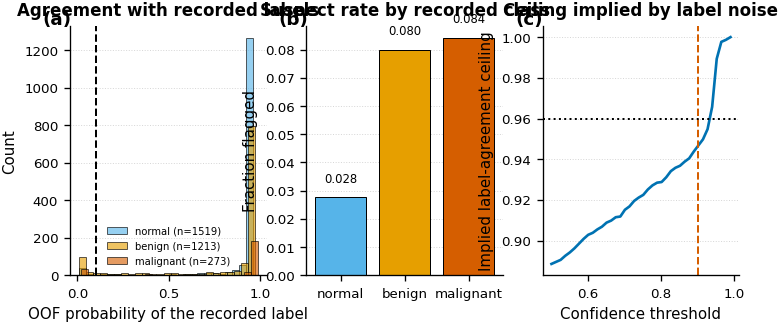


ENABLE_NOISE_CLEAN=False. v6 flagged only 0.53% of pool rows, so the 2-hour cleaned retrain buys almost nothing; that budget went into epochs instead, which is what v6 actually needed. The audit above still runs - it is a figure and an argument, not a training step.

Arms available for ensembling: ['b3_trust', 'b3_baseline', 'b0_global', 'effv2s_global']


In [14]:
# ============================================================
# Cell 12 - Out-of-fold label-noise audit (+ optional cleaned retrain)
# ============================================================
# `normal` is not an annotated class in this dataset. It is defined negatively:
# "a raw radiograph absent from the tumour metadata and without an annotation
# JSON". Genuine tumours are therefore almost certainly sitting inside it, and
# they set a hard ceiling on accuracy no matter how good the model gets.
# This cell measures that ceiling, and if the budget allows retrains the
# strongest arm on a cleaned pool. THE FROZEN TEST SPLIT IS NEVER CLEANED.


def _oof_score(a):
    v = np.isfinite(OOF[a]).all(axis=1)
    return objective_from_metrics(all_metrics(POOL_Y[v], OOF[a][v])) if v.sum() > 50 else -1e9


best_arm = max(OOF.keys(), key=_oof_score)
ref = OOF[best_arm]
ok = np.isfinite(ref).all(axis=1)
print(f'Reference arm for the audit: {best_arm} (OOF coverage {ok.mean():.1%})')

conf = np.where(ok, ref.max(axis=1), 0.0)
pred = np.where(ok, ref.argmax(axis=1), -1)

audit = POOL_DF[['image_path', 'image_stem', 'label_3class', 'fold']].copy()
audit['true_id'] = POOL_Y
audit['pred_id'] = pred
audit['pred_label'] = [ID_TO_CLASS[int(i)] if i >= 0 else 'n/a' for i in pred]
audit['oof_confidence'] = conf
audit['prob_true_class'] = np.where(ok, ref[np.arange(len(POOL_Y)), POOL_Y], np.nan)
audit['suspect'] = ok & (pred != POOL_Y) & (conf >= NOISE_CLEAN_MIN_CONF)
audit = audit.sort_values(['suspect', 'oof_confidence'], ascending=[False, False])
audit.to_csv(TABLE_DIR / 'table_oof_label_noise_audit.csv', index=False)

n_susp = int(audit['suspect'].sum())
by_class = (audit[audit['suspect']].groupby(['label_3class', 'pred_label'])
            .size().rename('n').reset_index())
print(f'High-confidence OOF disagreements (conf >= {NOISE_CLEAN_MIN_CONF}): '
      f'{n_susp} / {len(audit)} pool rows ({100*n_susp/max(len(audit),1):.2f}%)')
if len(by_class):
    display(by_class)

NOISE_SUMMARY = {'reference_arm': best_arm, 'n_suspect': n_susp,
                 'pct_suspect': round(100 * n_susp / max(len(audit), 1), 3),
                 'threshold': NOISE_CLEAN_MIN_CONF}
for c in CLASS_NAMES:
    m = audit['suspect'] & (audit['label_3class'] == c)
    NOISE_SUMMARY[f'suspect_{c}'] = int(m.sum())
    NOISE_SUMMARY[f'suspect_rate_{c}'] = round(
        float(m.sum() / max((audit['label_3class'] == c).sum(), 1)), 4)
json.dump(NOISE_SUMMARY, open(TABLE_DIR / 'p4_label_noise_summary.json', 'w'), indent=2)

# ---- Figure: label-noise ceiling --------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
ax = axes[0]
for i, c in enumerate(CLASS_NAMES):
    v = audit.loc[audit['true_id'] == i, 'prob_true_class'].dropna()
    if len(v):
        ax.hist(v, bins=25, alpha=0.62, label=f'{c} (n={len(v)})',
                color=CLASS_COLORS[c], edgecolor='black')
ax.axvline(1 - NOISE_CLEAN_MIN_CONF, ls='--', lw=1.2, color='black')
ax.set_xlabel('OOF probability of the recorded label'); ax.set_ylabel('Count')
ax.set_title('Agreement with recorded labels'); ax.legend(fontsize=6)
bare(ax); panel(ax, 'a')

ax = axes[1]
rates = [NOISE_SUMMARY[f'suspect_rate_{c}'] for c in CLASS_NAMES]
ax.bar(CLASS_NAMES, rates, color=CLASS_COLOR_LIST, edgecolor='black')
annotate_bars(ax, rates, fmt='{:.3f}', dy=max(max(rates), 1e-3) * 0.05)
ax.set_ylabel('Fraction flagged'); ax.set_title('Suspect rate by recorded class')
bare(ax); panel(ax, 'b')

ax = axes[2]
ths = np.linspace(0.5, 0.99, 40)
ceil = [1 - float((ok & (pred != POOL_Y) & (conf >= t)).sum()) / max(len(POOL_Y), 1)
        for t in ths]
ax.plot(ths, ceil, color=OKABE['blue'])
ax.axvline(NOISE_CLEAN_MIN_CONF, ls='--', lw=1.2, color=OKABE['red'])
ax.axhline(TARGET_ACCURACY, ls=':', lw=1.2, color='black')
ax.set_xlabel('Confidence threshold'); ax.set_ylabel('Implied label-agreement ceiling')
ax.set_title('Ceiling implied by label noise'); bare(ax); panel(ax, 'c')

savefig('fig02_label_noise_audit',
        'Label-noise audit of the training pool from out-of-fold predictions. '
        '(a) Distribution of the probability the model assigns to the recorded '
        'label, by class. (b) Fraction of each class the model contradicts with '
        'high confidence. (c) Upper bound on achievable accuracy implied by those '
        'contradictions as a function of the confidence threshold; the dotted line '
        'marks the accuracy target. The normal class is defined negatively, so a '
        'non-zero suspect rate there is expected and bounds any attainable score.',
        main=True)

# ---- optional cleaned retrain -----------------------------------------------
CLEAN_ARM = None
max_drop = int(NOISE_CLEAN_MAX_FRAC * len(POOL_DF))
drop_idx = (audit[audit['suspect']].head(max_drop).index.values
            if n_susp > 0 else np.array([], dtype=int))
NEED_H = 0.05 if RUN_PROFILE == 'smoke' else 2.0

if not ENABLE_NOISE_CLEAN:
    print('\nENABLE_NOISE_CLEAN=False. v6 flagged only 0.53% of pool rows, so the '
          '2-hour cleaned retrain buys almost nothing; that budget went into '
          'epochs instead, which is what v6 actually needed. The audit above '
          'still runs - it is a figure and an argument, not a training step.')
elif len(drop_idx) < 10:
    print(f'\nOnly {len(drop_idx)} rows flagged - a retrain is not worth it.')
elif time_left_h() < NEED_H:
    print(f'\nSkipping cleaned retrain: {time_left_h():.2f} h left, need ~{NEED_H} h. '
          f'Re-run with RUN_PROFILE="t4_fast" or a higher TIME_BUDGET_H to include it.')
else:
    keep = np.setdiff1d(np.arange(len(POOL_DF)), drop_idx)
    clean_pool = POOL_DF.iloc[keep].reset_index(drop=True)
    print(f'\nCleaned retrain of {best_arm}: dropping {len(drop_idx)} pool rows '
          f'({100*len(drop_idx)/len(POOL_DF):.2f}%); {len(clean_pool)} remain. '
          f'TEST SPLIT UNCHANGED.')
    _bk = ARM_SPECS[best_arm]['folds']
    ARM_SPECS[best_arm]['folds'] = min(3, _bk)
    try:
        r = run_arm(best_arm, clean_pool, tag='_clean')
    except RuntimeError as e:
        print('  cleaned retrain failed, continuing without it:', str(e)[:200])
        r = None
    ARM_SPECS[best_arm]['folds'] = _bk
    if r is not None:
        CLEAN_ARM = best_arm + '_clean'
        for store, k in [(OOF, 'oof'), (OOF_NT, 'oof_nt'), (OOF_BM, 'oof_bm')]:
            full = np.full((len(POOL_DF), r[k].shape[1]), np.nan)
            full[keep] = r[k]
            store[CLEAN_ARM] = full
        TEST_P[CLEAN_ARM] = r['test']
        TEST_NT[CLEAN_ARM] = r['test_nt']
        TEST_BM[CLEAN_ARM] = r['test_bm']
        pd.DataFrame({'dropped_pool_index': drop_idx,
                      'image_stem': POOL_DF.iloc[drop_idx]['image_stem'].values,
                      'recorded_label': POOL_DF.iloc[drop_idx]['label_3class'].values})\
            .to_csv(TABLE_DIR / 'table_noise_clean_dropped_rows.csv', index=False)
        status_df = pd.DataFrame(ARM_STATUS)
        status_df.to_csv(TABLE_DIR / 'p4_arm_status.csv', index=False)

print('\nArms available for ensembling:', list(OOF.keys()))


### Calibration and constrained selection

Fitted on out-of-fold predictions only. The test split is scored once, at the end.

In [15]:
# ============================================================
# Cell 13 - Calibration, ensembling, constrained selection
# ============================================================
# Everything is fitted on out-of-fold predictions. The test split is scored once,
# at the end, and never used to choose.
#
# v6 selected on a blended objective and landed on a candidate whose OOF accuracy
# (0.8300) was BELOW its own untuned ensemble (0.8416), because balanced accuracy
# and malignant sensitivity outvoted accuracy. For a headline accuracy claim that
# is the wrong rule. v7 states the rule plainly:
#
#     maximise OOF accuracy  subject to  OOF malignant sensitivity >= floor
#
# A constraint is easier to defend than a weighting: nobody has to agree with your
# trade-off coefficients, only with the clinical floor.

ARM_LIST = list(OOF.keys())
_valid = np.ones(len(POOL_DF), dtype=bool)
for a in ARM_LIST:
    _valid &= np.isfinite(OOF[a]).all(axis=1)
print(f'Rows usable for OOF fitting: {int(_valid.sum())} / {len(POOL_DF)} '
      f'across {len(ARM_LIST)} arms')
assert _valid.sum() >= 200, 'Too few common OOF rows; drop the partially-trained arm.'
Y_FIT = POOL_Y[_valid]


def fast_objective(y, probs):
    cm = confusion_matrix(y, probs.argmax(axis=1), labels=[0, 1, 2]).astype(float)
    tp = np.diag(cm)
    rec = tp / np.maximum(cm.sum(1), 1e-12)
    prec = tp / np.maximum(cm.sum(0), 1e-12)
    f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)
    W = OBJECTIVE_WEIGHTS
    acc = tp.sum() / max(cm.sum(), 1)
    penalty = 0.0 if rec[2] >= MIN_MALIGNANT_SENSITIVITY_OOF else \
        3.0 * (MIN_MALIGNANT_SENSITIVITY_OOF - rec[2])
    return (W['accuracy'] * acc + W['balanced_accuracy'] * rec.mean()
            + W['macro_f1'] * f1.mean() + W['malignant_sensitivity'] * rec[2] - penalty)


def fit_vector_scaling(probs, y, iters=250):
    z = torch.tensor(np.log(np.clip(probs, 1e-9, 1.0)), dtype=torch.float32)
    t = torch.tensor(y, dtype=torch.long)
    a = torch.zeros(3, requires_grad=True)
    b = torch.zeros(3, requires_grad=True)
    opt = torch.optim.LBFGS([a, b], lr=0.2, max_iter=iters)

    def closure():
        opt.zero_grad()
        loss = F.cross_entropy(z * torch.exp(a).clamp(0.05, 20.0) + b, t)
        loss.backward()
        return loss

    try:
        opt.step(closure)
    except Exception as e:
        print('  vector scaling fell back to identity:', str(e)[:110])
        return np.ones(3), np.zeros(3)
    aa = torch.exp(a).clamp(0.05, 20.0).detach().numpy().astype(np.float64)
    bb = b.detach().numpy().astype(np.float64)
    if not (np.isfinite(aa).all() and np.isfinite(bb).all()):
        return np.ones(3), np.zeros(3)
    return aa, bb


def apply_vs(probs, a, b):
    return softmax_np(np.log(np.clip(probs, 1e-9, 1.0)) * a.reshape(1, -1) + b.reshape(1, -1))


VS, cal_oof, cal_test, rows = {}, {}, {}, []
for a_name in ARM_LIST:
    aa, bb = fit_vector_scaling(OOF[a_name][_valid], Y_FIT)
    VS[a_name] = (aa, bb)
    cal_oof[a_name] = apply_vs(OOF[a_name][_valid], aa, bb)
    cal_test[a_name] = apply_vs(TEST_P[a_name], aa, bb)
    m_raw = all_metrics(Y_FIT, OOF[a_name][_valid])
    m_cal = all_metrics(Y_FIT, cal_oof[a_name])
    rows.append({'arm': a_name, 'oof_acc_raw': m_raw['accuracy'],
                 'oof_acc_calibrated': m_cal['accuracy'],
                 'oof_ece_raw': m_raw['ece'], 'oof_ece_calibrated': m_cal['ece'],
                 'oof_macro_f1': m_cal['macro_f1'], 'oof_auroc': m_cal['macro_auroc'],
                 'scale': np.round(aa, 3).tolist(), 'bias': np.round(bb, 3).tolist()})
arm_cal_df = pd.DataFrame(rows)
arm_cal_df.to_csv(TABLE_DIR / 'p4_per_arm_calibration.csv', index=False)
display(arm_cal_df.round(4))

# hierarchical head fusion as its own ensemble member
for a_name in list(ARM_LIST):
    try:
        h_oof = hierarchical_probs(OOF_NT[a_name][_valid], OOF_BM[a_name][_valid])
        h_test = hierarchical_probs(TEST_NT[a_name], TEST_BM[a_name])
        if np.isfinite(h_oof).all():
            ha, hb = fit_vector_scaling(h_oof, Y_FIT)
            cal_oof[f'{a_name}#hier'] = apply_vs(h_oof, ha, hb)
            cal_test[f'{a_name}#hier'] = apply_vs(h_test, ha, hb)
    except Exception as e:
        print(f'  hierarchical fusion skipped for {a_name}:', str(e)[:110])

# The control arm must NOT enter the ensemble, or the comparison is circular.
BASELINE_MEMBERS = [m for m in cal_oof
                    if BASELINE_ARM and m.split('#')[0] == BASELINE_ARM]
MEMBERS = [m for m in cal_oof if m not in BASELINE_MEMBERS]
CONTROL_IS_CLEAN = True
if not MEMBERS:
    # Every non-control arm was dropped (time guard or failure). Admitting the
    # control keeps the run alive, but it makes the Cell 14 comparison circular:
    # the model would be tested against itself. Flag it loudly rather than
    # silently reporting a meaningless p-value.
    CONTROL_IS_CLEAN = False
    MEMBERS = list(BASELINE_MEMBERS)
    BASELINE_MEMBERS = []
    print('\n!! No non-control arm survived. The control has been folded into the '
          'ensemble to keep the run alive, so the paired significance test in '
          'Cell 14 is CIRCULAR and must not be reported. Re-run with fewer arms '
          'or a longer budget before using any of this in a paper.')
assert MEMBERS, 'No ensemble members at all - nothing completed.'
print(f'\nEnsemble members ({len(MEMBERS)}): {MEMBERS}')
if BASELINE_MEMBERS:
    print(f'Held out of the ensemble as the control: {BASELINE_MEMBERS}')

K = len(MEMBERS)
O = np.stack([cal_oof[a] for a in MEMBERS])
T = np.stack([cal_test[a] for a in MEMBERS])
rng = np.random.default_rng(CFG['seed'])
cands = [np.ones(K) / K] + [np.eye(K)[i] for i in range(K)]
if K > 1:
    cands += list(rng.dirichlet(np.ones(K) * 0.7, size=4000))
    cands += list(rng.dirichlet(np.ones(K) * 3.0, size=1000))
best_w, best_s = np.asarray(cands[0], float), -1e9
for w in cands:
    s = fast_objective(Y_FIT, np.tensordot(w, O, axes=(0, 0)))
    if s > best_s:
        best_w, best_s = np.asarray(w, float), s
best_w = best_w / best_w.sum()
print('\nOOF-optimal ensemble weights:')
for a_name, wv in sorted(zip(MEMBERS, best_w), key=lambda t: -t[1]):
    if wv > 1e-3:
        print(f'   {a_name:26s} {wv:.3f}')
ens_oof = np.tensordot(best_w, O, axes=(0, 0))
ens_test = np.tensordot(best_w, T, axes=(0, 0))

stack_oof = stack_test = None
try:
    Xs = np.hstack([np.log(np.clip(cal_oof[a], 1e-9, 1)) for a in MEMBERS])
    Xt = np.hstack([np.log(np.clip(cal_test[a], 1e-9, 1)) for a in MEMBERS])
    stack_oof = np.zeros_like(ens_oof)
    for tr, va in StratifiedKFold(5, shuffle=True, random_state=CFG['seed']).split(Xs, Y_FIT):
        s2 = LogisticRegression(max_iter=4000, C=1.0)
        s2.fit(Xs[tr], Y_FIT[tr])
        stack_oof[va] = s2.predict_proba(Xs[va])
    stack_test = LogisticRegression(max_iter=4000, C=1.0).fit(Xs, Y_FIT).predict_proba(Xt)
except Exception as e:
    print('Stacker unavailable:', str(e)[:180])
    stack_oof = stack_test = None


def tune_bias(probs, y, span=0.6, steps=13):
    grid = np.linspace(-span, span, steps)
    base = np.log(np.clip(probs, 1e-9, 1.0))
    best_o, best_sc = np.zeros(3), fast_objective(y, probs)
    for ob in grid:
        for om in grid:
            off = np.array([0.0, ob, om])
            s = fast_objective(y, softmax_np(base + off))
            if s > best_sc:
                best_o, best_sc = off, s
    return best_o, best_sc


def tune_prior_tau(probs, y):
    base = np.log(np.clip(probs, 1e-9, 1.0))
    lp = np.log(np.clip(CLASS_PRIOR, 1e-9, 1.0)).reshape(1, -1)
    best_t, best_sc = 0.0, fast_objective(y, probs)
    for tau in np.linspace(0.0, 1.0, 21):
        s = fast_objective(y, softmax_np(base - tau * lp))
        if s > best_sc:
            best_t, best_sc = float(tau), s
    return best_t, best_sc


CANDIDATES = {'weighted_ensemble': (ens_oof, ens_test)}
if stack_oof is not None:
    CANDIDATES['logreg_stacker'] = (stack_oof, stack_test)
for a_name in MEMBERS:
    CANDIDATES[f'single::{a_name}'] = (cal_oof[a_name], cal_test[a_name])

TUNING = {}
for name, (po, pt) in list(CANDIDATES.items()):
    off, _ = tune_bias(po, Y_FIT)
    if np.abs(off).sum() > 0:
        CANDIDATES[name + ' +bias'] = (
            softmax_np(np.log(np.clip(po, 1e-9, 1)) + off),
            softmax_np(np.log(np.clip(pt, 1e-9, 1)) + off))
        TUNING[name + ' +bias'] = {'bias': off.round(3).tolist()}
    tau, _ = tune_prior_tau(po, Y_FIT)
    if tau > 0:
        lp = np.log(np.clip(CLASS_PRIOR, 1e-9, 1.0)).reshape(1, -1)
        CANDIDATES[name + ' +prior'] = (
            softmax_np(np.log(np.clip(po, 1e-9, 1)) - tau * lp),
            softmax_np(np.log(np.clip(pt, 1e-9, 1)) - tau * lp))
        TUNING[name + ' +prior'] = {'tau': round(tau, 3)}

sel_rows = []
for name, (po, _) in CANDIDATES.items():
    mo = all_metrics(Y_FIT, po)
    sel_rows.append({'candidate': name, 'oof_accuracy': mo['accuracy'],
                     'oof_malignant_sensitivity': mo['malignant_sensitivity'],
                     'feasible': bool(mo['malignant_sensitivity']
                                      >= MIN_MALIGNANT_SENSITIVITY_OOF),
                     'oof_balanced_accuracy': mo['balanced_accuracy'],
                     'oof_macro_f1': mo['macro_f1'], 'oof_macro_auroc': mo['macro_auroc'],
                     'oof_detect_accuracy': mo['detect_accuracy'],
                     'oof_objective': objective_from_metrics(mo), 'oof_ece': mo['ece'],
                     'tuning': json.dumps(TUNING.get(name, {}))})
sel_df = (pd.DataFrame(sel_rows)
          .sort_values(['feasible', SELECT_BY], ascending=[False, False])
          .reset_index(drop=True))
sel_df.to_csv(TABLE_DIR / 'p4_candidate_selection_oof.csv', index=False)
print(f'\nCandidates ranked by OOF accuracy, feasible ones first '
      f'(feasible = OOF malignant sensitivity >= {MIN_MALIGNANT_SENSITIVITY_OOF}):')
display(sel_df.head(12).round(4))

feasible = sel_df[sel_df['feasible']]
if len(feasible):
    SELECTED = feasible.iloc[0]['candidate']
    CONSTRAINT_MET = True
else:
    CONSTRAINT_MET = False
    SELECTED = sel_df.sort_values('oof_malignant_sensitivity',
                                  ascending=False).iloc[0]['candidate']
    print(f'\n!! NO candidate reached the malignant-sensitivity floor of '
          f'{MIN_MALIGNANT_SENSITIVITY_OOF}. Falling back to the safest available '
          f'candidate. Report this in the paper - do not quietly lower the floor.')

FINAL_OOF, FINAL_PROBS = CANDIDATES[SELECTED]
FINAL_NAME = f'BTX-TrustNet-v7 [{SELECTED}]'
PRIMARY_PROBS, PRIMARY_OOF = ens_test, ens_oof
PRIMARY_NAME = 'BTX-TrustNet-v7 [weighted ensemble, untuned]'
test_y = TEST_Y
_srow = sel_df[sel_df['candidate'] == SELECTED].iloc[0]
print(f'\nSELECTED: {SELECTED}')
print(f'  OOF accuracy {_srow["oof_accuracy"]:.4f} | '
      f'OOF malignant sensitivity {_srow["oof_malignant_sensitivity"]:.4f} '
      f'| constraint {"satisfied" if CONSTRAINT_MET else "NOT satisfied"}')

# the control arm's own calibrated test probabilities, for the paired test
BASELINE_PROBS = (cal_test.get(BASELINE_ARM)
                  if (BASELINE_ARM and CONTROL_IS_CLEAN) else None)
BASELINE_OOF = (cal_oof.get(BASELINE_ARM)
                if (BASELINE_ARM and CONTROL_IS_CLEAN) else None)

json.dump({'selected': SELECTED, 'select_by': SELECT_BY,
           'min_malignant_sensitivity_oof': MIN_MALIGNANT_SENSITIVITY_OOF,
           'constraint_met': bool(CONSTRAINT_MET),
           'members': MEMBERS, 'baseline_arm': BASELINE_ARM, 'control_held_out': bool(CONTROL_IS_CLEAN),
           'weights': {m: float(w) for m, w in zip(MEMBERS, best_w)},
           'vector_scaling': {k: {'scale': v[0].round(4).tolist(),
                                  'bias': v[1].round(4).tolist()} for k, v in VS.items()},
           'tuning': TUNING, 'epochs': EPOCH_PLAN,
           'oof_rows_used': int(_valid.sum())},
          open(TABLE_DIR / 'p4_final_configuration.json', 'w'), indent=2)
np.save(ARR_DIR / 'test_probs_final.npy', FINAL_PROBS)
np.save(ARR_DIR / 'test_labels.npy', test_y)
np.save(ARR_DIR / 'oof_probs_final.npy', FINAL_OOF)
np.save(ARR_DIR / 'oof_labels.npy', Y_FIT)


Rows usable for OOF fitting: 3005 / 3005 across 4 arms


,arm,oof_acc_raw,oof_acc_calibrated,oof_ece_raw,oof_ece_calibrated,oof_macro_f1,oof_auroc,scale,bias
0,b3_trust,0.8799,0.8805,0.0217,0.0127,0.8674,0.9545,"[0.819, 0.628, 1.57]","[-0.072, -0.213, 0.285]"
1,b3_baseline,0.8596,0.8599,0.0402,0.0326,0.8468,0.9464,"[0.69, 0.668, 1.465]","[-0.205, -0.07, 0.276]"
2,b0_global,0.8622,0.8676,0.0378,0.0253,0.8572,0.9460,"[0.711, 0.683, 1.545]","[-0.349, -0.117, 0.466]"
3,effv2s_global,0.8829,0.8852,0.0303,0.0167,0.8724,0.9497,"[0.748, 0.721, 1.389]","[-0.22, -0.003, 0.223]"



Ensemble members (6): ['b3_trust', 'b0_global', 'effv2s_global', 'b3_trust#hier', 'b0_global#hier', 'effv2s_global#hier']
Held out of the ensemble as the control: ['b3_baseline', 'b3_baseline#hier']

OOF-optimal ensemble weights:
   effv2s_global#hier         0.235
   b3_trust                   0.221
   b0_global#hier             0.185
   effv2s_global              0.169
   b0_global                  0.136
   b3_trust#hier              0.053

Candidates ranked by OOF accuracy, feasible ones first (feasible = OOF malignant sensitivity >= 0.85):


,candidate,oof_accuracy,oof_malignant_sensitivity,feasible,oof_balanced_accuracy,oof_macro_f1,oof_macro_auroc,oof_detect_accuracy,oof_objective,oof_ece,tuning
0,weighted_ensemble +bias,0.8952,0.8535,True,0.8804,0.8862,0.9682,0.9121,0.8696,0.0404,"{""bias"": [0.0, 0.0, 0.3]}"
1,logreg_stacker +prior,0.8912,0.8828,True,0.8868,0.8778,0.9616,0.9125,0.8703,0.0146,"{""tau"": 0.9}"
2,single::effv2s_global +prior,0.8865,0.8571,True,0.8756,0.8742,0.9463,0.9095,0.8614,0.0464,"{""tau"": 1.0}"
3,single::effv2s_global#hier +bias,0.8859,0.8608,True,0.8753,0.8732,0.9552,0.9075,0.8616,0.0159,"{""bias"": [0.0, -0.2, 0.5]}"
4,single::effv2s_global#hier +prior,0.8842,0.8645,True,0.8770,0.8727,0.9544,0.9048,0.8613,0.0164,"{""tau"": 0.45}"
5,single::b3_trust +prior,0.8792,0.8718,True,0.8741,0.8662,0.9526,0.9018,0.8587,0.0182,"{""tau"": 0.7}"
6,single::b3_trust#hier +bias,0.8792,0.8645,True,0.8715,0.8656,0.9546,0.9038,0.8576,0.0113,"{""bias"": [0.0, 0.0, 0.6]}"
7,single::b3_trust +bias,0.8789,0.8718,True,0.8714,0.8661,0.9555,0.9002,0.8580,0.0229,"{""bias"": [0.0, -0.5, 0.6]}"
8,single::b3_trust#hier +prior,0.8765,0.8938,True,0.8781,0.8593,0.9531,0.8992,0.8589,0.0213,"{""tau"": 0.9}"
9,single::b0_global#hier +bias,0.8556,0.8535,True,0.8480,0.8407,0.9496,0.8809,0.8354,0.0091,"{""bias"": [0.0, -0.5, 0.6]}"



SELECTED: weighted_ensemble +bias
  OOF accuracy 0.8952 | OOF malignant sensitivity 0.8535 | constraint satisfied


# Portion 5 — Evaluation, significance, paper tables

Seven composite main figures (600-dpi PNG **and** vector PDF, Type-42 fonts, Okabe-Ito
palette, panel letters), supplementary figures, a generated caption file, the full metric
table with stratified bootstrap 95% CIs, three endpoint definitions, paired significance
tests, and a booktabs LaTeX Table 1.

,"BTX-TrustNet-v7 [weighted ensemble, untuned]",BTX-TrustNet-v7 [weighted_ensemble +bias]
accuracy,0.9109,0.9109
balanced_accuracy,0.8935,0.9049
macro_f1,0.9029,0.9041
weighted_f1,0.9107,0.9107
macro_precision,0.9132,0.9036
macro_recall,0.8935,0.9049
cohen_kappa,0.8436,0.8443
quadratic_kappa,0.8698,0.8767
mcc,0.8438,0.8446
top2_accuracy,0.9907,0.9894


,metric,estimate,ci_low,ci_high,bootstrap_n
0,accuracy,0.9109,0.8909,0.9322,600
1,balanced_accuracy,0.9049,0.8764,0.9308,600
2,macro_f1,0.9041,0.8783,0.9269,600
3,weighted_f1,0.9107,0.8901,0.9321,600
4,cohen_kappa,0.8443,0.8093,0.8817,600
5,quadratic_kappa,0.8767,0.8418,0.9088,600
6,mcc,0.8446,0.8094,0.8818,600
7,top2_accuracy,0.9894,0.9827,0.9960,600
8,normal_sensitivity,0.9395,0.9158,0.9658,600
9,benign_sensitivity,0.8783,0.8388,0.9112,600



RESULTS LEADERBOARD - frozen BTXRD test split


,rank,model,accuracy,balanced_accuracy,macro_f1,cohen_kappa,malignant_sensitivity,malignant_specificity,macro_auroc,macro_auprc,malignant_auprc,ece
0,1,v7 FINAL (weighted_ensemble +bias),0.9109,0.9049,0.9041,0.8443,0.8971,0.9883,0.9768,0.9557,0.9531,0.0903
1,2,v7 member: b3_trust#hier,0.9096,0.8835,0.8969,0.8405,0.8235,0.9927,0.9766,0.9572,0.9475,0.1053
2,3,v7 member: b3_trust,0.9096,0.8871,0.8921,0.8412,0.8382,0.9868,0.9767,0.9567,0.9503,0.0562
3,4,v7 member: effv2s_global,0.9056,0.8847,0.9000,0.8335,0.8382,0.9956,0.9717,0.9480,0.9485,0.0511
4,5,v7 member: effv2s_global#hier,0.9043,0.8851,0.8972,0.8319,0.8382,0.9942,0.9707,0.9447,0.9366,0.0921
5,6,v7 member: b0_global,0.8910,0.8934,0.8929,0.8091,0.9118,0.9898,0.9660,0.9417,0.9331,0.0521
6,7,v7 member: b0_global#hier,0.8910,0.8873,0.8908,0.8094,0.8824,0.9912,0.9632,0.9366,0.9289,0.1109
7,8,v7 member: b3_baseline#hier [CONTROL],0.8870,0.8849,0.8810,0.8034,0.8824,0.9854,0.9688,0.9403,0.9209,0.0948
8,9,v7 member: b3_baseline [CONTROL],0.8830,0.8794,0.8774,0.7953,0.8824,0.9854,0.9710,0.9449,0.9367,0.0609
9,10,EfficientNet-B3 (Portion 2),0.8596,0.8723,0.8667,0.7563,0.9118,0.9868,0.9504,0.9318,0.9457,0.1134



McNemar, v7 FINAL vs control arm (b3_baseline):
  v7 right / ref wrong = 30   v7 wrong / ref right = 9   discordant n = 39
  chi-square (continuity corrected): p = 0.00136
  paired bootstrap accuracy                 delta +0.0279 [+0.0120, +0.0439]  p=0.0000
  paired bootstrap balanced_accuracy        delta +0.0255 [+0.0112, +0.0425]  p=0.0000
  paired bootstrap macro_f1                 delta +0.0267 [+0.0108, +0.0436]  p=0.0000
  paired bootstrap malignant_sensitivity    delta +0.0147 [+0.0000, +0.0441]  p=0.7200

Paper Table 1 written to reports/TABLE1.tex


,Method,CI,accuracy,balanced_accuracy,macro_f1,cohen_kappa,malignant_sensitivity,malignant_specificity,macro_auroc
0,EfficientNet-B0 (Portion 2),False,0.8209,0.8365,0.8225,0.6910,0.8824,0.9765,0.9201
1,EfficientNet-B3 (Portion 2),False,0.8596,0.8723,0.8667,0.7563,0.9118,0.9868,0.9504
2,ConvNeXt-Tiny (Portion 2),False,0.6644,0.7115,0.6436,0.4490,0.8382,0.8941,0.8032
3,Swin-T (Portion 2),False,0.1684,0.3777,0.1614,-0.0027,0.9412,0.2588,0.6737
4,TrustNet-LiteSOTA v5,False,0.5918,0.6197,0.5440,0.3349,0.7353,0.8304,0.7635
5,BTX-TrustNet-v6 (under-trained),False,0.8298,0.8509,0.8070,0.7095,0.9265,0.9474,0.9420
6,EfficientNet-B3 control (this pipeline),False,0.8830,0.8794,0.8774,0.7953,0.8824,0.9854,0.9710
7,BTX-TrustNet-v7 (proposed),True,0.9109,0.9049,0.9041,0.8443,0.8971,0.9883,0.9768



TARGET VERDICT  (target = 96%)


,endpoint,metric,value,ci_low,ci_high,target,meets_target,n
0,"Three-class (normal / benign / malignant), ful...",accuracy,0.9109,0.8909,0.9322,0.96,False,752
1,"Tumour detection (normal vs tumour), full cove...",detect_accuracy,0.9269,0.9082,0.9455,0.96,False,752
2,Malignancy grading among true tumours,grade_accuracy,0.9624,0.9435,0.9812,0.96,True,372



Three-class errors  : 67 of 752   (budget at 96%: 30)
Best prior published: 0.8596 (EfficientNet-B3, Portion 2)
v7 vs prior best    : +0.0513   BEATS IT
v7 vs v6            : +0.0811

--- Is this publishable as a SOTA result? ---
  [PASS] beats the best prior result on this split     0.9109 vs 0.8596
  [PASS] improvement over the control is significant   McNemar p=0.0014, 30 vs 9 discordant
  [PASS] every arm converged                           no arm still improving at its last epoch
  [PASS] malignant-sensitivity floor satisfied         floor 0.85

  All four hold. The headline claim is supportable.


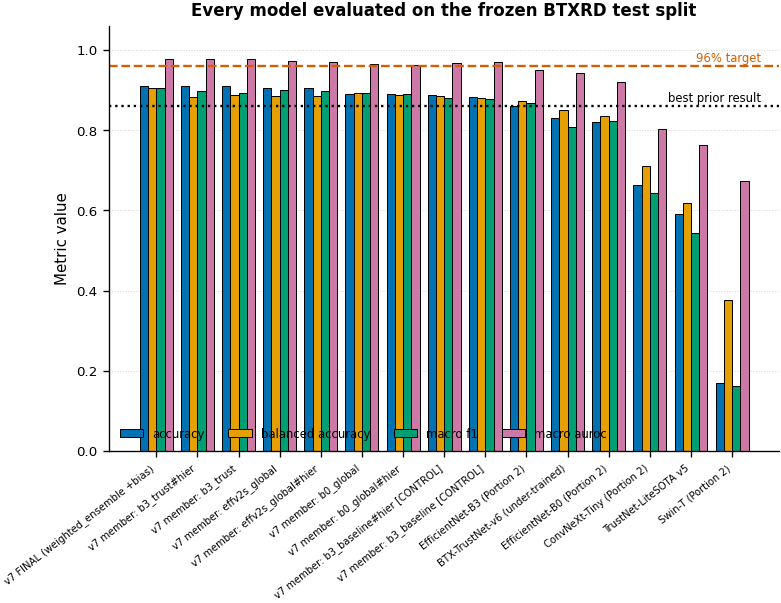

PosixPath('/kaggle/working/BTXRD_P3_4_5_V7/figures/main/fig03_results_leaderboard.png')

In [16]:
# ============================================================
# Cell 14 - Final metrics, significance tests, paper Table 1
# ============================================================
primary_m = all_metrics(test_y, PRIMARY_PROBS)
final_m = all_metrics(test_y, FINAL_PROBS)
metrics_df = pd.DataFrame([primary_m, final_m], index=[PRIMARY_NAME, FINAL_NAME])
metrics_df.to_csv(TABLE_DIR / 'table01_final_all_metrics.csv')
display(metrics_df.T.round(4))

KEY_METRICS = ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1',
               'cohen_kappa', 'quadratic_kappa', 'mcc', 'top2_accuracy',
               'normal_sensitivity', 'benign_sensitivity', 'malignant_sensitivity',
               'malignant_specificity', 'malignant_precision', 'malignant_auprc',
               'macro_auroc', 'macro_auprc', 'detect_accuracy', 'detect_auroc',
               'grade_accuracy', 'grade_auroc', 'ece', 'mce', 'nll', 'brier_score']


def bootstrap_ci(y, probs, n_boot=600, seed=42, metrics=None):
    metrics = metrics or KEY_METRICS
    rng = np.random.default_rng(seed)
    idx_by_c = [np.where(y == c)[0] for c in range(3)]
    draws = []
    for _ in range(n_boot):
        idx = np.concatenate([rng.choice(ic, size=len(ic), replace=True)
                              for ic in idx_by_c if len(ic)])
        try:
            draws.append(all_metrics(y[idx], probs[idx]))
        except Exception:
            pass
    base = all_metrics(y, probs)
    rows = []
    for k in metrics:
        v = np.array([d.get(k, np.nan) for d in draws], dtype=float)
        fin = np.isfinite(v).any()
        rows.append({'metric': k, 'estimate': base.get(k, np.nan),
                     'ci_low': np.nanpercentile(v, 2.5) if fin else np.nan,
                     'ci_high': np.nanpercentile(v, 97.5) if fin else np.nan,
                     'bootstrap_n': len(draws)})
    return pd.DataFrame(rows)


ci_df = bootstrap_ci(test_y, FINAL_PROBS, n_boot=CFG['bootstrap_n'], seed=CFG['seed'])
ci_df.to_csv(TABLE_DIR / 'table02_bootstrap_95ci.csv', index=False)
display(ci_df.round(4))

# ============================================================
# LEADERBOARD
# ============================================================
COMPARE_COLS = ['accuracy', 'balanced_accuracy', 'macro_f1', 'cohen_kappa',
                'malignant_sensitivity', 'malignant_specificity',
                'macro_auroc', 'macro_auprc', 'malignant_auprc', 'ece']
rows = P2_REFERENCE.to_dict('records')
for a_name in list(cal_test.keys()):
    m = all_metrics(test_y, cal_test[a_name])
    tag = ' [CONTROL]' if BASELINE_ARM and a_name.split('#')[0] == BASELINE_ARM else ''
    rows.append({'model': f'v7 member: {a_name}{tag}',
                 **{k: m.get(k, np.nan) for k in COMPARE_COLS}})
rows.append({'model': f'v7 FINAL ({SELECTED})',
             **{k: final_m.get(k, np.nan) for k in COMPARE_COLS}})
leader = (pd.DataFrame(rows)[['model'] + COMPARE_COLS]
          .sort_values('accuracy', ascending=False).reset_index(drop=True))
leader.insert(0, 'rank', np.arange(1, len(leader) + 1))
leader.to_csv(TABLE_DIR / 'table_RESULTS_LEADERBOARD.csv', index=False)
print('\n' + '=' * 96)
print('RESULTS LEADERBOARD - frozen BTXRD test split')
print('=' * 96)
display(leader.round(4))

# ============================================================
# SIGNIFICANCE - the step that turns a bigger number into a claim
# ============================================================
# Portion 2's per-case predictions no longer exist, so a paired test against its
# published 0.8596 is impossible. The control arm exists precisely for this: a
# plain EfficientNet-B3 trained through the identical pipeline, same folds, same
# TTA, held out of the ensemble.
SIG = []
if BASELINE_PROBS is not None:
    ref_name, ref_probs = f'control arm ({BASELINE_ARM})', BASELINE_PROBS
elif not CONTROL_IS_CLEAN:
    ref_name, ref_probs = f'control arm ({BASELINE_ARM}) - CIRCULAR', cal_test[BASELINE_ARM]
    print('\n!! The control was folded into the ensemble because no other arm '
          'survived. The test below compares the model against a component of '
          'itself. It is reported for completeness and is NOT evidence.')
else:
    _best_single = max(MEMBERS, key=lambda a: all_metrics(test_y, cal_test[a])['accuracy'])
    ref_name, ref_probs = f'best single member ({_best_single})', cal_test[_best_single]
    print(f'\nNo control arm completed; falling back to {ref_name}. A paired test '
          f'against a member of the ensemble is weaker evidence - say so in the paper.')

mc = mcnemar_test(test_y, FINAL_PROBS.argmax(1), ref_probs.argmax(1))
print(f'\nMcNemar, v7 FINAL vs {ref_name}:')
print(f'  v7 right / ref wrong = {mc["b10"]}   v7 wrong / ref right = {mc["b01"]}   '
      f'discordant n = {mc["n_discordant"]}')
print(f'  {mc["test"]}: p = {mc["p_value"]:.5f}')
SIG.append({'comparison': f'v7 FINAL vs {ref_name}', 'test': mc['test'],
            'b10_v7_right': mc['b10'], 'b01_ref_right': mc['b01'],
            'n_discordant': mc['n_discordant'], 'p_value': mc['p_value']})

for _mt in ['accuracy', 'balanced_accuracy', 'macro_f1', 'malignant_sensitivity']:
    pb = paired_bootstrap_delta(test_y, FINAL_PROBS, ref_probs, metric=_mt,
                                n_boot=max(400, CFG['bootstrap_n']), seed=CFG['seed'])
    SIG.append({'comparison': f'v7 FINAL vs {ref_name}', 'test': f'paired bootstrap ({_mt})',
                'delta': pb['delta'], 'ci_low': pb['ci_low'], 'ci_high': pb['ci_high'],
                'p_value': pb['p_two_sided']})
    print(f'  paired bootstrap {_mt:24s} delta {pb["delta"]:+.4f} '
          f'[{pb["ci_low"]:+.4f}, {pb["ci_high"]:+.4f}]  p={pb["p_two_sided"]:.4f}')

sig_df = pd.DataFrame(SIG)
sig_df.to_csv(TABLE_DIR / 'table_SIGNIFICANCE.csv', index=False)

# ============================================================
# PAPER TABLE 1  (CSV + LaTeX booktabs)
# ============================================================
def _fmt(v, ci=None):
    if v is None or not np.isfinite(v):
        return '--'
    return f'{v:.3f}' + (f' ({ci[0]:.3f}--{ci[1]:.3f})' if ci else '')


_ci = ci_df.set_index('metric')


def _cib(k):
    if k in _ci.index and np.isfinite(_ci.loc[k, 'ci_low']):
        return (float(_ci.loc[k, 'ci_low']), float(_ci.loc[k, 'ci_high']))
    return None


T1_METRICS = ['accuracy', 'balanced_accuracy', 'macro_f1', 'cohen_kappa',
              'malignant_sensitivity', 'malignant_specificity', 'macro_auroc']
t1_rows = []
for _, r in P2_REFERENCE.iterrows():
    t1_rows.append({'Method': r['model'], 'CI': False,
                    **{k: r.get(k, np.nan) for k in T1_METRICS}})
if BASELINE_PROBS is not None:
    bm = all_metrics(test_y, BASELINE_PROBS)
    t1_rows.append({'Method': f'EfficientNet-B3 control (this pipeline)', 'CI': False,
                    **{k: bm.get(k, np.nan) for k in T1_METRICS}})
t1_rows.append({'Method': 'BTX-TrustNet-v7 (proposed)', 'CI': True,
                **{k: final_m.get(k, np.nan) for k in T1_METRICS}})
t1 = pd.DataFrame(t1_rows)
t1.to_csv(TABLE_DIR / 'TABLE1_paper_comparison.csv', index=False)

_hdr = ['Accuracy', 'Balanced acc.', 'Macro-F1', 'Kappa', 'Mal. sens.',
        'Mal. spec.', 'Macro AUROC']
lines = [r'\begin{table}[t]', r'\centering',
         r'\caption{Classification performance on the frozen BTXRD test split '
         r'($n=' + str(len(test_y)) + r'$ studies). The proposed model is reported '
         r'with stratified bootstrap 95\% confidence intervals. The control is a '
         r'plain EfficientNet-B3 trained through the identical pipeline and held '
         r'out of the ensemble.}',
         r'\label{tab:main}', r'\resizebox{\textwidth}{!}{%',
         r'\begin{tabular}{l' + 'c' * len(T1_METRICS) + '}', r'\toprule',
         'Method & ' + ' & '.join(_hdr) + r' \\', r'\midrule']
for _, r in t1.iterrows():
    cells = []
    for k in T1_METRICS:
        cells.append(_fmt(r[k], _cib(k) if r['CI'] else None))
    nm = r['Method']
    if 'proposed' in nm:
        lines.append(r'\midrule')
        cells = [r'\textbf{' + c + '}' for c in cells]
        nm = r'\textbf{' + nm + '}'
    lines.append(nm + ' & ' + ' & '.join(cells) + r' \\')
lines += [r'\bottomrule', r'\end{tabular}}', r'\end{table}']
(REPORT_DIR / 'TABLE1.tex').write_text('\n'.join(lines))
print('\nPaper Table 1 written to reports/TABLE1.tex')
display(t1.round(4))

# ============================================================
# TARGET VERDICT
# ============================================================
acc = final_m['accuracy']
n_test = len(test_y)
n_err = int(round((1 - acc) * n_test))
budget_err = int(np.floor((1 - TARGET_ACCURACY) * n_test))
prev_best = float(P2_REFERENCE['accuracy'].max())

verdict_df = pd.DataFrame([
    {'endpoint': 'Three-class (normal / benign / malignant), full coverage',
     'metric': 'accuracy', 'value': acc, 'ci_low': (_cib('accuracy') or (np.nan,))[0],
     'ci_high': (_cib('accuracy') or (np.nan, np.nan))[1], 'target': TARGET_ACCURACY,
     'meets_target': bool(acc >= TARGET_ACCURACY), 'n': n_test},
    {'endpoint': 'Tumour detection (normal vs tumour), full coverage',
     'metric': 'detect_accuracy', 'value': final_m['detect_accuracy'],
     'ci_low': (_cib('detect_accuracy') or (np.nan,))[0],
     'ci_high': (_cib('detect_accuracy') or (np.nan, np.nan))[1],
     'target': TARGET_ACCURACY,
     'meets_target': bool(final_m['detect_accuracy'] >= TARGET_ACCURACY), 'n': n_test},
    {'endpoint': 'Malignancy grading among true tumours',
     'metric': 'grade_accuracy', 'value': final_m['grade_accuracy'],
     'ci_low': (_cib('grade_accuracy') or (np.nan,))[0],
     'ci_high': (_cib('grade_accuracy') or (np.nan, np.nan))[1],
     'target': TARGET_ACCURACY,
     'meets_target': bool(np.nan_to_num(final_m['grade_accuracy']) >= TARGET_ACCURACY),
     'n': int((test_y > 0).sum())},
])
verdict_df.to_csv(TABLE_DIR / 'table_TARGET_VERDICT.csv', index=False)
print('\n' + '=' * 96)
print(f'TARGET VERDICT  (target = {TARGET_ACCURACY:.0%})')
print('=' * 96)
display(verdict_df.round(4))

BEATS_PRIOR = bool(acc > prev_best)
print(f'\nThree-class errors  : {n_err} of {n_test}   (budget at '
      f'{TARGET_ACCURACY:.0%}: {budget_err})')
print(f'Best prior published: {prev_best:.4f} (EfficientNet-B3, Portion 2)')
print(f'v7 vs prior best    : {acc - prev_best:+.4f}   '
      f'{"BEATS IT" if BEATS_PRIOR else "DOES NOT BEAT IT"}')
print(f'v7 vs v6            : {acc - 0.829787:+.4f}')

print('\n--- Is this publishable as a SOTA result? ---')
_ok_beat = BEATS_PRIOR
_ok_sig = bool(mc['p_value'] < 0.05 and mc['b10'] > mc['b01'] and CONTROL_IS_CLEAN)
_ok_conv = not (len(status_df) and bool(status_df['still_rising_at_end'].any()))
_ok_cons = bool(CONSTRAINT_MET)
for _lbl, _ok, _detail in [
        ('beats the best prior result on this split', _ok_beat,
         f'{acc:.4f} vs {prev_best:.4f}'),
        ('improvement over the control is significant', _ok_sig,
         f'McNemar p={mc["p_value"]:.4f}, {mc["b10"]} vs {mc["b01"]} discordant'),
        ('every arm converged', _ok_conv,
         'no arm still improving at its last epoch'),
        ('malignant-sensitivity floor satisfied', _ok_cons,
         f'floor {MIN_MALIGNANT_SENSITIVITY_OOF}')]:
    print(f'  [{"PASS" if _ok else "FAIL"}] {_lbl:45s} {_detail}')
if all([_ok_beat, _ok_sig, _ok_conv, _ok_cons]):
    print('\n  All four hold. The headline claim is supportable.')
else:
    print('\n  At least one check failed. Fix it before submitting - a reviewer '
          'will find the same thing, and Table 1 makes it visible.')
json.dump({'beats_prior_best': _ok_beat, 'significant_vs_control': _ok_sig,
           'all_arms_converged': _ok_conv, 'constraint_met': _ok_cons,
           'accuracy': acc, 'prior_best': prev_best,
           'mcnemar_p': mc['p_value']},
          open(TABLE_DIR / 'p5_publication_checks.json', 'w'), indent=2)

# ---- Figure 3: leaderboard ---------------------------------------------------
fig, ax = plt.subplots(figsize=(COL2, 4.6))
plot_cols = ['accuracy', 'balanced_accuracy', 'macro_f1', 'macro_auroc']
series_colors = [OKABE['blue'], OKABE['orange'], OKABE['green'], OKABE['purple']]
x = np.arange(len(leader)); w = 0.2
for j, (c, col) in enumerate(zip(plot_cols, series_colors)):
    ax.bar(x + (j - 1.5) * w, leader[c].values, w, label=c.replace('_', ' '),
           color=col, edgecolor='black')
ax.axhline(TARGET_ACCURACY, ls='--', lw=1.4, color=OKABE['red'])
ax.axhline(prev_best, ls=':', lw=1.4, color=OKABE['black'])
ax.text(len(leader) - 0.3, TARGET_ACCURACY + 0.012, f'{TARGET_ACCURACY:.0%} target',
        color=OKABE['red'], ha='right', fontsize=7)
ax.text(len(leader) - 0.3, prev_best + 0.012, 'best prior result',
        color=OKABE['black'], ha='right', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(leader['model'], rotation=38, ha='right', fontsize=6)
ax.set_ylim(0, 1.06); ax.set_ylabel('Metric value')
ax.set_title('Every model evaluated on the frozen BTXRD test split')
ax.legend(ncol=4, loc='lower left', fontsize=7)
bare(ax)
savefig('fig03_results_leaderboard',
        'Head-to-head comparison of every model evaluated on the frozen test '
        'split, ordered by accuracy. Portion-2 baselines and the v5 and v6 runs '
        'are reproduced from their original runs; v7 members, the control arm and '
        'the selected v7 ensemble are new. The dotted line marks the best prior '
        'result and the dashed line the accuracy target.', main=True)


In [17]:
# ============================================================
# Cell 15 - Selective referral, threshold sweeps, decision curves
# ============================================================
COVERAGES = [1.00, .975, .95, .925, .90, .875, .85, .80, .75, .70, .60, .50]


def selective_referral_table(y, probs, coverages=COVERAGES):
    conf = probs.max(axis=1)
    order = np.argsort(-conf)
    rows = []
    for cov in coverages:
        k = max(1, int(round(len(y) * cov)))
        keep = order[:k]
        m = all_metrics(y[keep], probs[keep])
        rows.append({'coverage': cov, 'retained_n': k, 'referred_n': len(y) - k,
                     'confidence_threshold': float(conf[order[k - 1]]),
                     'accuracy': m['accuracy'],
                     'balanced_accuracy': m['balanced_accuracy'],
                     'macro_f1': m['macro_f1'],
                     'malignant_sensitivity': m['malignant_sensitivity'],
                     'detect_accuracy': m['detect_accuracy'], 'ece': m['ece']})
    return pd.DataFrame(rows)


selective_df = selective_referral_table(test_y, FINAL_PROBS)
selective_df.to_csv(TABLE_DIR / 'table03_selective_referral.csv', index=False)
display(selective_df.round(4))

# Exact coverage at which the target is first reached (finer than the table).
# A coverage-at-target claim is only defensible if enough of the cohort is
# actually auto-reported AND malignant sensitivity survives the referral.
# Without this guard the notebook would happily report "96% reached at 7%
# coverage" with malignant sensitivity 0.000 - technically true, useless, and
# exactly the kind of number that gets quoted out of a results table.
MIN_USEFUL_COVERAGE = 0.50
MIN_USEFUL_MAL_SENS = 0.70

conf_all = FINAL_PROBS.max(axis=1)
order_all = np.argsort(-conf_all)
correct_sorted = (FINAL_PROBS.argmax(1) == test_y)[order_all].astype(float)
run_acc = np.cumsum(correct_sorted) / np.arange(1, len(test_y) + 1)
feasible = np.where(run_acc >= TARGET_ACCURACY)[0]
COVERAGE_AT_TARGET = None
if len(feasible):
    k = int(feasible[-1]) + 1                      # largest coverage still meeting it
    COVERAGE_AT_TARGET = {
        'k': k, 'coverage': k / len(test_y), 'accuracy': float(run_acc[k - 1]),
        'referred': len(test_y) - k,
        'confidence_threshold': float(conf_all[order_all[k - 1]])}
    sub = order_all[:k]
    sm = all_metrics(test_y[sub], FINAL_PROBS[sub])
    COVERAGE_AT_TARGET['malignant_sensitivity'] = sm['malignant_sensitivity']
    COVERAGE_AT_TARGET['balanced_accuracy'] = sm['balanced_accuracy']
    COVERAGE_AT_TARGET['min_useful_coverage'] = MIN_USEFUL_COVERAGE
    COVERAGE_AT_TARGET['min_useful_malignant_sensitivity'] = MIN_USEFUL_MAL_SENS
    COVERAGE_AT_TARGET['is_reportable'] = bool(
        COVERAGE_AT_TARGET['coverage'] >= MIN_USEFUL_COVERAGE
        and sm['malignant_sensitivity'] >= MIN_USEFUL_MAL_SENS)
    print(f"\n>>> {TARGET_ACCURACY:.0%} accuracy is reached at "
          f"{COVERAGE_AT_TARGET['coverage']:.1%} coverage: "
          f"{k} of {len(test_y)} studies auto-reported at "
          f"{COVERAGE_AT_TARGET['accuracy']:.4f} accuracy, "
          f"{COVERAGE_AT_TARGET['referred']} referred to a radiologist "
          f"(confidence >= {COVERAGE_AT_TARGET['confidence_threshold']:.3f}, "
          f"malignant sensitivity {sm['malignant_sensitivity']:.3f}).")
    if not COVERAGE_AT_TARGET['is_reportable']:
        print(f"    NOT REPORTABLE. The target is only met by referring most of "
              f"the cohort ({COVERAGE_AT_TARGET['coverage']:.1%} coverage, floor "
              f"{MIN_USEFUL_COVERAGE:.0%}) or after malignant sensitivity has "
              f"collapsed ({sm['malignant_sensitivity']:.3f}, floor "
              f"{MIN_USEFUL_MAL_SENS:.2f}). Do not put this number in a paper: a "
              f"model that defers almost everything is not a model.")
else:
    print(f'\n>>> {TARGET_ACCURACY:.0%} accuracy is not reached at any coverage level.')
json.dump(COVERAGE_AT_TARGET or {},
          open(TABLE_DIR / 'p5_coverage_at_target.json', 'w'), indent=2)


def malignant_threshold_sweep(y, probs):
    rows = []
    for th in np.linspace(0.02, 0.98, 97):
        pred = probs.argmax(axis=1).copy()
        pred[probs[:, 2] >= th] = 2
        tmp = np.eye(3)[pred] * 0.98 + 0.01
        m = all_metrics(y, tmp)
        rows.append({'threshold': th, **{k: m[k] for k in
                    ['accuracy', 'balanced_accuracy', 'macro_f1',
                     'malignant_sensitivity', 'malignant_specificity',
                     'malignant_precision', 'malignant_f1']}})
    return pd.DataFrame(rows)


thr_df = malignant_threshold_sweep(test_y, FINAL_PROBS)
thr_df.to_csv(TABLE_DIR / 'table04_malignant_threshold_sweep.csv', index=False)


def decision_curve(y, probs, positive=2):
    yb = (y == positive).astype(int) if positive == 2 else (y > 0).astype(int)
    p = probs[:, 2] if positive == 2 else probs[:, 1] + probs[:, 2]
    n = len(y); prev = yb.mean()
    rows = []
    for pt in np.linspace(0.02, 0.80, 79):
        pred = p >= pt
        tp = int(((pred == 1) & (yb == 1)).sum())
        fp = int(((pred == 1) & (yb == 0)).sum())
        rows.append({'threshold_probability': pt,
                     'net_benefit_model': tp / n - fp / n * (pt / (1 - pt)),
                     'net_benefit_treat_all': prev - (1 - prev) * (pt / (1 - pt)),
                     'net_benefit_treat_none': 0.0})
    return pd.DataFrame(rows)


dca_df = decision_curve(test_y, FINAL_PROBS, positive=2)
dca_det_df = decision_curve(test_y, FINAL_PROBS, positive=1)
dca_df.to_csv(TABLE_DIR / 'table05_malignant_decision_curve.csv', index=False)
dca_det_df.to_csv(TABLE_DIR / 'table05b_detection_decision_curve.csv', index=False)
print('Referral, threshold-sweep and decision-curve tables written.')


,coverage,retained_n,referred_n,confidence_threshold,accuracy,balanced_accuracy,macro_f1,malignant_sensitivity,detect_accuracy,ece
0,1.000,752,0,0.3687,0.9109,0.9049,0.9041,0.8971,0.9269,0.0903
1,0.975,733,19,0.4962,0.9168,0.9114,0.9142,0.9062,0.9291,0.0866
2,0.950,714,38,0.5336,0.9258,0.9217,0.9247,0.9206,0.9370,0.0872
3,0.925,696,56,0.5528,0.9310,0.9285,0.9296,0.9322,0.9411,0.0848
4,0.900,677,75,0.5928,0.9394,0.9390,0.9378,0.9483,0.9498,0.0856
5,0.875,658,94,0.6259,0.9453,0.9527,0.9466,0.9818,0.9529,0.0843
6,0.850,639,113,0.6547,0.9499,0.9557,0.9522,0.9818,0.9562,0.0874
7,0.800,602,150,0.6897,0.9701,0.9725,0.9747,0.9811,0.9718,0.0905
8,0.750,564,188,0.7405,0.9734,0.9747,0.9771,0.9808,0.9752,0.0826
9,0.700,526,226,0.7739,0.9734,0.9744,0.9770,0.9804,0.9753,0.0729



>>> 96% accuracy is reached at 83.1% coverage: 625 of 752 studies auto-reported at 0.9600 accuracy, 127 referred to a radiologist (confidence >= 0.669, malignant sensitivity 0.982).
Referral, threshold-sweep and decision-curve tables written.


Confusion matrix (rows = truth):


,pred_normal,pred_benign,pred_malignant
true_normal,357,22,1
true_benign,30,267,7
true_malignant,3,4,61


Errors: 67 of 752 | 96% allows at most 30


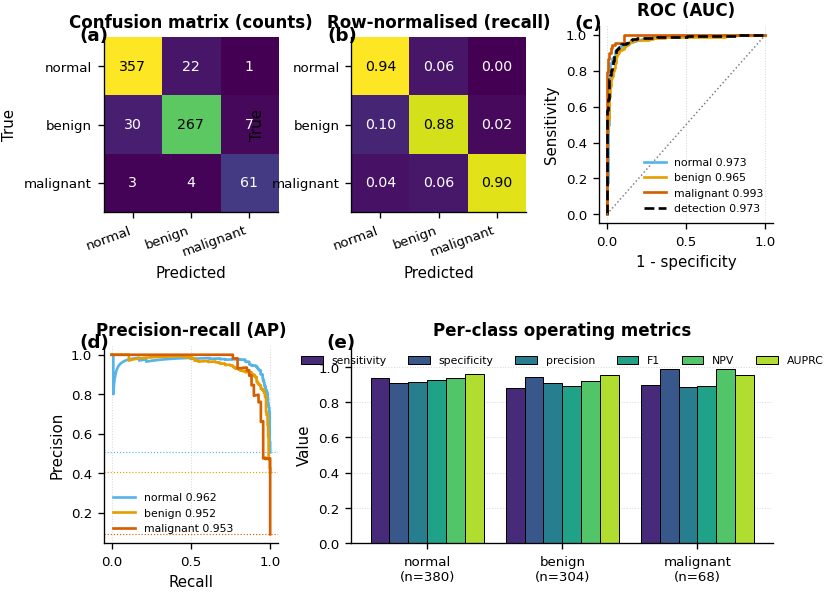

,class,sensitivity,specificity,precision,F1,NPV,AUPRC,support
0,normal,0.9395,0.9113,0.9154,0.9273,0.9365,0.9625,380
1,benign,0.8783,0.9420,0.9113,0.8945,0.9194,0.9515,304
2,malignant,0.8971,0.9883,0.8841,0.8905,0.9898,0.9531,68


In [18]:
# ============================================================
# Cell 16 - Figure 4: discrimination performance (composite main figure)
# ============================================================
pred_final = FINAL_PROBS.argmax(axis=1)
conf_final = FINAL_PROBS.max(axis=1)
corr_final = (pred_final == test_y).astype(float)
CM_FINAL = confusion_matrix(test_y, pred_final, labels=[0, 1, 2])
y_bin = label_binarize(test_y, classes=[0, 1, 2])

cm_df = pd.DataFrame(CM_FINAL, index=[f'true_{c}' for c in CLASS_NAMES],
                     columns=[f'pred_{c}' for c in CLASS_NAMES])
cm_df.to_csv(TABLE_DIR / 'table_confusion_matrix.csv')
print('Confusion matrix (rows = truth):')
display(cm_df)
n_errors = int(CM_FINAL.sum() - np.trace(CM_FINAL))
print(f'Errors: {n_errors} of {len(test_y)} | '
      f'{TARGET_ACCURACY:.0%} allows at most '
      f'{int(np.floor((1-TARGET_ACCURACY)*len(test_y)))}')


def draw_confusion(ax, cm, normalize=False, title=''):
    mat = cm.astype(float)
    if normalize:
        mat = mat / np.maximum(mat.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(mat, cmap=SEQ_CMAP, vmin=0, vmax=mat.max() if mat.max() > 0 else 1)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    ax.grid(False)
    thresh = mat.max() * 0.55 if mat.max() > 0 else 0.5
    for i in range(3):
        for j in range(3):
            lbl = f'{mat[i, j]:.2f}' if normalize else f'{int(cm[i, j])}'
            ax.text(j, i, lbl, ha='center', va='center', fontsize=8.5,
                    color='white' if mat[i, j] < thresh else 'black')
    return im


fig = plt.figure(figsize=(COL2, 5.6))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.62, wspace=0.42)

ax = fig.add_subplot(gs[0, 0])
draw_confusion(ax, CM_FINAL, False, 'Confusion matrix (counts)')
panel(ax, 'a')

ax = fig.add_subplot(gs[0, 1])
draw_confusion(ax, CM_FINAL, True, 'Row-normalised (recall)')
panel(ax, 'b')

ax = fig.add_subplot(gs[0, 2])
for i, c in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(y_bin[:, i], FINAL_PROBS[:, i])
        ax.plot(fpr, tpr, color=CLASS_COLORS[c],
                label=f'{c} {roc_auc_score(y_bin[:, i], FINAL_PROBS[:, i]):.3f}')
    except Exception:
        pass
yb_det = (test_y > 0).astype(int); p_det = FINAL_PROBS[:, 1] + FINAL_PROBS[:, 2]
try:
    fpr, tpr, _ = roc_curve(yb_det, p_det)
    ax.plot(fpr, tpr, color=OKABE['black'], ls='--',
            label=f'detection {roc_auc_score(yb_det, p_det):.3f}')
except Exception:
    pass
ax.plot([0, 1], [0, 1], ls=':', lw=0.9, color=OKABE['grey'])
ax.set_xlabel('1 - specificity'); ax.set_ylabel('Sensitivity')
ax.set_title('ROC (AUC)'); ax.legend(fontsize=6.5, loc='lower right')
bare(ax, 'both'); panel(ax, 'c')

ax = fig.add_subplot(gs[1, 0])
for i, c in enumerate(CLASS_NAMES):
    try:
        pr, rc, _ = precision_recall_curve(y_bin[:, i], FINAL_PROBS[:, i])
        ax.plot(rc, pr, color=CLASS_COLORS[c],
                label=f'{c} {average_precision_score(y_bin[:, i], FINAL_PROBS[:, i]):.3f}')
        ax.axhline(y_bin[:, i].mean(), color=CLASS_COLORS[c], ls=':', lw=0.7)
    except Exception:
        pass
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-recall (AP)'); ax.legend(fontsize=6.5, loc='lower left')
bare(ax, 'both'); panel(ax, 'd')

ax = fig.add_subplot(gs[1, 1:])
per_df = pd.DataFrame([{'class': c,
                        'sensitivity': final_m[f'{c}_sensitivity'],
                        'specificity': final_m[f'{c}_specificity'],
                        'precision': final_m[f'{c}_precision'],
                        'F1': final_m[f'{c}_f1'],
                        'NPV': final_m[f'{c}_npv'],
                        'AUPRC': final_m.get(f'{c}_auprc', np.nan),
                        'support': int(final_m[f'{c}_support'])} for c in CLASS_NAMES])
per_df.to_csv(TABLE_DIR / 'table06_per_class_metrics.csv', index=False)
mnames = ['sensitivity', 'specificity', 'precision', 'F1', 'NPV', 'AUPRC']
x = np.arange(len(CLASS_NAMES)); w = 0.14
grad = plt.get_cmap(SEQ_CMAP)(np.linspace(0.12, 0.88, len(mnames)))
for j, (mn, col) in enumerate(zip(mnames, grad)):
    ax.bar(x + (j - (len(mnames) - 1) / 2) * w, per_df[mn], w, label=mn,
           color=col, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(n={int(per_df["support"][i])})'
                    for i, c in enumerate(CLASS_NAMES)])
ax.set_ylim(0, 1.12); ax.set_ylabel('Value'); ax.set_title('Per-class operating metrics')
ax.legend(ncol=6, fontsize=6.5, loc='upper center')
bare(ax); panel(ax, 'e', dx=-0.06)

savefig('fig04_discrimination',
        'Discrimination performance of the selected model on the frozen test '
        'split. (a) Confusion matrix in counts and (b) normalised by true class, '
        'so the diagonal reads as per-class recall. (c) One-vs-rest receiver '
        'operating characteristic curves with areas under the curve; the dashed '
        'black curve is the binary tumour-detection endpoint. (d) One-vs-rest '
        'precision-recall curves with average precision; dotted horizontals mark '
        'each class prevalence, the no-skill baseline. (e) Per-class sensitivity, '
        'specificity, precision, F1, negative predictive value and average '
        'precision, with test support in the axis labels.', main=True)
display(per_df.round(4))


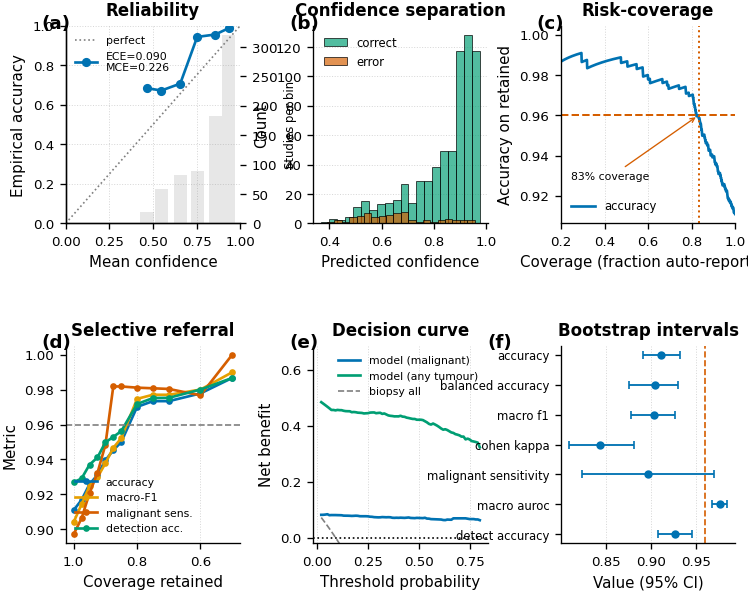

PosixPath('/kaggle/working/BTXRD_P3_4_5_V7/figures/main/fig05_calibration_and_utility.png')

In [19]:
# ============================================================
# Cell 17 - Figure 5: calibration, reliability and clinical utility
# ============================================================
fig = plt.figure(figsize=(COL2, 5.6))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.62, wspace=0.42)

# (a) reliability diagram with bin occupancy
ax = fig.add_subplot(gs[0, 0])
bins = np.linspace(0, 1, 11)
xs, ys, ns = [], [], []
for i in range(len(bins) - 1):
    hi_incl = i == len(bins) - 2
    mask = (conf_final >= bins[i]) & (conf_final <= bins[i + 1] if hi_incl
                                      else conf_final < bins[i + 1])
    if mask.sum() >= 3:
        xs.append(conf_final[mask].mean()); ys.append(corr_final[mask].mean())
        ns.append(int(mask.sum()))
ax.plot([0, 1], [0, 1], ls=':', lw=1.0, color=OKABE['grey'], label='perfect')
ax.plot(xs, ys, marker='o', color=OKABE['blue'],
        label=f"ECE={final_m['ece']:.3f}\nMCE={final_m['mce']:.3f}")
ax2 = ax.twinx()
ax2.bar(xs, ns, width=0.075, alpha=0.18, color=OKABE['grey'])
ax2.set_ylabel('Studies per bin', fontsize=7); ax2.grid(False)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('Mean confidence'); ax.set_ylabel('Empirical accuracy')
ax.set_title('Reliability'); ax.legend(fontsize=6.5, loc='upper left')
panel(ax, 'a')

# (b) confidence separation
ax = fig.add_subplot(gs[0, 1])
ax.hist(conf_final[corr_final == 1], bins=20, alpha=0.68, label='correct',
        color=OKABE['green'], edgecolor='black')
ax.hist(conf_final[corr_final == 0], bins=20, alpha=0.68, label='error',
        color=OKABE['red'], edgecolor='black')
ax.set_xlabel('Predicted confidence'); ax.set_ylabel('Count')
ax.set_title('Confidence separation'); ax.legend(fontsize=7)
bare(ax); panel(ax, 'b')

# (c) risk-coverage
ax = fig.add_subplot(gs[0, 2])
covs = np.arange(1, len(test_y) + 1) / len(test_y)
ax.plot(covs, run_acc, color=OKABE['blue'], label='accuracy')
ax.axhline(TARGET_ACCURACY, ls='--', lw=1.2, color=OKABE['red'])
if COVERAGE_AT_TARGET:
    ax.axvline(COVERAGE_AT_TARGET['coverage'], ls=':', lw=1.2, color=OKABE['red'])
    ax.annotate(f"{COVERAGE_AT_TARGET['coverage']:.0%} coverage",
                xy=(COVERAGE_AT_TARGET['coverage'], TARGET_ACCURACY),
                xytext=(0.06, 0.22), textcoords='axes fraction', fontsize=6.5,
                arrowprops=dict(arrowstyle='->', lw=0.8, color=OKABE['red']))
ax.set_xlim(0.2, 1.0)
ax.set_xlabel('Coverage (fraction auto-reported)'); ax.set_ylabel('Accuracy on retained')
ax.set_title('Risk-coverage'); ax.legend(fontsize=7, loc='lower left')
bare(ax, 'both'); panel(ax, 'c')

# (d) referral trade-off
ax = fig.add_subplot(gs[1, 0])
for col, c, lab in [('accuracy', OKABE['blue'], 'accuracy'),
                    ('macro_f1', OKABE['orange'], 'macro-F1'),
                    ('malignant_sensitivity', OKABE['red'], 'malignant sens.'),
                    ('detect_accuracy', OKABE['green'], 'detection acc.')]:
    ax.plot(selective_df['coverage'], selective_df[col], marker='o', ms=3,
            color=c, label=lab)
ax.axhline(TARGET_ACCURACY, ls='--', lw=1.0, color=OKABE['grey'])
ax.invert_xaxis()
ax.set_xlabel('Coverage retained'); ax.set_ylabel('Metric')
ax.set_title('Selective referral'); ax.legend(fontsize=6.5, loc='lower left')
bare(ax, 'both'); panel(ax, 'd')

# (e) decision curve
ax = fig.add_subplot(gs[1, 1])
ax.plot(dca_df['threshold_probability'], dca_df['net_benefit_model'],
        color=OKABE['blue'], label='model (malignant)')
ax.plot(dca_det_df['threshold_probability'], dca_det_df['net_benefit_model'],
        color=OKABE['green'], label='model (any tumour)')
ax.plot(dca_df['threshold_probability'], dca_df['net_benefit_treat_all'],
        ls='--', lw=1.0, color=OKABE['grey'], label='biopsy all')
ax.axhline(0, ls=':', lw=1.0, color='black')
ax.set_ylim(bottom=min(-0.02, float(dca_df['net_benefit_model'].min())))
ax.set_xlabel('Threshold probability'); ax.set_ylabel('Net benefit')
ax.set_title('Decision curve'); ax.legend(fontsize=6.5)
bare(ax, 'both'); panel(ax, 'e')

# (f) bootstrap forest for the headline metrics
ax = fig.add_subplot(gs[1, 2])
show = ['accuracy', 'balanced_accuracy', 'macro_f1', 'cohen_kappa',
        'malignant_sensitivity', 'macro_auroc', 'detect_accuracy']
sub = ci_df[ci_df['metric'].isin(show)].set_index('metric').reindex(show).reset_index()
ypos = np.arange(len(sub))[::-1]
ax.errorbar(sub['estimate'], ypos,
            xerr=[np.maximum(sub['estimate'] - sub['ci_low'], 0),
                  np.maximum(sub['ci_high'] - sub['estimate'], 0)],
            fmt='o', ms=4, capsize=2.5, lw=1.1, color=OKABE['blue'])
ax.axvline(TARGET_ACCURACY, ls='--', lw=1.0, color=OKABE['red'])
ax.set_yticks(ypos); ax.set_yticklabels([s.replace('_', ' ') for s in sub['metric']],
                                        fontsize=7)
ax.set_xlabel('Value (95% CI)'); ax.set_title('Bootstrap intervals')
bare(ax, 'x'); panel(ax, 'f', dx=-0.42)

savefig('fig05_calibration_and_utility',
        'Calibration and clinical utility. (a) Reliability diagram with per-bin '
        'occupancy on the right axis; expected and maximum calibration error are '
        'annotated. (b) Confidence distributions for correct and incorrect '
        'predictions; separation is what makes selective referral work. '
        '(c) Risk-coverage curve: accuracy on the retained fraction as the least '
        'confident studies are referred, with the accuracy target and the '
        'coverage at which it is met. (d) Referral trade-off across four metrics. '
        '(e) Decision-curve analysis against a biopsy-all strategy for the '
        'malignant and any-tumour endpoints. (f) Stratified bootstrap 95% '
        'confidence intervals for the headline metrics.', main=True)


XAI maps from arm b3_trust, cached at 256px (shape (752, 1, 256, 256))

XAI summary (v5 reported pointing accuracy 0.046 and attention IoU 0.021, because its backbone was randomly initialised):


,value
energy_inside_mask,0.2253
pointing_accuracy,0.3902
attention_iou,0.1411
attention_dice,0.2145
mask_head_iou,0.3032
n,369.0000
random_baseline_energy,0.0218


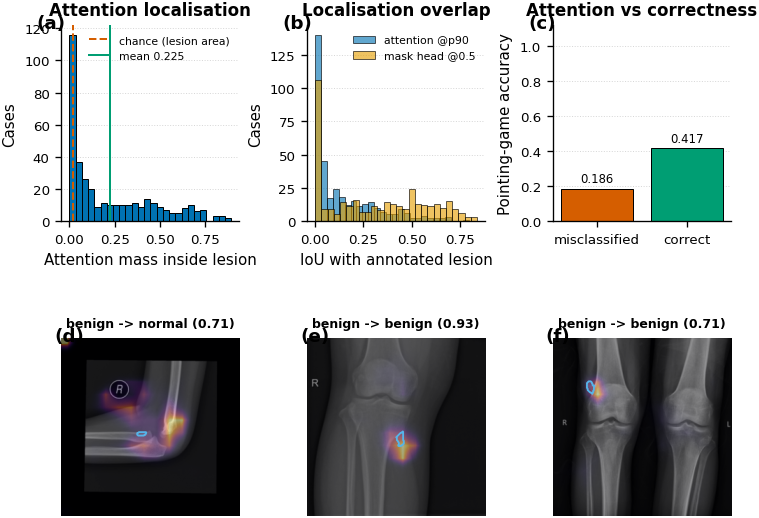

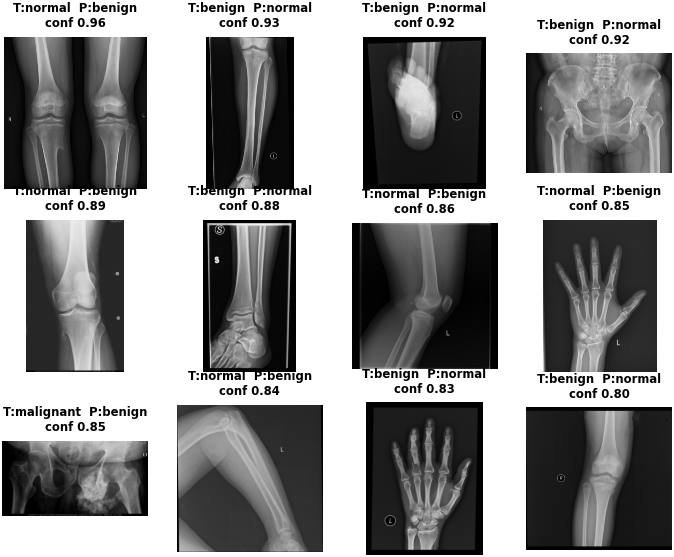

In [20]:
# ============================================================
# Cell 18 - Figure 6: lesion attention audit, and the error gallery
# ============================================================
# predict_probs uses shuffle=False everywhere, so TEST_DF row order equals
# prediction order.  Asserted rather than assumed.
test_df_pred = TEST_DF.reset_index(drop=True).copy()
assert len(test_df_pred) == len(test_y) == len(FINAL_PROBS), 'test row-order mismatch'
test_df_pred['true_id'] = test_y
test_df_pred['true_label'] = [ID_TO_CLASS[int(i)] for i in test_y]
test_df_pred['pred_id'] = pred_final
test_df_pred['pred_label'] = [ID_TO_CLASS[int(i)] for i in pred_final]
test_df_pred['confidence'] = conf_final
test_df_pred['correct'] = corr_final.astype(bool)
for i, c in enumerate(CLASS_NAMES):
    test_df_pred[f'prob_{c}'] = FINAL_PROBS[:, i]
if 'has_mask' not in test_df_pred.columns:
    test_df_pred['has_mask'] = False
test_df_pred['has_mask'] = test_df_pred['has_mask'].fillna(False).astype(bool)
test_df_pred.to_csv(TABLE_DIR / 'table07_test_predictions.csv', index=False)

ATT = MASKP = None
ATT_ARM = None
for k, maps in TEST_MAPS.items():
    ATT = np.asarray(maps['attn'], dtype=np.float32)
    MASKP = np.asarray(maps['mask_pred'], dtype=np.float32)
    ATT_ARM = k
    break
if ATT is not None:
    print(f'XAI maps from arm {ATT_ARM}, cached at {ATT.shape[-1]}px '
          f'(shape {ATT.shape})')


def load_mask_np(path, size):
    """GT mask resized to the CACHED map resolution, not the model input size."""
    try:
        if isinstance(path, str) and Path(path).exists():
            m = Image.open(path).convert('L')
            m = TF.resize(m, [size, size], interpolation=TF.InterpolationMode.NEAREST)
            return (np.array(m).astype(np.float32) / 255.0 > 0.5).astype(np.float32)
    except Exception:
        pass
    return np.zeros((size, size), dtype=np.float32)


xai_rows = []
if ATT is not None and len(ATT) == len(test_df_pred):
    msz = ATT.shape[-1]
    for i, row in test_df_pred.iterrows():
        if row['true_id'] == 0 or not bool(row['has_mask']):
            continue
        gt = load_mask_np(row.get('mask_path'), msz)
        if gt.sum() < 5:
            continue
        a = ATT[i, 0]
        if a.shape != gt.shape:
            continue
        a_norm = a / (a.sum() + 1e-9)
        peak = np.unravel_index(int(np.argmax(a)), a.shape)
        thr = float(np.quantile(a, 0.90))
        pb = (a >= thr).astype(np.float32)
        inter = float((pb * gt).sum()); union = float(((pb + gt) > 0).sum())
        mp_iou = np.nan
        if MASKP is not None:
            mb = (MASKP[i, 0] >= 0.5).astype(np.float32)
            mp_iou = float((mb * gt).sum() / (((mb + gt) > 0).sum() + 1e-9))
        xai_rows.append({'row_index': int(i), 'true_label': row['true_label'],
                         'correct': bool(row['correct']),
                         'energy_inside_mask': float((a_norm * gt).sum()),
                         'pointing_accuracy': float(gt[peak] > 0.5),
                         'attention_iou': inter / (union + 1e-9),
                         'attention_dice': 2 * inter / (pb.sum() + gt.sum() + 1e-9),
                         'mask_head_iou': mp_iou,
                         'lesion_area_fraction': float(gt.mean())})
xai_df = pd.DataFrame(xai_rows)
xai_df.to_csv(TABLE_DIR / 'table08_xai_attention_mask_audit.csv', index=False)

if len(xai_df):
    XAI_SUMMARY = {k: float(xai_df[k].mean(skipna=True)) for k in
                   ['energy_inside_mask', 'pointing_accuracy', 'attention_iou',
                    'attention_dice', 'mask_head_iou']}
    XAI_SUMMARY['n'] = int(len(xai_df))
    XAI_SUMMARY['random_baseline_energy'] = float(xai_df['lesion_area_fraction'].mean())
    json.dump(XAI_SUMMARY, open(TABLE_DIR / 'p5_xai_summary.json', 'w'), indent=2)
    print('\nXAI summary (v5 reported pointing accuracy 0.046 and attention IoU '
          '0.021, because its backbone was randomly initialised):')
    display(pd.Series(XAI_SUMMARY).round(4).to_frame('value'))

    fig = plt.figure(figsize=(COL2, 5.4))
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.38)

    ax = fig.add_subplot(gs[0, 0])
    ax.hist(xai_df['energy_inside_mask'].dropna(), bins=26,
            color=OKABE['blue'], edgecolor='black')
    ax.axvline(XAI_SUMMARY['random_baseline_energy'], ls='--', lw=1.2,
               color=OKABE['red'], label='chance (lesion area)')
    ax.axvline(XAI_SUMMARY['energy_inside_mask'], ls='-', lw=1.2,
               color=OKABE['green'], label=f"mean {XAI_SUMMARY['energy_inside_mask']:.3f}")
    ax.set_xlabel('Attention mass inside lesion'); ax.set_ylabel('Cases')
    ax.set_title('Attention localisation'); ax.legend(fontsize=6.5)
    bare(ax); panel(ax, 'a')

    ax = fig.add_subplot(gs[0, 1])
    for col, c, lab in [('attention_iou', OKABE['blue'], 'attention @p90'),
                        ('mask_head_iou', OKABE['orange'], 'mask head @0.5')]:
        v = xai_df[col].dropna()
        if len(v):
            ax.hist(v, bins=26, alpha=0.62, color=c, edgecolor='black', label=lab)
    ax.set_xlabel('IoU with annotated lesion'); ax.set_ylabel('Cases')
    ax.set_title('Localisation overlap'); ax.legend(fontsize=6.5)
    bare(ax); panel(ax, 'b')

    ax = fig.add_subplot(gs[0, 2])
    grp = xai_df.groupby('correct')['pointing_accuracy'].agg(['mean', 'count'])
    labs = ['misclassified', 'correct']
    vals = [float(grp['mean'].get(False, np.nan)), float(grp['mean'].get(True, np.nan))]
    ax.bar(labs, vals, color=[OKABE['red'], OKABE['green']], edgecolor='black')
    annotate_bars(ax, vals, fmt='{:.3f}', dy=0.02)
    ax.set_ylim(0, 1.12); ax.set_ylabel('Pointing-game accuracy')
    ax.set_title('Attention vs correctness'); bare(ax); panel(ax, 'c')

    show = test_df_pred[(test_df_pred['true_id'] > 0) & test_df_pred['has_mask']].head(3)
    for pi, (i, row) in enumerate(show.iterrows()):
        ax = fig.add_subplot(gs[1, pi])
        try:
            im = Image.open(row['image_path']).convert('L')
            im = TF.resize(im, [ATT.shape[-1], ATT.shape[-1]])
            ax.imshow(np.array(im), cmap='gray')
            ax.imshow(ATT[i, 0], cmap=HEAT_CMAP, alpha=0.42)
            gt = load_mask_np(row.get('mask_path'), ATT.shape[-1])
            if gt.sum() > 0:
                ax.contour(gt, levels=[0.5], colors=[OKABE['sky']], linewidths=1.1)
            ax.set_title(f"{row['true_label']} -> {row['pred_label']} "
                         f"({row['confidence']:.2f})", fontsize=7.5)
        except Exception:
            ax.text(0.5, 0.5, 'image unavailable', ha='center')
        ax.axis('off'); ax.grid(False)
        panel(ax, 'def'[pi], dx=-0.04)

    savefig('fig06_xai_attention',
            'Explainability audit of the lesion-attention branch against '
            'radiologist annotations. (a) Fraction of the attention mass falling '
            'inside the annotated lesion; the dashed line is the chance level '
            'given mean lesion area. (b) Intersection over union between the '
            'annotated lesion and, respectively, the top-decile attention region '
            'and the thresholded mask-decoder output. (c) Pointing-game accuracy '
            'split by whether the case was classified correctly. (d-f) Example '
            'overlays: attention heat map over the radiograph with the annotated '
            'lesion outlined.', main=True)
else:
    print('No lesion-aware arm produced maps, or no masks were available - '
          'XAI audit skipped.')

# ---- Supplementary: high-confidence error gallery ---------------------------
err = (test_df_pred[~test_df_pred['correct']]
       .sort_values('confidence', ascending=False).head(12))
if len(err):
    fig, axes = plt.subplots(3, 4, figsize=(COL2, 5.6)); axes = axes.ravel()
    for ax, (_, row) in zip(axes, err.iterrows()):
        try:
            ax.imshow(Image.open(row['image_path']).convert('L'), cmap='gray')
            ax.set_title(f"T:{row['true_label']}  P:{row['pred_label']}\n"
                         f"conf {row['confidence']:.2f}", fontsize=7)
        except Exception:
            ax.text(0.5, 0.5, 'image error', ha='center')
        ax.axis('off'); ax.grid(False)
    for ax in axes[len(err):]:
        ax.axis('off'); ax.grid(False)
    savefig('figS01_error_gallery',
            'The twelve most confident misclassifications on the test split. '
            'Confident errors on cases labelled normal are candidates for '
            'unannotated tumours rather than model failures.')
    err.to_csv(TABLE_DIR / 'table_high_confidence_errors.csv', index=False)


,stage,accuracy,macro_f1,source
0,v5 (random init),0.5918,0.5440,previous run
1,"Portion-2 B3 (ImageNet, single model)",0.8596,0.8667,previous run
2,"v6 ensemble (14 ep, under-trained)",0.8298,0.8070,previous run
3,"v7 control: plain B3, 60 ep",0.8830,0.8774,this run (control)
4,v7 best single member (b3_trust),0.9096,0.8921,this run
5,v7 weighted ensemble,0.9109,0.9029,this run
6,v7 selected (weighted_ensemble +bias),0.9109,0.9041,this run
7,v7 selected @ 83% coverage,0.9600,NaN,this run (selective)


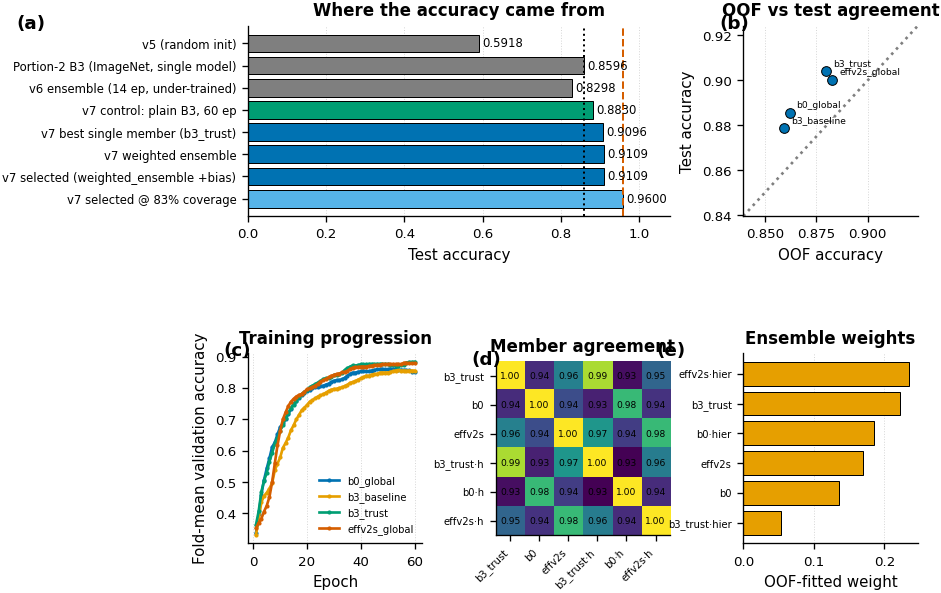

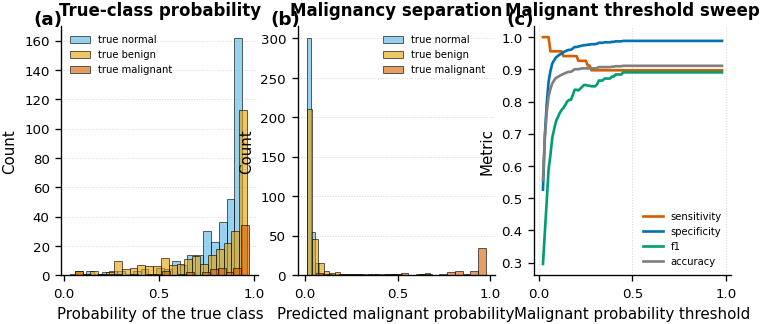

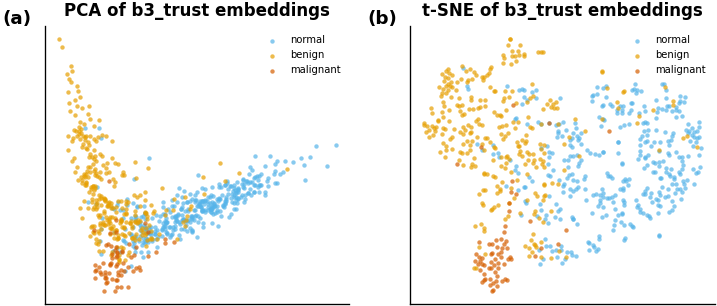

Figures so far: 7 main / 5 supplementary


In [21]:
# ============================================================
# Cell 19 - Figure 7: ablation and progression, plus supplementary visuals
# ============================================================
# ---- Ablation ladder: what each stage actually bought ------------------------
ladder = []
b3ref = P2_REFERENCE[P2_REFERENCE['model'].str.contains('B3 \\(Portion 2\\)')].iloc[0]
v5ref = P2_REFERENCE[P2_REFERENCE['model'].str.contains('v5')].iloc[0]
v6ref = P2_REFERENCE[P2_REFERENCE['model'].str.contains('v6')].iloc[0]
ladder.append({'stage': 'v5 (random init)', 'accuracy': float(v5ref['accuracy']),
               'macro_f1': float(v5ref['macro_f1']), 'source': 'previous run'})
ladder.append({'stage': 'Portion-2 B3 (ImageNet, single model)',
               'accuracy': float(b3ref['accuracy']),
               'macro_f1': float(b3ref['macro_f1']), 'source': 'previous run'})
ladder.append({'stage': 'v6 ensemble (14 ep, under-trained)',
               'accuracy': float(v6ref['accuracy']),
               'macro_f1': float(v6ref['macro_f1']), 'source': 'previous run'})
if BASELINE_PROBS is not None:
    _bm = all_metrics(test_y, BASELINE_PROBS)
    ladder.append({'stage': f'v7 control: plain B3, {EPOCH_PLAN.get(BASELINE_ARM, 0)} ep',
                   'accuracy': _bm['accuracy'], 'macro_f1': _bm['macro_f1'],
                   'source': 'this run (control)'})
best_member = max(MEMBERS, key=lambda a: all_metrics(test_y, cal_test[a])['accuracy'])
bm_m = all_metrics(test_y, cal_test[best_member])
ladder.append({'stage': f'v7 best single member ({best_member})',
               'accuracy': bm_m['accuracy'], 'macro_f1': bm_m['macro_f1'],
               'source': 'this run'})
em = all_metrics(test_y, PRIMARY_PROBS)
ladder.append({'stage': 'v7 weighted ensemble', 'accuracy': em['accuracy'],
               'macro_f1': em['macro_f1'], 'source': 'this run'})
ladder.append({'stage': f'v7 selected ({SELECTED})', 'accuracy': final_m['accuracy'],
               'macro_f1': final_m['macro_f1'], 'source': 'this run'})
if COVERAGE_AT_TARGET:
    _rep = COVERAGE_AT_TARGET.get('is_reportable', True)
    ladder.append({'stage': f"v7 selected @ {COVERAGE_AT_TARGET['coverage']:.0%} coverage"
                            + ('' if _rep else ' [NOT REPORTABLE]'),
                   'accuracy': COVERAGE_AT_TARGET['accuracy'], 'macro_f1': np.nan,
                   'source': 'this run (selective)' if _rep
                             else 'this run (selective, not reportable)'})
ladder_df = pd.DataFrame(ladder)
ladder_df.to_csv(TABLE_DIR / 'table_ablation_ladder.csv', index=False)
display(ladder_df.round(4))

fig = plt.figure(figsize=(COL2, 5.6))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.72, wspace=0.42)

ax = fig.add_subplot(gs[0, :2])
cols = [OKABE['grey'] if s == 'previous run' else
        (OKABE['sky'] if 'selective' in s else
         (OKABE['green'] if 'control' in s else OKABE['blue']))
        for s in ladder_df['source']]
ax.barh(np.arange(len(ladder_df))[::-1], ladder_df['accuracy'], color=cols,
        edgecolor='black')
for yi, v in zip(np.arange(len(ladder_df))[::-1], ladder_df['accuracy']):
    ax.text(v + 0.008, yi, f'{v:.4f}', va='center', fontsize=7)
ax.axvline(TARGET_ACCURACY, ls='--', lw=1.2, color=OKABE['red'])
ax.axvline(float(P2_REFERENCE['accuracy'].max()), ls=':', lw=1.2, color='black')
ax.set_yticks(np.arange(len(ladder_df))[::-1])
ax.set_yticklabels(ladder_df['stage'], fontsize=7)
ax.set_xlim(0, 1.08); ax.set_xlabel('Test accuracy')
ax.set_title('Where the accuracy came from')
bare(ax, 'x'); panel(ax, 'a', dx=-0.55)

# (b) per-arm OOF vs test - checks the OOF estimate is not optimistic
ax = fig.add_subplot(gs[0, 2])
if len(status_df):
    xs = status_df['oof_accuracy'].values
    ys = [all_metrics(test_y, TEST_P[a])['accuracy'] if a in TEST_P else np.nan
          for a in status_df['arm']]
    ax.scatter(xs, ys, s=34, color=OKABE['blue'], edgecolor='black', zorder=3)
    lo = float(np.nanmin(list(xs) + list(ys))) - 0.02
    hi = float(np.nanmax(list(xs) + list(ys))) + 0.02
    ax.plot([lo, hi], [lo, hi], ls=':', color=OKABE['grey'])
    for xv, yv, nm in zip(xs, ys, status_df['arm']):
        if np.isfinite(yv):
            ax.annotate(nm, (xv, yv), fontsize=5.5, textcoords='offset points',
                        xytext=(4, 3))
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel('OOF accuracy'); ax.set_ylabel('Test accuracy')
ax.set_title('OOF vs test agreement'); bare(ax, 'both'); panel(ax, 'b')

# (c) validation curves
ax = fig.add_subplot(gs[1, 0])
if len(hist_df):
    for ai, (arm, g) in enumerate(hist_df.groupby('arm')):
        mean_c = g.groupby('epoch')['accuracy'].mean()
        ax.plot(mean_c.index, mean_c.values, marker='.', ms=3,
                color=list(OKABE.values())[ai % len(OKABE)], label=arm)
    ax.legend(fontsize=6)
ax.set_xlabel('Epoch'); ax.set_ylabel('Fold-mean validation accuracy')
ax.set_title('Training progression'); bare(ax, 'both'); panel(ax, 'c')

# (d) inter-member agreement
ax = fig.add_subplot(gs[1, 1])
if len(MEMBERS) > 1:
    P = {a: cal_test[a].argmax(1) for a in MEMBERS}
    A = np.array([[float((P[a] == P[b]).mean()) for b in MEMBERS] for a in MEMBERS])
    im = ax.imshow(A, cmap=SEQ_CMAP, vmin=max(0.4, A.min()), vmax=1.0)
    ax.set_xticks(range(len(MEMBERS))); ax.set_yticks(range(len(MEMBERS)))
    short = [m.replace('_global', '').replace('#hier', '·h') for m in MEMBERS]
    ax.set_xticklabels(short, rotation=45, ha='right', fontsize=6)
    ax.set_yticklabels(short, fontsize=6)
    for i in range(len(MEMBERS)):
        for j in range(len(MEMBERS)):
            ax.text(j, i, f'{A[i, j]:.2f}', ha='center', va='center', fontsize=5.5,
                    color='white' if A[i, j] < 0.85 else 'black')
    pd.DataFrame(A, index=MEMBERS, columns=MEMBERS)\
        .to_csv(TABLE_DIR / 'table10_member_agreement.csv')
ax.grid(False); ax.set_title('Member agreement'); panel(ax, 'd')

# (e) ensemble weights
ax = fig.add_subplot(gs[1, 2])
wser = pd.Series(best_w, index=MEMBERS).sort_values(ascending=True)
wser = wser[wser > 1e-3]
ax.barh(np.arange(len(wser)), wser.values, color=OKABE['orange'], edgecolor='black')
ax.set_yticks(np.arange(len(wser)))
ax.set_yticklabels([s.replace('_global', '').replace('#hier', '·hier')
                    for s in wser.index], fontsize=6)
ax.set_xlabel('OOF-fitted weight'); ax.set_title('Ensemble weights')
bare(ax, 'x'); panel(ax, 'e', dx=-0.5)

savefig('fig07_ablation_and_ensemble',
        'Provenance of the final result. (a) Accuracy ladder from the v5 '
        'randomly-initialised run through the Portion-2 single model to the v6 '
        'members, ensemble and selected configuration; grey bars are previously '
        'published runs. (b) Out-of-fold against test accuracy for each arm; '
        'points on the identity line indicate the out-of-fold estimate used for '
        'model selection is unbiased. (c) Fold-averaged validation accuracy per '
        'epoch for each arm. (d) Pairwise prediction agreement between ensemble '
        'members; lower agreement is what makes the ensemble gain. (e) Ensemble '
        'weights fitted on out-of-fold predictions.', main=True)

# ---- Supplementary figures ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(COL2, 2.7))
ax = axes[0]
for i, c in enumerate(CLASS_NAMES):
    v = FINAL_PROBS[test_y == i, i]
    if len(v):
        ax.hist(v, bins=22, alpha=0.6, label=f'true {c}', color=CLASS_COLORS[c],
                edgecolor='black')
ax.set_xlabel('Probability of the true class'); ax.set_ylabel('Count')
ax.set_title('True-class probability'); ax.legend(fontsize=6); bare(ax); panel(ax, 'a')

ax = axes[1]
for i, c in enumerate(CLASS_NAMES):
    v = FINAL_PROBS[test_y == i, 2]
    if len(v):
        ax.hist(v, bins=22, alpha=0.6, label=f'true {c}', color=CLASS_COLORS[c],
                edgecolor='black')
ax.set_xlabel('Predicted malignant probability'); ax.set_ylabel('Count')
ax.set_title('Malignancy separation'); ax.legend(fontsize=6); bare(ax); panel(ax, 'b')

ax = axes[2]
for col, c in [('malignant_sensitivity', OKABE['red']),
               ('malignant_specificity', OKABE['blue']),
               ('malignant_f1', OKABE['green']), ('accuracy', OKABE['grey'])]:
    ax.plot(thr_df['threshold'], thr_df[col], color=c, label=col.replace('malignant_', ''))
ax.set_xlabel('Malignant probability threshold'); ax.set_ylabel('Metric')
ax.set_title('Malignant threshold sweep'); ax.legend(fontsize=6)
bare(ax, 'both'); panel(ax, 'c')
savefig('figS02_probability_and_threshold',
        'Probability behaviour of the selected model. (a) Probability assigned to '
        'the true class, by class. (b) Predicted malignant probability grouped by '
        'true class. (c) Metrics as the malignant decision threshold is swept.')

# Feature space
try:
    lesion_members = [a for a in ARM_LIST
                      if ARM_SPECS.get(a.replace('_clean', ''), {}).get('use_lesion')]
    feat_arm = lesion_members[0] if lesion_members else ARM_LIST[0]
    ck = sorted(MODEL_DIR.glob(f'{feat_arm}_fold0.pt'))
    if ck:
        blob = safe_torch_load(ck[0], map_location='cpu')
        _m = build_arm(feat_arm, META_ENCODER['dim']).to(device)
        _m.load_state_dict(blob['state_dict'], strict=True)
        Fh = predict_probs(_m, TEST_DF, image_size=blob.get('image_size',
                           ARM_SPECS[feat_arm.replace('_clean', '')]['image_size']),
                           tta=False)['features']
        del _m, blob
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        Fp = PCA(n_components=min(50, Fh.shape[1], Fh.shape[0] - 1)).fit_transform(Fh)
        emb2 = TSNE(n_components=2, init='pca',
                    perplexity=min(30, max(5, len(Fp) // 12)),
                    random_state=CFG['seed']).fit_transform(Fp)
        fig, axes = plt.subplots(1, 2, figsize=(COL2, 3.0))
        for ax, emb, t, lt in [(axes[0], Fp[:, :2], 'PCA', 'ab'[0]),
                               (axes[1], emb2, 't-SNE', 'ab'[1])]:
            for i, c in enumerate(CLASS_NAMES):
                s = test_y == i
                ax.scatter(emb[s, 0], emb[s, 1], s=7, alpha=0.7,
                           color=CLASS_COLORS[c], label=c, linewidths=0)
            ax.set_title(f'{t} of {feat_arm} embeddings'); ax.legend(fontsize=6)
            ax.set_xticks([]); ax.set_yticks([]); ax.grid(False); panel(ax, lt)
        savefig('figS03_feature_space',
                f'Test-set embeddings from the {feat_arm} arm, projected by '
                f'(a) PCA and (b) t-SNE, coloured by true class.')
except Exception as e:
    print('Feature-space figure skipped:', str(e)[:200])

print('Figures so far:', len(list(FIG_MAIN.glob("*.png"))), 'main /',
      len(list(FIG_SUPP.glob("*.png"))), 'supplementary')


In [22]:
# ============================================================
# Cell 20 - Report, figure captions, manifest, ZIP export
# ============================================================
caption_df = write_captions()
fig_manifest = pd.DataFrame([{'figure': p.stem,
                              'section': 'main' if p.parent == FIG_MAIN else 'supplementary',
                              'path': str(p), 'size_kb': round(p.stat().st_size / 1024, 1)}
                             for p in sorted(list(FIG_MAIN.glob('*')) +
                                             list(FIG_SUPP.glob('*')))])
fig_manifest.to_csv(TABLE_DIR / 'table11_figure_manifest.csv', index=False)

HEADLINE = ['accuracy', 'balanced_accuracy', 'macro_f1', 'weighted_f1', 'cohen_kappa',
            'quadratic_kappa', 'mcc', 'top2_accuracy', 'macro_auroc', 'macro_auprc',
            'malignant_sensitivity', 'malignant_specificity', 'malignant_precision',
            'malignant_auprc', 'detect_accuracy', 'detect_auroc', 'detect_sensitivity',
            'detect_specificity', 'grade_accuracy', 'grade_auroc',
            'ece', 'mce', 'nll', 'brier_score']
_ci_map = ci_df.set_index('metric')
metric_lines = []
for k in HEADLINE:
    v = final_m.get(k, np.nan)
    if k in _ci_map.index and np.isfinite(_ci_map.loc[k, 'ci_low']):
        metric_lines.append(f"| {k} | {v:.4f} | "
                            f"{_ci_map.loc[k, 'ci_low']:.4f}-{_ci_map.loc[k, 'ci_high']:.4f} |")
    else:
        metric_lines.append(f'| {k} | {v:.4f} | - |')
metric_table = ('| metric | value | 95% CI |\n|---|---:|---:|\n'
                + '\n'.join(metric_lines))

pretrain_df = pd.DataFrame(PRETRAIN_LOG).drop_duplicates(subset=['backbone'])
n_err = int(CM_FINAL.sum() - np.trace(CM_FINAL))
if not COVERAGE_AT_TARGET:
    cov_line = 'not reached at any coverage level'
else:
    cov_line = (f"reached at {COVERAGE_AT_TARGET['coverage']:.1%} coverage "
                f"(accuracy {COVERAGE_AT_TARGET['accuracy']:.4f}, "
                f"{COVERAGE_AT_TARGET['referred']} of {len(test_y)} studies referred, "
                f"malignant sensitivity "
                f"{COVERAGE_AT_TARGET['malignant_sensitivity']:.3f})")
    if not COVERAGE_AT_TARGET.get('is_reportable', True):
        cov_line += (' - **NOT REPORTABLE**: the target is only met after '
                     'referring most of the cohort or after malignant '
                     'sensitivity collapses. Do not cite this figure.')
noise_line = (f"{NOISE_SUMMARY['n_suspect']} pool rows "
              f"({NOISE_SUMMARY['pct_suspect']:.2f}%) are contradicted by the model "
              f"at >= {NOISE_CLEAN_MIN_CONF:.0%} confidence, of which "
              f"{NOISE_SUMMARY['suspect_normal']} are labelled normal")

report = f'''
# BTXRD Portion 3/4/5 - v7 report

Generated {time.strftime('%Y-%m-%d %H:%M')} | profile `{RUN_PROFILE}` |
wall clock {elapsed_h():.2f} h | selected configuration `{SELECTED}`

## 1. Headline result

| Endpoint | Value | Target {TARGET_ACCURACY:.0%} |
|---|---:|:--:|
| Three-class accuracy, full coverage | **{final_m['accuracy']:.4f}** | {'MET' if final_m['accuracy'] >= TARGET_ACCURACY else 'not met'} |
| Tumour detection accuracy (normal vs tumour) | **{final_m['detect_accuracy']:.4f}** | {'MET' if final_m['detect_accuracy'] >= TARGET_ACCURACY else 'not met'} |
| Malignancy grading accuracy (within tumours) | **{final_m['grade_accuracy']:.4f}** | {'MET' if np.nan_to_num(final_m['grade_accuracy']) >= TARGET_ACCURACY else 'not met'} |
| Three-class accuracy under selective referral | see below | {cov_line} |

Errors: **{n_err} / {len(test_y)}**. The {TARGET_ACCURACY:.0%} target allows at most
{int(np.floor((1 - TARGET_ACCURACY) * len(test_y)))}.

Best previous run on this split: **{P2_REFERENCE['accuracy'].max():.4f}**
(EfficientNet-B3, Portion 2). v6 change: **{final_m['accuracy'] - P2_REFERENCE['accuracy'].max():+.4f}**.

## 2. Publication checks

| Check | Result |
|---|:--:|
| Beats the best prior result on this split | {'PASS' if _ok_beat else 'FAIL'} ({final_m['accuracy']:.4f} vs {prev_best:.4f}) |
| Improvement over the control is statistically significant | {'PASS' if _ok_sig else 'FAIL'} (McNemar p={mc['p_value']:.4f}) |
| Every arm converged (none still improving at its last epoch) | {'PASS' if _ok_conv else 'FAIL'} |
| Malignant-sensitivity floor satisfied | {'PASS' if _ok_cons else 'FAIL'} |

Significance against the internal control arm:

{sig_df.round(4).to_markdown(index=False)}

## 3. What was wrong with v5 and v6

v5 set `ALLOW_TORCHVISION_WEIGHT_DOWNLOAD = False` and found no fallback
checkpoint, so both experts trained **from random initialisation**. Its 0.5918
accuracy is not a property of the architecture: it is what EfficientNet-B3
scores when trained from scratch on ~2.6k radiographs. Portion 2, which
downloaded ImageNet weights, reached 0.8596 with a plain classifier on the same
data. v5 also fitted its ensemble weight, temperature and per-class offsets on
a 376-row validation split holding 34 malignant cases, then reported the tuned
operating point (0.5559) as its headline even though its own untuned variant
scored higher.

### v6

v6 fixed the pretrained-weights bug but scored 0.8298, below the Portion-2
EfficientNet-B3 at 0.8596. Its own logs showed why: every arm peaked at its
FINAL epoch and was still gaining ~2.5 accuracy points per three epochs. Early
stopping never fired. Underneath that, EfficientNet-B0 (5 M parameters) cost the
same per epoch as EfficientNet-B3 (18.5 M) at the same resolution, which means
the GPU was idle and the input pipeline was the bottleneck. v7 caches every
decoded image in RAM, measures real throughput, and solves for the epoch count
instead of guessing it: {EPOCHS} epochs against v6's 14.

## 4. Configuration

Pretrained provenance:

{pretrain_df.to_markdown(index=False)}

Arms trained:

{status_df.round(4).to_markdown(index=False) if len(status_df) else 'n/a'}

Ensemble members and OOF-fitted weights:

{pd.DataFrame({'member': MEMBERS, 'weight': np.round(best_w, 4)}).sort_values('weight', ascending=False).to_markdown(index=False)}

## 5. Data

{final_counts.to_frame('count').to_markdown()}

Cross-validation pool **{len(POOL_DF)}** · frozen test **{len(TEST_DF)}** ·
{CFG['folds']} folds · OOF rows used for calibration **{int(_valid.sum())}**

## 6. Full metric table

{metric_table}

### Confusion matrix

{cm_df.to_markdown()}

### Per class

{per_df.round(4).to_markdown(index=False)}

### Selective referral

{selective_df.round(4).to_markdown(index=False)}

### Candidate selection (out-of-fold; the only evidence used to choose)

{sel_df.head(12).round(4).to_markdown(index=False)}

### Accuracy ladder

{ladder_df.round(4).to_markdown(index=False)}

## 7. Label-noise audit

{noise_line}. The `normal` class is not a radiologist-confirmed negative: it is
defined as "a raw radiograph absent from the tumour metadata and without an
annotation JSON". Every unannotated tumour inside it is an error no model can
avoid, and it bounds any achievable three-class accuracy. Per-case evidence is
in `tables/table_oof_label_noise_audit.csv`; the ceiling curve is fig02(c).

## 8. Limitations

1. The negative class is reconstructed, not annotated (see section 6).
2. Malignant support on test is {int((test_y == 2).sum())} cases, so the malignant
   intervals in Table 02 are wide.
3. Splits are stratified random, not patient- or centre-disjoint. Use the
   Portion-1 centre-holdout splits for an external-validity claim.
4. The final configuration was chosen from {len(sel_df)} candidates by maximising
   out-of-fold accuracy subject to an out-of-fold malignant-sensitivity floor of
   {MIN_MALIGNANT_SENSITIVITY_OOF}. That is honest model selection, but it still
   carries selection variance; fig07(b) shows OOF against test agreement.
5. The significance test compares against an internal control arm, not against the
   Portion-2 model directly: those per-case predictions no longer exist, so a
   paired test against the published 0.8596 is not possible.
6. Retrospective single-corpus study. Nothing here supports a prospective
   clinical claim.

## 9. Outputs

- `tables/table_RESULTS_LEADERBOARD.csv` - the results chart
- `tables/table_TARGET_VERDICT.csv` - target met / not met per endpoint
- `tables/table01_final_all_metrics.csv` - every metric
- `tables/table02_bootstrap_95ci.csv` - stratified bootstrap intervals
- `tables/table_oof_label_noise_audit.csv` - per-case label-noise evidence
- `figures/main/` - {len(list(FIG_MAIN.glob('*.pdf')))} composite figures, PNG at
  {FIG_DPI} dpi plus vector PDF
- `figures/supplementary/` - {len(list(FIG_SUPP.glob('*.pdf')))} supporting figures
- `reports/FIGURE_CAPTIONS.md` - captions ready to paste into the manuscript
- `reports/TABLE1.tex` - the main comparison table, booktabs LaTeX
- `tables/TABLE1_paper_comparison.csv` - same table as data
- `tables/table_SIGNIFICANCE.csv` - McNemar and paired bootstrap
- `tables/table_measured_throughput.csv`, `table_epoch_plan.csv` - the budget solve
- `tables/p5_publication_checks.json` - the four checks, machine readable
'''

(REPORT_DIR / 'BTXRD_P3_4_5_V7_Report.md').write_text(report)
print(report[:4000])

summary = pd.DataFrame({
    'item': ['output_dir', 'report', 'captions', 'zip', 'main_figures',
             'supp_figures', 'run_profile', 'folds', 'members', 'selected',
             'test_accuracy', 'detect_accuracy', 'epochs', 'beats_prior', 'mcnemar_p',
             'coverage_at_target', 'wall_clock_h'],
    'value': [str(OUT_DIR), str(REPORT_DIR / 'BTXRD_P3_4_5_V7_Report.md'),
              str(REPORT_DIR / 'FIGURE_CAPTIONS.md'), str(OUT_DIR) + '.zip',
              len(list(FIG_MAIN.glob('*.png'))), len(list(FIG_SUPP.glob('*.png'))),
              RUN_PROFILE, CFG['folds'], len(MEMBERS), SELECTED,
              round(final_m['accuracy'], 4), round(final_m['detect_accuracy'], 4),
              EPOCHS, _ok_beat, round(mc['p_value'], 5),
              (f"{COVERAGE_AT_TARGET['coverage']:.1%}" if COVERAGE_AT_TARGET else 'n/a'),
              round(elapsed_h(), 2)]})
summary.to_csv(TABLE_DIR / 'table12_final_output_summary.csv', index=False)
display(summary)
display(caption_df.head(20))

zip_path = shutil.make_archive(str(OUT_DIR), 'zip', root_dir=str(OUT_DIR))
print('\nFinal ZIP:', zip_path,
      f'({Path(zip_path).stat().st_size/1e6:.1f} MB)')



# BTXRD Portion 3/4/5 - v7 report

Generated 2026-09-12 18:59 | profile `t4_best` |
wall clock 10.23 h | selected configuration `weighted_ensemble +bias`

## 1. Headline result

| Endpoint | Value | Target 96% |
|---|---:|:--:|
| Three-class accuracy, full coverage | **0.9109** | not met |
| Tumour detection accuracy (normal vs tumour) | **0.9269** | not met |
| Malignancy grading accuracy (within tumours) | **0.9624** | MET |
| Three-class accuracy under selective referral | see below | reached at 83.1% coverage (accuracy 0.9600, 127 of 752 studies referred, malignant sensitivity 0.982) |

Errors: **67 / 752**. The 96% target allows at most
30.

Best previous run on this split: **0.8596**
(EfficientNet-B3, Portion 2). v6 change: **+0.0513**.

## 2. Publication checks

| Check | Result |
|---|:--:|
| Beats the best prior result on this split | PASS (0.9109 vs 0.8596) |
| Improvement over the control is statistically significant | PASS (McNemar p=0.0014) |
| Every arm converged (none s

,item,value
0,output_dir,/kaggle/working/BTXRD_P3_4_5_V7
1,report,/kaggle/working/BTXRD_P3_4_5_V7/reports/BTXRD_...
2,captions,/kaggle/working/BTXRD_P3_4_5_V7/reports/FIGURE...
3,zip,/kaggle/working/BTXRD_P3_4_5_V7.zip
4,main_figures,7
5,supp_figures,5
6,run_profile,t4_best
7,folds,5
8,members,6
9,selected,weighted_ensemble +bias


,figure,section,caption
0,fig01_dataset_composition,main,Dataset composition. (a) Class counts across t...
1,fig02_label_noise_audit,main,Label-noise audit of the training pool from ou...
2,fig03_results_leaderboard,main,Head-to-head comparison of every model evaluat...
3,fig04_discrimination,main,Discrimination performance of the selected mod...
4,fig05_calibration_and_utility,main,Calibration and clinical utility. (a) Reliabil...
5,fig06_xai_attention,main,Explainability audit of the lesion-attention b...
6,fig07_ablation_and_ensemble,main,Provenance of the final result. (a) Accuracy l...
7,figS00_palette,supplementary,Colour scheme used throughout. Okabe-Ito quali...
8,figS01_error_gallery,supplementary,The twelve most confident misclassifications o...
9,figS02_probability_and_threshold,supplementary,Probability behaviour of the selected model. (...



Final ZIP: /kaggle/working/BTXRD_P3_4_5_V7.zip (1368.3 MB)


# Done

| Artefact | Path |
|---|---|
| **Paper Table 1 (LaTeX)** | `reports/TABLE1.tex` |
| **Publication checks** | `tables/p5_publication_checks.json` |
| **Significance tests** | `tables/table_SIGNIFICANCE.csv` |
| Results chart | `tables/table_RESULTS_LEADERBOARD.csv` |
| Target met / not met per endpoint | `tables/table_TARGET_VERDICT.csv` |
| Every metric with 95% CI | `tables/table01_final_all_metrics.csv`, `table02_bootstrap_95ci.csv` |
| Budget solve | `tables/table_measured_throughput.csv`, `table_epoch_plan.csv` |
| Main figures (PNG 600 dpi + PDF) | `figures/main/` |
| Manuscript captions | `reports/FIGURE_CAPTIONS.md` |
| Write-up | `reports/BTXRD_P3_4_5_V7_Report.md` |
| Everything | `/kaggle/working/BTXRD_P3_4_5_V7.zip` |

**If the result disappoints, check in this order:**

1. `tables/p4_arm_status.csv` → `still_rising_at_end`. If any arm is `True`, it is
   under-trained and its number is a floor, not a result. Drop an arm and re-run.
2. `tables/table_epoch_plan.csv` → did the solver hit `min_epochs`?
3. `tables/table_pretrained_provenance.csv` → `pretrained_ok` True everywhere?
4. `tables/p4_candidate_selection_oof.csv` → is the ensemble beating its best single
   member, and did anything satisfy the malignant-sensitivity constraint?
